In [2]:
# prompt: conectar mi carpeta drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install plotly

# Librerias

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
#import altair as alt
import seaborn as sns
import seaborn.objects as so
#import openpyxl
import matplotlib.pyplot as plt
import unicodedata

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Orestes/RESULTADO ICFES 2024.xlsx'
              #,sheet_name= 'ALL'
              )

df.info()

In [ ]:
df

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,NaN,NaN,NaN,Reporte de Resultados,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Este archivo es una copia no controlada,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,NaN,AC202437175904,ZAMBRANO ALVARADO FRANCO MANUEL,60,3,71,53,3,52,55,...,47,2,40,48,A1,45,-,267,NaN,NaN
152,NaN,AC202437176191,ZAPATA ARBELAEZ JORDAN,81,4,100,64,3,82,66,...,67,3,94,49,A1,49,-,340,NaN,NaN
153,NaN,AC202437175938,ZAPATA GIRALDO JUAN PABLO,76,4,99,72,4,94,65,...,77,4,100,72,B1,93,-,362,NaN,NaN
154,NaN,AC202437175466,ZAPATA MOLINA SARA ISABEL,57,3,60,50,2,44,49,...,45,2,33,29,A-,3,-,243,NaN,NaN


# DICCIONARIOS

In [37]:
excel_file = pd.ExcelFile('data/Listas_estudiantes_oreste.xlsx')
print(excel_file.sheet_names)

['803', '105', 'U_105', '115', '116', 'SEMILLERO', 'ALL', 'ONCE', '701', '702', '703', '704', 'All_6', 'All_7', 'Asistencia_801', 'Aseo', 'Puestos', 'Hoja1', 'All_8', 'All_10', 'ALL_COL_2025', 'ALL_COL_2026']


In [5]:
df_est = excel_file.parse('ALL_COL')
df_est['ESTUDIANTE'] = df_est['ESTUDIANTE'].str.strip()
df_est['ESTUDIANTE'] = df_est['ESTUDIANTE'].str.replace('  ', ' ', regex=True)
df_est.head()

ValueError: Worksheet named 'ALL_COL' not found

In [38]:
df_est_dict = df_est.set_index('MATRICULA').to_dict()
dict1 = df_est.set_index('ESTUDIANTE').to_dict()

# Análisis del rendimiento general:

In [ ]:
#Calcula el puntaje global promedio
puntaje_global_promedio = df["Puntaje global"].mean()
print("Puntaje global promedio:", puntaje_global_promedio)


Puntaje global promedio: 240.8265306122449


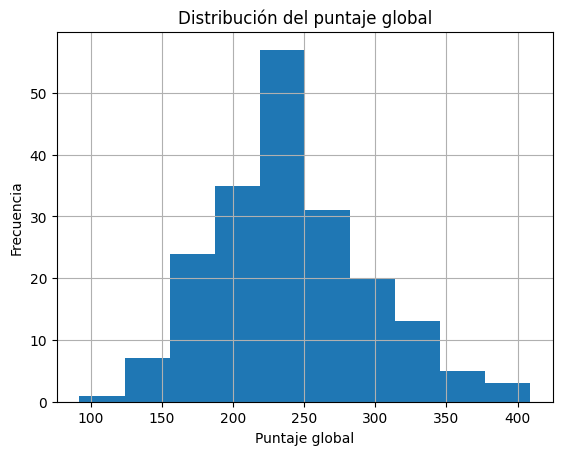

In [ ]:
#Analiza la distribución del puntaje global
df["Puntaje global"].hist()
plt.xlabel("Puntaje global")
plt.ylabel("Frecuencia")
plt.title("Distribución del puntaje global")
plt.show()

## Análisis del rendimiento por prueba:

In [ ]:
#Calcula el puntaje promedio para cada prueba

puntajes_promedio_prueba = df[["Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"]].mean()
print("Puntajes promedio por prueba:")
print(puntajes_promedio_prueba)

Puntajes promedio por prueba:
Matemáticas              38.000001
Lectura crítica          61.324042
Ciencias naturales       45.698452
Sociales y ciudadanas    48.091838
Inglés                   45.473099
dtype: float64


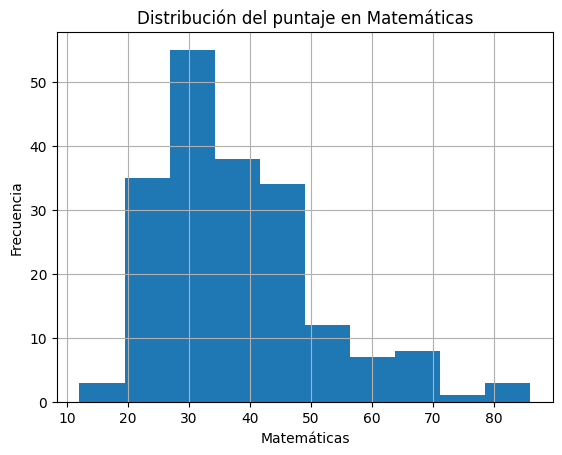

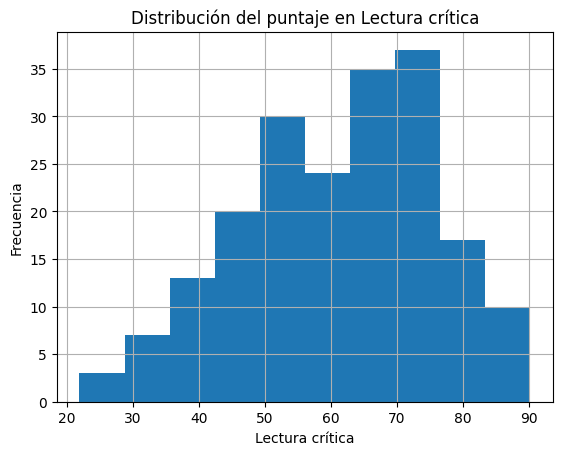

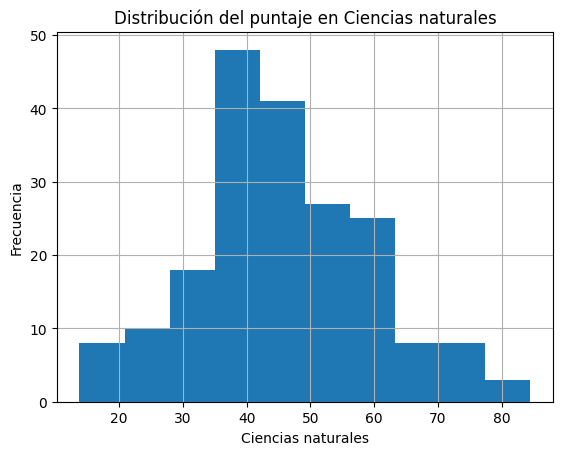

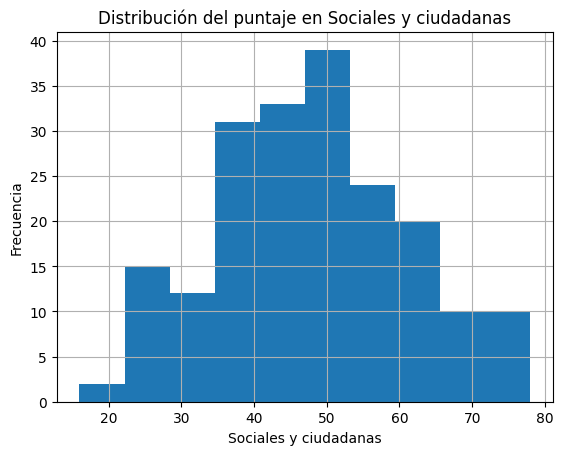

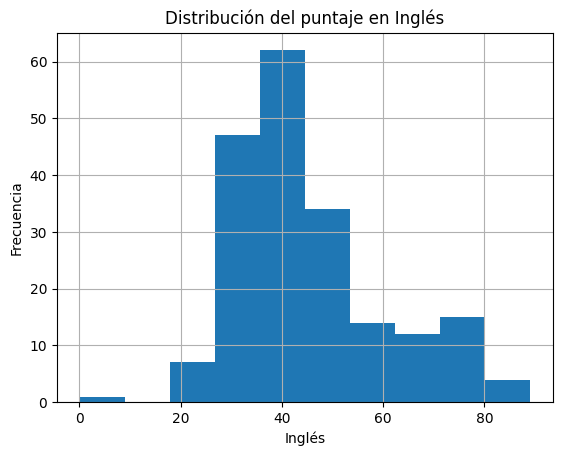

In [ ]:
#Analiza la distribución de los puntajes en cada prueba

for columna in df[["Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"]]:
    df[columna].hist()
    plt.xlabel(columna)
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución del puntaje en {columna}")
    plt.show()

## Comparación del rendimiento por grupo:

In [ ]:
#Agrupa el DataFrame por el grupo que te interesa

df_agrupado = df.groupby("Grupo")
df_agrupado

In [ ]:
# Calcula las medidas de resumen para cada grupo

medidas_resumen_grupo = df_agrupado[["Puntaje global", "Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"]].mean()
print("Medidas de resumen por grupo:")
print(medidas_resumen_grupo)

Medidas de resumen por grupo:
        Puntaje global  Matemáticas  Lectura crítica  Ciencias naturales  \
Grupo                                                                      
110100      236.400000    38.800001        60.682927           44.896552   
110200      255.125000    42.050001        63.780488           48.577587   
110300      265.435897    37.794873        68.480301           49.160036   
110400      245.522727    40.545456        63.303770           45.062697   
110500      212.130435    32.434784        54.082715           44.227887   
110600      202.120000    31.680001        50.048781           38.965518   

        Sociales y ciudadanas     Inglés  
Grupo                                     
110100              46.240001  41.600001  
110200              49.700001  49.681819  
110300              55.641027  55.477856  
110400              49.909092  40.454546  
110500              38.521740  42.608696  
110600              41.200001  38.472728  


* Compara los grupos utilizando pruebas estadísticas:

  * Si quieres comparar el puntaje global entre grupos, puedes usar la prueba t de Student o ANOVA.
  * Si quieres comparar el puntaje en pruebas específicas entre grupos, puedes usar la prueba t de Student pareada o ANOVA de medidas repetidas.

In [ ]:
from scipy.stats import ttest_ind

grupo1 = df[df["Grupo"] == 110100]["Puntaje global"]
grupo2 = df[df["Grupo"] == 110200]["Puntaje global"]

t, p = ttest_ind(grupo1, grupo2)

if p < 0.05:
    print(f"Existe una diferencia estadísticamente significativa en el puntaje global entre el Grupo 1 y el Grupo 2 (p = {p:.3f})")
else:
    print(f"No existe una diferencia estadísticamente significativa en el puntaje global entre el Grupo 1 y el Grupo 2 (p = {p:.3f})")


No existe una diferencia estadísticamente significativa en el puntaje global entre el Grupo 1 y el Grupo 2 (p = 0.205)


* Prueba t de Student independiente:

Esta prueba se utiliza cuando se tienen dos grupos de estudiantes que han sido evaluados en la misma prueba pero en un solo momento (por ejemplo, en un simulacro de prueba). Se compara el puntaje promedio de la prueba entre los dos grupos.

In [ ]:
#Realizar la prueba t de Student independiente

grupo1_lectura = df[df["Grupo"] == 110100]["Lectura crítica"]
grupo2_lectura = df[df["Grupo"] == 110200]["Lectura crítica"]


from scipy.stats import ttest_ind

t, p = ttest_ind(grupo1_lectura, grupo2_lectura)

if p < 0.05:
    print(f"Existe una diferencia estadísticamente significativa en el puntaje en Lectura crítica entre el Grupo 1 y el Grupo 2 (p = {p:.3f})")
else:
    print(f"No existe una diferencia estadísticamente significativa en el puntaje en Lectura crítica entre el Grupo 1 y el Grupo 2 (p = {p:.3f})")


# Tablero

In [10]:
# DATA

#datos = pd.read_excel('/content/drive/MyDrive/Python/Streamlit/Resultados_Simulacro_ICFES.xlsx'
              #,sheet_name= 'ALL'
#              )

#EN VS

datos = pd.read_excel('D:/Repositorios/rs_icfes-1/Resultados_Simulacro_ICFES.xlsx'
              #,sheet_name= 'ALL'
              )

datos.dropna(inplace=True)

datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1202 entries, 0 to 1206
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Grupo                  1202 non-null   int64  
 1   DOCUMENTO              1202 non-null   object 
 2   Nombre alumno          1202 non-null   object 
 3   Puntaje global         1202 non-null   float64
 4   Matemáticas            1202 non-null   float64
 5   Lectura crítica        1202 non-null   float64
 6   Ciencias naturales     1202 non-null   float64
 7   Sociales y ciudadanas  1202 non-null   float64
 8   Inglés                 1202 non-null   float64
 9   AÑO                    1202 non-null   int64  
 10  SIMULACRO              1202 non-null   object 
dtypes: float64(6), int64(2), object(3)
memory usage: 112.7+ KB


In [11]:
# pasae columna Grupo a string

datos["Grupo"] = datos["Grupo"].astype(str)
datos["AÑO"] = datos["AÑO"].astype(str)

In [6]:
datos.head()

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO
0,1101,1011395403,BAENA CHALARCA JERONIMO,162.0,38.000001,26.829269,18.965518,44.000001,36.363637,2024,S1
1,1101,1028900047,BERNAL BENITEZ ANGIE SOFIA,262.0,46.000001,58.536586,60.344828,50.000001,34.545455,2024,S1
2,1101,1082877619,CARVAJAL QUINTERO LAURA VANESSA,230.0,48.000001,58.536586,34.482759,46.000001,36.363637,2024,S1
3,1101,1151479897,CASTILLO TAPIA EYLEEN,180.0,44.000001,36.585366,34.482759,28.000001,36.363637,2024,S1
4,1101,1035975126,FLOREZ OSSA BALERI,188.0,28.000001,43.902440,37.931035,42.000001,32.727273,2024,S1


In [12]:
# prompt: Redondear las columnas de tipo float a do decimales

for col in datos.select_dtypes(include=np.float64):
    datos[col] = datos[col].round(2)
datos.head()

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO
0,1101,1011395403,BAENA CHALARCA JERONIMO,162.0,38.0,26.83,18.97,44.0,36.36,2024,S1
1,1101,1028900047,BERNAL BENITEZ ANGIE SOFIA,262.0,46.0,58.54,60.34,50.0,34.55,2024,S1
2,1101,1082877619,CARVAJAL QUINTERO LAURA VANESSA,230.0,48.0,58.54,34.48,46.0,36.36,2024,S1
3,1101,1151479897,CASTILLO TAPIA EYLEEN,180.0,44.0,36.59,34.48,28.0,36.36,2024,S1
4,1101,1035975126,FLOREZ OSSA BALERI,188.0,28.0,43.90,37.93,42.0,32.73,2024,S1


In [13]:
#convertir la columna "Matemáticas" a int

datos["Matemáticas"] = datos["Matemáticas"].astype(int)
datos["Sociales y ciudadanas"] = datos["Sociales y ciudadanas"].astype(int)

## COMPARATIVO POR AÑO

In [16]:
# Filtrar los estudiantes de grado once en 2025
once_2025 = datos[((datos['AÑO'] == '2025') & (datos['Grupo'].str.startswith('110'))) | ((datos['AÑO'] == '2024') & (datos['Grupo'].str.startswith('100')))]
once_2025

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO
580,1001,1122515257,VARGAS GONZALEZ KEREN,324.0,44,58.54,70.69,80,81.82,2024,S2
581,1001,1022003872,VERGARA RENDON MARIA JOSE,306.0,56,60.98,46.55,74,81.82,2024,S2
582,1001,1040572855,SEQUEA USUGA ANA SOFIA,294.0,48,63.41,44.83,70,85.45,2024,S2
583,1001,1435789,RODRIGUEZ HERNANDEZ REINALDO ENRIQUE,283.0,58,68.29,53.45,52,38.18,2024,S2
584,1001,1034989817,VILLEGAS CHAVEZ JOSE MANUEL,281.0,46,56.10,41.38,72,81.82,2024,S2
...,...,...,...,...,...,...,...,...,...,...,...
1202,1104,1017933137,SMITH GUTIERREZ ISABELLA,218.0,34,58.54,36.21,44,47.27,2025,S1
1203,1104,1044919573,SOTO LONDOÑO EZEQUIEL,182.0,28,41.46,34.48,30,70.91,2025,S1
1204,1104,1040574054,SUAREZ ECHEVERRI JUAN PABLO,260.0,46,58.54,48.28,54,54.55,2025,S1
1205,1104,1035977282,SUAREZ VANEGAS SARA,176.0,34,48.78,24.14,34,34.55,2025,S1


In [ ]:
import plotly.express as px

# Derretir el DataFrame para que sea más fácil de graficar
promedios_derretidos = promedios_por_areas.reset_index().melt(id_vars="AÑO", var_name="Área", value_name="Promedio")

# Crear el gráfico de barras agrupado por área
fig = px.bar(promedios_derretidos, x="Área", y="Promedio", color="AÑO", barmode="group", text_auto=True)

# Actualizar el diseño para etiquetas y título
fig.update_layout(
    xaxis_title="Áreas",
    yaxis_title="Promedios",
    title="Promedios por Área Agrupados por Año"
)

# Mostrar el gráfico
fig.show()

In [ ]:
datos[datos]

In [14]:
# Agrupar datos por grupo y calcular promedios de puntajes globales
datos_agrupados = datos.groupby(['Nombre alumno','SIMULACRO'])['Puntaje global'].mean().round(2).reset_index()
datos_agrupados

,Nombre alumno,SIMULACRO,Puntaje global
0,ACEVEDO LOPEZ ISABELLA,ICFES,307.00
1,ACEVEDO LOPEZ ISABELLA,S1,264.00
2,ACEVEDO LOPEZ ISABELLA,S2,269.00
3,ACEVEDO LOPEZ ISABELLA,S3,272.00
4,ACEVEDO TOVAR LAURA ISABEL,S1,253.00
...,...,...,...
1197,ZAPATA MOLINA SARA ISABEL,S2,262.00
1198,ZAPATA MOLINA SARA ISABEL,S3,223.00
1199,ZAPATA RIOS ANA ISABEL,S1,126.10
1200,ZAPATA ROLDAN LUCIANA,S1,199.55


In [ ]:
#pip install plotly
#!pip install altair

!pip install nbformat --upgrade

In [ ]:
#import streamlit as st
import pandas as pd
import numpy as np
import altair as alt
import plotly.express as px

In [ ]:
datos_agrupados[datos_agrupados["Nombre alumno"] == "ACEVEDO LOPEZ ISABELLA"]

,Nombre alumno,SIMULACRO,Puntaje global
0,ACEVEDO LOPEZ ISABELLA,S1,264.0
1,ACEVEDO LOPEZ ISABELLA,S2,269.0
2,ACEVEDO LOPEZ ISABELLA,S3,272.0


In [ ]:
# Crear gráfico de barras

fig = px.bar(datos_agrupados[datos_agrupados["Nombre alumno"] == "ACEVEDO LOPEZ ISABELLA"], x="Nombre alumno", y="Puntaje global", color = 'SIMULACRO', barmode='group', text_auto=True)

# Actualizar el diseño para etiquetas y título
fig.update_layout(
      xaxis_title="Grupo",
      yaxis_title="Puntaje global",
      title="Distribución de puntajes globales por grupo",
  )

# Mostrar el gráfico
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
import plotly.express as px
import pandas as pd

# Datos de ejemplo
datos = {
    'Nombre alumno': ['ACEVEDO LOPEZ ISABELLA', 'ACEVEDO LOPEZ ISABELLA', 'OTRO ALUMNO'],
    'Puntaje global': [85, 90, 75],
    'SIMULACRO': ['Simulacro 1', 'Simulacro 2', 'Simulacro 1']
}
datos_agrupados = pd.DataFrame(datos)

# Crear la figura
fig = px.bar(datos_agrupados[datos_agrupados["Nombre alumno"] == "ACEVEDO LOPEZ ISABELLA"],
             x="Nombre alumno",
             y="Puntaje global",
             color='SIMULACRO',
             barmode='group',
             text_auto=True)

# Actualizar el diseño para etiquetas y título
fig.update_layout(
    xaxis_title="Nombre del Alumno",
    yaxis_title="Puntaje Global",
    title="Distribución de Puntajes Globales por Alumno"
)

# Mostrar la figura
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
def obtener_datos_por_area_simulacro(area,simulacro):
  """
  Obtiene los datos de un área específica.

  Argumentos:
    area (str): El nombre del área (Matemáticas, Lectura crítica, etc.).

  Retorno:
    DataFrame: Subconjunto de datos con la información del área seleccionada.
  """

  datos_area_simulacro = datos[["Grupo","Nombre alumno", "SIMULACRO",f"{area}"]]
  datos_area_simulacro = datos_area_simulacro[datos_area_simulacro["SIMULACRO"] == simulacro]
  return datos_area_simulacro

In [ ]:
obtener_datos_por_area_simulacro('Matemáticas','SIMULACRO')[]

SyntaxError: invalid syntax (2251901974.py, line 1)

<Axes: xlabel='count', ylabel='Grupo'>

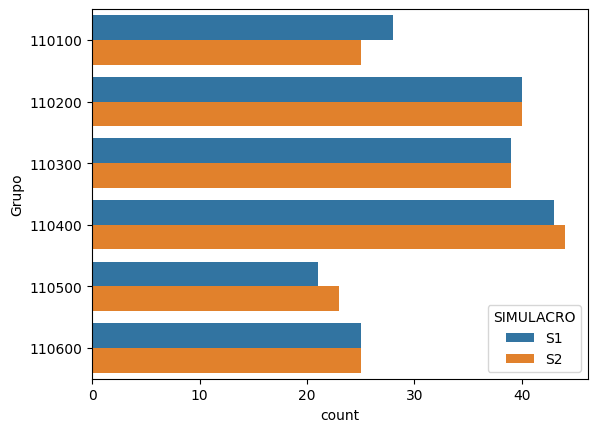

In [ ]:
sns.countplot(datos, y="Grupo", hue="SIMULACRO",orient="h")

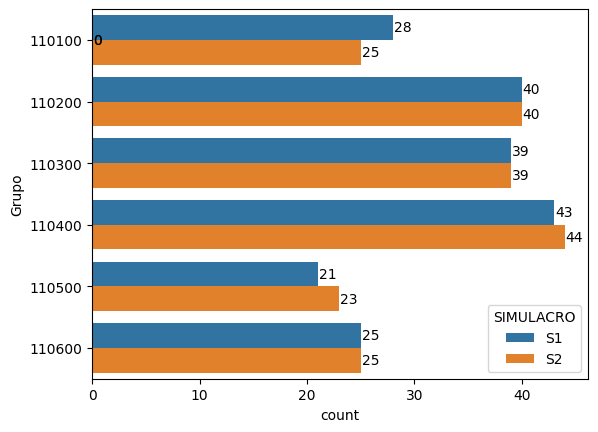

In [ ]:
# Crear el gráfico de barras
ax = sns.countplot(datos, y="Grupo", hue="SIMULACRO", orient="h")

# Agregar etiquetas de texto a las barras
for p in ax.patches:
    width = p.get_width()   # Obtener el ancho de la barra (el valor)
    plt.text(width + 0.1,   # Posición horizontal del texto (ajusta según sea necesario)
             p.get_y() + p.get_height() / 2,   # Posición vertical del texto
             int(width),   # El texto que quieres colocar (el valor de la barra)
             ha='left', va='center')   # Alineación del texto

# Mostrar el gráfico
plt.show()

In [ ]:
datos[(datos["Grupo"] == "110100") & (datos["SIMULACRO"] == "S3")]

,Grupo,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO
392,110100,BAENA CHALARCA JERONIMO,225,36,52.5,32.76,62,34.55,2024,S3
393,110100,BERNAL BENITEZ ANGIE SOFIA,302,46,75.0,55.17,72,38.18,2024,S3
394,110100,CARVAJAL QUINTERO LAURA VANESSA,259,40,67.5,37.93,66,38.18,2024,S3
395,110100,CASTILLO TAPIA EYLEEN,188,30,45.0,25.86,48,41.82,2024,S3
396,110100,FLOREZ OSSA BALERI,281,60,65.0,36.21,64,54.55,2024,S3
397,110100,GARCIA GOMEZ JOHN ALEX,201,32,42.5,32.76,54,38.18,2024,S3
398,110100,GIRALDO CABRERA CAMILA VICTORIA,178,38,45.0,20.69,34,49.09,2024,S3
399,110100,JIMENEZ VELEZ KARINA,185,26,37.5,36.21,42,54.55,2024,S3
400,110100,LONDOÑO MORENO KATHERIN,245,36,57.5,46.55,60,34.55,2024,S3
401,110100,MARIN VILLEGAS NICOLE SOFIA,213,38,52.5,48.28,30,45.45,2024,S3


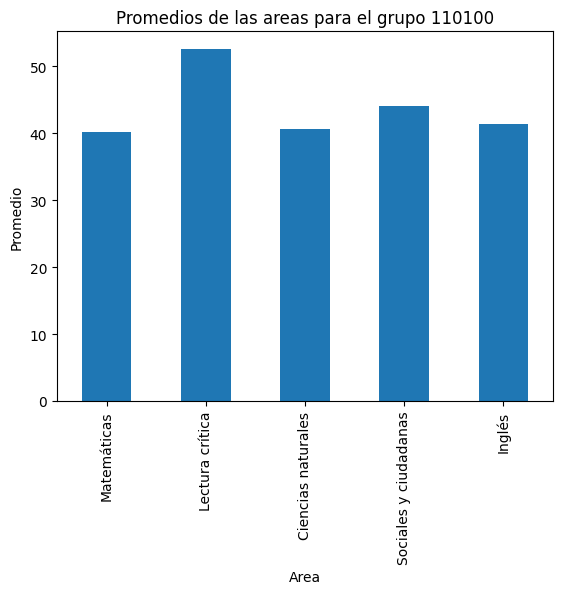

In [ ]:
# prompt: Grafico de barras para las promedios de las areas para el grupo 110100

import matplotlib.pyplot as plt
# Grafico de barras para las promedios de las areas para el grupo 110100

grupo110100 = datos[datos["Grupo"] == "110100"]

# Calcular los promedios de las areas para el grupo 110100

promedios_grupo110100 = grupo110100[["Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"]].mean()

# Crear el grafico de barras

promedios_grupo110100.plot(kind="bar")

# Añadir titulo y etiquetas a los ejes

plt.title("Promedios de las areas para el grupo 110100")
plt.xlabel("Area")
plt.ylabel("Promedio")

# Mostrar el grafico

plt.show()


In [ ]:
datos.groupby(['Grupo','SIMULACRO'])[["Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"]].mean().reset_index()

,Grupo,SIMULACRO,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés
0,110100,S1,41.428571,45.383571,36.883214,42.214286,41.103929
1,110100,S2,38.800000,60.682800,44.896000,46.240000,41.600000
2,110200,S1,46.650000,49.939250,38.663500,42.300000,45.455000
3,110200,S2,42.050000,63.780750,48.577500,49.700000,49.681500
4,110300,S1,42.820513,52.032564,46.109231,46.564103,51.095128
5,110300,S2,37.794872,68.479744,49.160000,55.641026,55.478462
6,110400,S1,46.418605,51.899767,39.173256,44.186047,43.002093
7,110400,S2,40.545455,63.303864,45.063182,49.909091,40.454091
8,110500,S1,40.571429,43.088571,34.893333,36.476190,35.237619
9,110500,S2,32.434783,54.082174,44.227826,38.521739,42.609130


In [ ]:
datos_agrupados = datos.groupby('Grupo')[["Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"]].mean().reset_index()
datos_agrupados[datos_agrupados.Grupo=='110100']

,Grupo,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés
0,110100,40.734177,53.991266,39.589494,45.670886,43.268354


In [ ]:
# prompt: derretir datos_agrupados por columnas de areas

datos_derretidos = datos_agrupados.melt(id_vars="Grupo", var_name="Área", value_name="Promedio")
datos_derretidos


,Grupo,Área,Promedio
0,110100,Matemáticas,38.800000
1,110200,Matemáticas,42.050000
2,110300,Matemáticas,37.794872
3,110400,Matemáticas,40.545455
4,110500,Matemáticas,32.434783
5,110600,Matemáticas,31.680000
6,110100,Lectura crítica,60.682800
7,110200,Lectura crítica,63.780750
8,110300,Lectura crítica,68.479744
9,110400,Lectura crítica,63.303864


In [ ]:
datos_agrupados = datos.groupby('Grupo')[["Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"]].mean().reset_index()

# derretir datos_agrupados por columnas de areas
datos_derretidos = datos_agrupados.melt(id_vars="Grupo", var_name="Área", value_name="Promedio")

# Seleccionamos grupo
datos_grupo_seleccionado = datos_derretidos[datos_derretidos.Grupo==grupo_seleccionado]

# Crear gráfico de barras
fig = px.bar(datos_grupo_seleccionado, x="Área", y="Promedio", text_auto=True)

# Actualizar el diseño para etiquetas y título
fig.update_layout(
    xaxis_title="Áreas",
    yaxis_title="Promedios",
    title="Distribución de puntajes por área y por grupo",
)

# Mostrar el gráfico
fig.show()


In [ ]:
D_M = datos_derretidos[datos_derretidos.Grupo=='110100']
D_M

,Grupo,Área,Promedio
0,110100,Matemáticas,38.8000
6,110100,Lectura crítica,60.6828
12,110100,Ciencias naturales,44.8960
18,110100,Sociales y ciudadanas,46.2400
24,110100,Inglés,41.6000


In [ ]:
import plotly.express as px

In [ ]:
#Agrupar datos por grupo y calcular promedios de puntajes globales
#datos_agrupados = datos.groupby('Grupo')["Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"].mean().reset_index()

# Crear gráfico de barras
fig = px.bar(D_M, x="Área", y="Promedio", text_auto=True)

# Actualizar el diseño para etiquetas y título
fig.update_layout(
    xaxis_title="Grupo",
    yaxis_title="Puntaje global",
    title="Distribución de puntajes globales por grupo",
)

# Mostrar el gráfico
fig.show()

## Análisis por areas

In [ ]:
def calcular_metricas_por_area(datos_area,area):
  """
  Calcula las métricas para un área específica.

  Argumentos:
    datos_area (DataFrame): Subconjunto de datos con la información del área seleccionada.

  Retorno:
    Diccionario: Diccionario con las métricas calculadas (promedio, mediana, desviación estándar, percentiles).
  """
  promedio_area = datos_area[f"{area}"].mean()
  mediana_area = datos_area[f"{area}"].median()
  desviacion_estandar_area = datos_area[f"{area}"].std()
  percentiles_area = datos_area[f"{area}"].quantile([0.25, 0.5, 0.75])
  maximo_area = round(max(datos_area[f"{area}"]),3)
  minimo_area = min(datos_area[f"{area}"])

  metricas_area = {
    "Promedio": promedio_area,
    "Mediana": mediana_area,
    "Desviación estándar": desviacion_estandar_area,
    "Percentiles": percentiles_area.to_dict(),
    "maximo_area": maximo_area,
    "minimo_area": minimo_area
  }

  return metricas_area

In [ ]:
calcular_metricas_por_area(datos,"Matemáticas")

{'Promedio': 38.0,
 'Mediana': 36.0,
 'Desviación estándar': 13.34973350353424,
 'Percentiles': {0.25: 28.0, 0.5: 36.0, 0.75: 44.0},
 'maximo_area': 86.0,
 'minimo_area': 12.0}

In [ ]:
calcular_metricas_por_area(datos,"Puntaje global")['maximo_area']

409

## Análisis por grupos

In [ ]:
# prompt: Crear un dataframe con la columna de "METRICAS" con valores de media, mediana, desviación, cuatil 1, cuartil 2, cuartil 3 y los valores en los respectivas areas

metricas = ['Media', 'Mediana', 'Desviación', 'Cuartil 1', 'Cuartil 2', 'Cuartil 3']
materias = ['Matemáticas', 'Lectura crítica', 'Ciencias naturales', 'Sociales y ciudadanas', 'Inglés']

df_metricas = pd.DataFrame(columns=['METRICAS'] + materias)
df_metricas['METRICAS'] = ['Media', 'Mediana', 'Desviación', '25%', '50%', '75%']

#for metrica in metricas:
for materia in materias:
  df_metricas[materia] = [datos[materia].mean(), datos[materia].median(), datos[materia].std(), datos[materia].quantile(0.25), datos[materia].quantile(0.5), datos[materia].quantile(0.75)]
  df_metricas[materia] = df_metricas[materia].round(2)
df_metricas


,METRICAS,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés
0,Media,38.00,61.32,45.70,48.09,45.47
1,Mediana,36.00,63.41,44.83,48.00,41.82
2,Desviación,13.35,14.66,13.28,12.70,15.70
3,25%,28.00,51.22,37.93,39.50,34.55
4,50%,36.00,63.41,44.83,48.00,41.82
5,75%,44.00,73.17,53.45,56.50,51.36


In [ ]:
# prompt: Crear un data frame con el promedio en cada area para cada grupo

import pandas as pd
df_metricas_grupo = pd.DataFrame(columns=['Grupo'] + materias)



df_metricas_grupo


,Grupo,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés


In [ ]:
for grupo in datos['Grupo'].unique():
    df_grupo = datos[datos['Grupo'] == grupo]
    metricas_grupo = {}
    for materia in materias:
        metricas_grupo[materia] = df_grupo[materia].mean().round(2)
    metricas_grupo['Grupo'] = grupo
    #df_metricas_grupo = df_metricas_grupo.append(metricas_grupo, ignore_index=True)

In [ ]:
metricas_grupo

{'Matemáticas': 31.68,
 'Lectura crítica': 50.05,
 'Ciencias naturales': 38.97,
 'Sociales y ciudadanas': 41.2,
 'Inglés': 38.47,
 'Grupo': '110600'}

In [ ]:
datos.Grupo.value_counts()

Grupo
110400    44
110200    40
110300    39
110100    25
110600    25
110500    23
Name: count, dtype: int64

In [ ]:
# Definir funciones para procesar datos por grupo

def obtener_datos_por_grupo(grupo):
  """
  Obtiene los datos de un grupo específico (Género, Grado, etc.).

  Argumentos:
    grupo (str): El nombre del grupo (Masculino, Femenino, 11°, 12°, etc.).

  Retorno:
    DataFrame: Subconjunto de datos con la información del grupo seleccionado.
  """
  datos_grupo = datos[datos["Grupo"] == grupo]
  return datos_grupo

def calcular_metricas_por_grupo(datos_grupo,columna):
  """
  Calcula las métricas para un grupo específico.

  Argumentos:
    datos_grupo (DataFrame): Subconjunto de datos con la información del grupo seleccionado.

  Retorno:
    Diccionario: Diccionario con las métricas calculadas (promedio, mediana, desviación estándar, percentiles).
  """
  promedio_grupo = datos_grupo[columna].mean()
  mediana_grupo = datos_grupo[columna].median()
  desviacion_estandar_grupo = datos_grupo[columna].std()
  percentiles_grupo = datos_grupo[columna].quantile([0.25, 0.5, 0.75])

  metricas_grupo = {
    "Promedio": promedio_grupo,
    "Mediana": mediana_grupo,
    "Desviación estándar": desviacion_estandar_grupo,
    "Percentiles": percentiles_grupo.to_dict()
  }

  return metricas_grupo

def generar_tabla_metricas(metricas_grupo):
  """
  Genera una tabla HTML con las métricas de un grupo.

  Argumentos:
    metricas_grupo (Diccionario): Diccionario con las métricas calculadas.

  Retorno:
    str: Cadena HTML con la tabla de métricas.
  """
  tabla_html = """
  <table style="border: 1px solid #ddd; border-spacing: 0; width: auto;">
    <tr>
      <th style="padding: 8px; border: 1px solid #ddd;">Métrica</th>
      <th style="padding: 8px; border: 1px solid #ddd;">Valor</th>
    </tr>
    <tr>
      <td style="padding: 8px; border: 1px solid #ddd;">Promedio</td>
      <td style="padding: 8px; border: 1px solid #ddd;">{promedio:.2f}</td>
    </tr>
    <tr>
      <td style="padding: 8px; border: 1px solid #ddd;">Mediana</td>
      <td style="padding: 8px; border: 1px solid #ddd;">{mediana:.2f}</td>
    </tr>
    <tr>
      <td style="padding: 8px; border: 1px solid #ddd;">Desviación estándar</td>
      <td style="padding: 8px; border: 1px solid #ddd;">{desviacion_estandar:.2f}</td>
    </tr>
    <tr>
      <td style="padding: 8px; border: 1px solid #ddd;">Percentiles</td>
      <td style="padding: 8px; border: 1px solid #ddd;">
        <ul style="list-style: none; margin: 0; padding: 0;">
          <li>25%: {percentil_25:.2f}</li>
          <li>50%: {percentil_50:.2f}</li>
          <li>75%: {percentil_75:.2f}</li>
        </ul>
      </td>
    </tr>
  </table>
  """.format(
    promedio=metricas_grupo["Promedio"],
    mediana=metricas_grupo["Mediana"],
    desviacion_estandar=metricas_grupo["Desviación estándar"],
    percentil_25=metricas_grupo["Percentiles"][0.25],
    percentil_50=metricas_grupo["Percentiles"][0.5],
    percentil_75=metricas_grupo["Percentiles"][0.75]
  )
  return tabla_html

In [ ]:
obtener_datos_por_grupo('110100')

,Grupo,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés
0,110100,BAENA CHALARCA JERONIMO,225,34.0,70.73,39.66,36.0,41.82
1,110100,BERNAL BENITEZ ANGIE SOFIA,313,46.0,75.61,70.69,66.0,38.18
2,110100,CARVAJAL QUINTERO LAURA VANESSA,247,40.0,80.49,34.48,46.0,38.18
3,110100,CASTILLO TAPIA EYLEEN,171,28.0,53.66,29.31,26.0,32.73
4,110100,FLOREZ OSSA BALERI,259,50.0,70.73,44.83,46.0,36.36
5,110100,GARCIA GOMEZ JOHN ALEX,198,30.0,48.78,39.66,42.0,32.73
6,110100,GIRALDO CABRERA CAMILA VICTORIA,203,24.0,65.85,34.48,40.0,34.55
7,110100,LONDOÑO MORENO KATHERIN,234,22.0,63.41,51.72,52.0,40.00
8,110100,MARIN VILLEGAS NICOLE SOFIA,229,38.0,58.54,51.72,38.0,36.36
9,110100,MERINO SANCHEZ KAREN,355,60.0,78.05,68.97,74.0,78.18


In [ ]:
calcular_metricas_por_grupo(obtener_datos_por_grupo('110100'),'Puntaje global')

{'Promedio': 236.4,
 'Mediana': 229.0,
 'Desviación estándar': 49.418282716689646,
 'Percentiles': {0.25: 201.0, 0.5: 229.0, 0.75: 259.0}}

In [ ]:
datos.columns.to_list()

['Grupo',
 'Nombre alumno',
 'Puntaje global',
 'Matemáticas',
 'Lectura crítica',
 'Ciencias naturales',
 'Sociales y ciudadanas',
 'Inglés']

In [ ]:
for col in datos.select_dtypes(include=np.float64):
    print(calcular_metricas_por_grupo(obtener_datos_por_grupo('110100'),f'{col}'))

{'Promedio': 38.8, 'Mediana': 38.0, 'Desviación estándar': 13.638181696985855, 'Percentiles': {0.25: 28.0, 0.5: 38.0, 0.75: 46.0}}
{'Promedio': 60.6828, 'Mediana': 58.54, 'Desviación estándar': 13.197070861874362, 'Percentiles': {0.25: 51.22, 0.5: 58.54, 0.75: 70.73}}
{'Promedio': 44.895999999999994, 'Mediana': 44.83, 'Desviación estándar': 14.09044061293566, 'Percentiles': {0.25: 34.48, 0.5: 44.83, 0.75: 51.72}}
{'Promedio': 46.24, 'Mediana': 44.0, 'Desviación estándar': 13.642091726222437, 'Percentiles': {0.25: 36.0, 0.5: 44.0, 0.75: 54.0}}
{'Promedio': 41.6, 'Mediana': 38.18, 'Desviación estándar': 11.46665455425717, 'Percentiles': {0.25: 34.55, 0.5: 38.18, 0.75: 41.82}}


In [ ]:
generar_tabla_metricas(calcular_metricas_por_grupo(obtener_datos_por_grupo('110100'),'Puntaje global'))

'\n  <table style="border: 1px solid #ddd; border-spacing: 0; width: auto;">\n    <tr>\n      <th style="padding: 8px; border: 1px solid #ddd;">Métrica</th>\n      <th style="padding: 8px; border: 1px solid #ddd;">Valor</th>\n    </tr>\n    <tr>\n      <td style="padding: 8px; border: 1px solid #ddd;">Promedio</td>\n      <td style="padding: 8px; border: 1px solid #ddd;">236.40</td>\n    </tr>\n    <tr>\n      <td style="padding: 8px; border: 1px solid #ddd;">Mediana</td>\n      <td style="padding: 8px; border: 1px solid #ddd;">229.00</td>\n    </tr>\n    <tr>\n      <td style="padding: 8px; border: 1px solid #ddd;">Desviación estándar</td>\n      <td style="padding: 8px; border: 1px solid #ddd;">49.42</td>\n    </tr>\n    <tr>\n      <td style="padding: 8px; border: 1px solid #ddd;">Percentiles</td>\n      <td style="padding: 8px; border: 1px solid #ddd;">\n        <ul style="list-style: none; margin: 0; padding: 0;">\n          <li>25%: 201.00</li>\n          <li>50%: 229.00</li>\n  

# Prepint DshBoard

In [1]:
import altair as alt
import plotly.express as px
from statistics import mode,median,mean

In [4]:
df = pd.read_excel('/content/Resultados_Simulacro_ICFES_Sinteticos.xlsx'
                   #,sheet_name='TODOS'
                   ,engine='openpyxl'
                   )
df["AÑO"] = df["AÑO"].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2120 entries, 0 to 2119
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Grupo                  2120 non-null   int64  
 1   DOCUMENTO              2120 non-null   object 
 2   Nombre alumno          2120 non-null   object 
 3   Puntaje global         2120 non-null   int64  
 4   Matemáticas            2120 non-null   float64
 5   Lectura crítica        2120 non-null   float64
 6   Ciencias naturales     2120 non-null   float64
 7   Sociales y ciudadanas  2120 non-null   float64
 8   Inglés                 2120 non-null   float64
 9   AÑO                    2120 non-null   object 
 10  SIMULACRO              2120 non-null   object 
dtypes: float64(5), int64(2), object(4)
memory usage: 182.3+ KB


In [5]:
df.head()

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO
0,1101,1011395403,BAENA CHALARCA JERONIMO,162,38.000001,26.829269,18.965518,44.000001,36.363637,2024,S1
1,1101,1028900047,BERNAL BENITEZ ANGIE SOFIA,262,46.000001,58.536586,60.344828,50.000001,34.545455,2024,S1
2,1101,1082877619,CARVAJAL QUINTERO LAURA VANESSA,230,48.000001,58.536586,34.482759,46.000001,36.363637,2024,S1
3,1101,1151479897,CASTILLO TAPIA EYLEEN,180,44.000001,36.585366,34.482759,28.000001,36.363637,2024,S1
4,1101,1035975126,FLOREZ OSSA BALERI,188,28.000001,43.902440,37.931035,42.000001,32.727273,2024,S1


In [6]:
datos_año = df.groupby(['AÑO','SIMULACRO'])[["Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"]].mean().round(2).reset_index()
datos_año

,AÑO,SIMULACRO,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés
0,2023,ICFES,53.00,57.00,51.00,52.00,55.00
1,2023,S1,54.72,56.55,51.16,53.03,53.56
2,2023,S2,54.62,57.64,50.12,51.05,53.66
3,2023,S3,54.90,57.85,50.12,52.57,53.72
4,2024,ICFES,52.89,56.26,49.39,50.58,52.62
5,2024,S1,43.50,48.56,39.71,41.97,43.25
6,2024,S2,39.02,54.49,44.51,45.97,45.16
7,2024,S3,40.47,57.25,40.74,52.70,46.35
8,2025,ICFES,53.36,59.67,50.69,52.39,53.86
9,2025,S1,54.98,58.15,49.08,52.03,53.53


In [ ]:
# @title Crear gráfico de barras comparativo por año agrupado por prueba
fig = px.bar(datos_año, x="AÑO", y="Matemáticas", color = 'SIMULACRO', barmode='group', text_auto=True)

  # Actualizar el diseño para etiquetas y título
  #fig.update_layout(
  #    xaxis_title="Áreas",
  #    yaxis_title="Promedios",
  #    title="Distribución de puntajes por área para cdad grupo grupo",
  #)

  # Mostrar el gráfico
fig.show()
#plotly_chart(fig)

In [ ]:
# @title Crear gráfico de barras comparativo por prueba agrupado por año
fig = px.bar(datos_año, x="SIMULACRO", y="Matemáticas", color = 'AÑO', barmode='group', text_auto=True)

# Actualizar el diseño para etiquetas y título
fig.update_layout(
    xaxis_title="Pruebas",
    yaxis_title="Promedios",
    title="Distribución de puntajes por año para cadad prueba",
  )

# Mostrar el gráfico
fig.show()

In [ ]:
# @title Derretir

datos_agrupados_simulacro = df.groupby(['AÑO','SIMULACRO'])[["Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"]].mean().round(2).reset_index()

# derretir datos_agrupados por columnas de areas

datos = datos_agrupados_simulacro.melt(id_vars=['AÑO','SIMULACRO'], var_name="Área", value_name="Promedio")

datos = datos[datos['SIMULACRO']=='ICFES']
datos

,AÑO,SIMULACRO,Área,Promedio
0,2023,ICFES,Matemáticas,53.00
1,2024,ICFES,Matemáticas,52.89
6,2023,ICFES,Lectura crítica,57.00
7,2024,ICFES,Lectura crítica,56.26
12,2023,ICFES,Ciencias naturales,51.00
13,2024,ICFES,Ciencias naturales,49.39
18,2023,ICFES,Sociales y ciudadanas,52.00
19,2024,ICFES,Sociales y ciudadanas,50.58
24,2023,ICFES,Inglés,55.00
25,2024,ICFES,Inglés,52.62


In [ ]:
fig = px.bar(datos
             , x="Área"
             , y="Promedio"
             , color = 'AÑO'
             , barmode='group'
             , text_auto=True
             )

# Actualizar el diseño para etiquetas y título
fig.update_layout(
    xaxis_title="Pruebas",
    yaxis_title="Promedios",
    title="Distribución de puntajes en el ICFES por año agrupados por area",
  )

# Mostrar el gráfico
fig.show()

In [ ]:
fig = px.bar(datos, x="Área", y="Promedio", color="medal", title="Long-Form Input")
fig.show()

In [ ]:
fig = px.bar(datos,
             x="Área",
             y="Promedio",
             color="AÑO", # Use only 'SIMULACRO' for color
             barmode='group',
             text_auto=True,
             facet_col="SIMULACRO"  # Use facet_col to group by 'AÑO'
            )

# Actualizar el diseño para etiquetas y título
fig.update_layout(
    xaxis_title="Pruebas",
    yaxis_title="Promedios",
    title="Distribución de puntajes por año para cada prueba",
)

# Mostrar el gráfico
fig.show()

In [7]:
datos = df.copy()

In [9]:
datos_agrupados_simulacro = datos.groupby(['SIMULACRO'])[["Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"]].mean().round(2).reset_index()
datos_agrupados_simulacro

,SIMULACRO,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés
0,ICFES,53.12,57.90,50.03,51.47,53.24
1,S1,50.70,54.13,46.31,48.67,49.78
2,S2,46.49,55.95,47.36,48.53,49.31
3,S3,49.89,57.57,46.95,52.48,50.88


In [11]:
# derretir datos_agrupados por columnas de areas
datos_derretidos_simulacro = datos_agrupados_simulacro.melt(id_vars=['SIMULACRO'], var_name="Área", value_name="Promedio")
datos_derretidos_simulacro

,SIMULACRO,Área,Promedio
0,ICFES,Matemáticas,53.12
1,S1,Matemáticas,50.70
2,S2,Matemáticas,46.49
3,S3,Matemáticas,49.89
4,ICFES,Lectura crítica,57.90
5,S1,Lectura crítica,54.13
6,S2,Lectura crítica,55.95
7,S3,Lectura crítica,57.57
8,ICFES,Ciencias naturales,50.03
9,S1,Ciencias naturales,46.31


In [12]:
datos_derretidos_simulacro.SIMULACRO.unique()

array(['ICFES', 'S1', 'S2', 'S3'], dtype=object)

# Preprocesamiento

In [3]:
def space(cadena):
    s = cadena.strip()
    #s = s.replace('  ', ' ')
    s = " ".join(cadena.split())
    s = s.upper()
    return s

def Estandarizacion_espacios(df,variable):
  df[variable] = df[variable].apply(lambda x: space(x))

def normalizar_nombre(nombre):
    # Quitar tildes, convertir a mayúsculas y eliminar espacios extras
    #nombre = unicodedata.normalize('NFKD', nombre).encode('ASCII', 'ignore').decode()
    return ' '.join(nombre.upper().split())

def invertir_nombre(nombre):
    partes = nombre.split()
    mitad = len(partes) // 2
    return ' '.join(partes[mitad:] + partes[:mitad])  # nombres + apellidos


In [5]:
excel_file = pd.ExcelFile('data/Listas_estudiantes_oreste.xlsx')
print(excel_file.sheet_names)

['803', '105', 'U_105', '115', '116', 'SEMILLERO', 'ALL', 'ONCE', '701', '702', '703', '704', 'All_6', 'All_7', 'Asistencia_801', 'Aseo', 'Puestos', 'Hoja1', 'All_8', 'All_10', 'ALL_COL_2025', 'ALL_COL_2026']


In [6]:
df_est = excel_file.parse('ALL_COL_2026')
df_est.head()

,GRADO,GRUPO,MATRICULA,TIPO_DOC,DOCUMENTO,ESTUDIANTE
0,01,010100,260170,R.C.,1095962630,ACOSTA BUITRAGO JOSEPH ENRIQUE
1,01,010100,250055,R.C.,1121557778,AHUMADA DIAZ JOHANDELIS ISABELLA
2,01,010100,250059,P.P.T.,7865611,AMARO ROJAS JHADDIEL ZAHID
3,01,010100,250414,R.C.,1035984992,ARIAS CURIEL MATHIAS ANDRES
4,01,010100,250035,R.C.,1035986114,AVENDAÑO OROZCO SUSANA


In [7]:
df_est.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2052 entries, 0 to 2051
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   GRADO       2052 non-null   object
 1   GRUPO       2052 non-null   object
 2   MATRICULA   2052 non-null   int64 
 3   TIPO_DOC    2052 non-null   object
 4   DOCUMENTO   2052 non-null   object
 5   ESTUDIANTE  2052 non-null   object
dtypes: int64(1), object(5)
memory usage: 96.3+ KB


In [8]:
Estandarizacion_espacios(df_est,"ESTUDIANTE")

#df_estudiantes["STUDENT_ID"] = df_estudiantes.STUDENT_ID.astype(str)
df_est["MATRICULA"] = df_est.MATRICULA.astype(str)
df_est["DOCUMENTO"] = df_est.DOCUMENTO.astype(str)

# Creamos diccionario de documentos
dict_DOC = df_est.set_index("ESTUDIANTE")[['DOCUMENTO','MATRICULA','GRUPO']].to_dict()
dict_DOC

{'DOCUMENTO': {'ACOSTA BUITRAGO JOSEPH ENRIQUE': '1095962630',
  'AHUMADA DIAZ JOHANDELIS ISABELLA': '1121557778',
  'AMARO ROJAS JHADDIEL ZAHID': '7865611',
  'ARIAS CURIEL MATHIAS ANDRES': '1035984992',
  'AVENDAÑO OROZCO SUSANA': '1035986114',
  'BASTIDAS MACHADO KIMBERLY ISABELLA': '7484781',
  'BLANCO RAMIREZ JHONNY EMMANUEL': 'N62206726538',
  'BRITO CHIRINOS CAMILA ESPERANZA': '7228349',
  'CAMBAR PUSHAINA WILLIANYELIS JARAY': '7028013',
  'CARMONA GOMEZ ANA VICTORIA': '1043492393',
  'CHAVEZ MUÑOZ YELIANNY SARAY': 'N62206920877',
  'COBALEDA BARRETO SANTIAGO': '1017942055',
  'ESPITIA SANTANA ISABELA': '1077117042',
  'GARCIA CANDELO SAMARA': '1031946067',
  'GARCIA PARRA MICHELLE': '1036264465',
  'GONZALEZ RAMIREZ GREICY ALEGRIA': '1023658333',
  'GRANDA CAÑA ALAN JOSUE': '1030709141',
  'GUIA MARCANO THYARA SHANELL': 'N62207144618',
  'GUTIERREZ SOLANO JOSER ESTIVEN': '100044563',
  'HURTADO BRASTEGUI MIA AINOA': '1063974691',
  'JARAMILLO RADA CATALEYA': '1012468282',
  'LA

In [9]:
df_est.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2052 entries, 0 to 2051
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   GRADO       2052 non-null   object
 1   GRUPO       2052 non-null   object
 2   MATRICULA   2052 non-null   object
 3   TIPO_DOC    2052 non-null   object
 4   DOCUMENTO   2052 non-null   object
 5   ESTUDIANTE  2052 non-null   object
dtypes: object(6)
memory usage: 96.3+ KB


## RESULTADOS INSTRUIMOS

In [11]:
sheet_names = pd.ExcelFile('data/RESULTADOS SIMULACRO INSTRUIMOS 2026.xlsx').sheet_names
print(sheet_names)

['S1_DECIMO', 'S1_ONCE', 'S2_ONCE']


In [17]:
# Cargamos los datos
i = 1
df_S1_D = pd.read_excel('data/RESULTADOS SIMULACRO INSTRUIMOS 2026.xlsx',sheet_name=sheet_names[i])
#df_S1_D = pd.read_excel('C:/Users/User/Downloads/ResultadosICFES_2025.xlsx')
#df_S1_D.drop(columns=['Unnamed: 0'],inplace=True)

#df_S2_ONCE = pd.read_excel('data/RESULTADOS SIMULACRO INSTRUIMOS 2025.xlsx',sheet_name='S2_ONCE')

# Agregar columna de simulacro
df_S1_D['SIMULACRO'] = 'S1'
#df_S2_ONCE['SIMULACRO'] = 'S2'
# Concatenar los DataFrames
#df_ONCE = pd.concat([df_S1_ONCE, df_S2_ONCE], ignore_index=True)
df_D = df_S1_D.copy()
# Eliminar los ultimos 2 digitos de la columna 'Grupo'
def eliminar_ultimos_digitos(df, columna):
    """
    Elimina los últimos dos dígitos de una columna específica en un DataFrame.

    Argumentos:
        df (DataFrame): El DataFrame que contiene la columna.
        columna (str): El nombre de la columna de la cual se eliminarán los últimos dos dígitos.

    Retorno:
        None: Modifica el DataFrame en su lugar.
    """
    df[columna] = df[columna].astype(str).str[:-2]
    #df[columna] = df[columna].astype(int)
eliminar_ultimos_digitos(df_D, 'Grupo')
# Estandarizar espacios en la columna 'Nombre alumno'
Estandarizacion_espacios(df_D,'Nombre alumno')

# Redondear las columnas de tipo float a dos decimales
for col in df_D.select_dtypes(include=np.float64):
    df_D[col] = df_D[col].round(2)
#agrear columna de año
df_D['AÑO'] = '2026'

df_D.head()

,#,Ver,Grado,Grupo,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,Jornada,Sede,SIMULACRO,AÑO
0,1,Ver,11,1101,AGUDELO GALEANO SELENY ANDREA,292,44.0,65.85,53.45,72.0,50.91,M,IE ORESTES SINDICCI ...,S1,2026
1,2,Ver,11,1101,BETANCUR OCAMPO JERONIMO,291,48.0,56.10,53.45,68.0,78.18,M,IE ORESTES SINDICCI ...,S1,2026
2,3,Ver,11,1101,BLANDON LOPEZ SANTIAGO,99,28.0,29.27,1.72,26.0,0.00,M,IE ORESTES SINDICCI ...,S1,2026
3,4,Ver,11,1101,BOTERO ROBLEDO EMILY,252,34.0,48.78,51.72,56.0,81.82,M,IE ORESTES SINDICCI ...,S1,2026
4,5,Ver,11,1101,BUELVAS CORDOBA OWEN JOSE,251,44.0,41.46,58.62,46.0,80.00,M,IE ORESTES SINDICCI ...,S1,2026


In [18]:
df_D.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   #                      127 non-null    int64  
 1   Ver                    127 non-null    object 
 2   Grado                  127 non-null    int64  
 3   Grupo                  127 non-null    object 
 4   Nombre alumno          127 non-null    object 
 5   Puntaje global         127 non-null    int64  
 6   Matemáticas            127 non-null    float64
 7   Lectura crítica        127 non-null    float64
 8   Ciencias naturales     127 non-null    float64
 9   Sociales y ciudadanas  127 non-null    float64
 10  Inglés                 127 non-null    float64
 11  Jornada                127 non-null    object 
 12  Sede                   127 non-null    object 
 13  SIMULACRO              127 non-null    object 
 14  AÑO                    127 non-null    object 
dtypes: flo

In [19]:
df_ONCE = df_D.copy()

In [ ]:
# Cargamos los datos
#df_S1_ONCE = pd.read_excel('data/RESULTADOS SIMULACRO INSTRUIMOS 2025.xlsx',sheet_name='S1_ONCE')
#df_S2_ONCE = pd.read_excel('data/RESULTADOS SIMULACRO INSTRUIMOS 2025.xlsx',sheet_name='S2_ONCE')

df_S3_ONCE = pd.read_excel('data/RESULTADOS SIMULACRO INSTRUIMOS 2025.xlsx',sheet_name=sheet_names[i])

# Agregar columna de simulacro
#df_S1_ONCE['SIMULACRO'] = 'S1'
#df_S2_ONCE['SIMULACRO'] = 'S2'
df_S3_ONCE['SIMULACRO'] = 'S3'
# Concatenar los DataFrames
#df_ONCE = pd.concat([df_S1_ONCE, df_S2_ONCE], ignore_index=True)
df_ONCE = df_S3_ONCE.copy()
# Eliminar los ultimos 2 digitos de la columna 'Grupo'
def eliminar_ultimos_digitos(df, columna):
    """
    Elimina los últimos dos dígitos de una columna específica en un DataFrame.

    Argumentos:
        df (DataFrame): El DataFrame que contiene la columna.
        columna (str): El nombre de la columna de la cual se eliminarán los últimos dos dígitos.

    Retorno:
        None: Modifica el DataFrame en su lugar.
    """
    df[columna] = df[columna].astype(str).str[:-2]
    #df[columna] = df[columna].astype(int)
eliminar_ultimos_digitos(df_ONCE, 'Grupo')
# Estandarizar espacios en la columna 'Nombre alumno'
Estandarizacion_espacios(df_ONCE,'Nombre alumno')

# corregir nombre a algunos alumnos
df_ONCE.loc[df_ONCE['Nombre alumno'] == 'COLMENAREZ SALCEDO LISANYS JACKELINE', 'Nombre alumno'] = 'COLMENAREZ SALCEDO LISANNYS JACKELINE'
df_ONCE.loc[df_ONCE['Nombre alumno'] == 'TOBAR TORO MELISSA', 'Nombre alumno'] = 'TOBAR TORO SARA MELISSA'
df_ONCE.loc[df_ONCE['Nombre alumno'] == 'CARDENA SERNA DANIEL ANDRES', 'Nombre alumno'] = 'CARDENAS SERNA DANIEL ANDRES'

# Redondear las columnas de tipo float a dos decimales
for col in df_ONCE.select_dtypes(include=np.float64):
    df_ONCE[col] = df_ONCE[col].round(2)
#agrear columna de año
df_ONCE['AÑO'] = '2025'

df_ONCE.head()


In [20]:
# Seleccionar las columnas de interés
df_ONCE_1 = df_ONCE[['Grupo', 'Nombre alumno', 'Puntaje global', 'Matemáticas', 'Lectura crítica', 'Ciencias naturales', 'Sociales y ciudadanas', 'Inglés', 'AÑO', 'SIMULACRO']]



df_ONCE_1.head()


,Grupo,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO
0,1101,AGUDELO GALEANO SELENY ANDREA,292,44.0,65.85,53.45,72.0,50.91,2026,S1
1,1101,BETANCUR OCAMPO JERONIMO,291,48.0,56.10,53.45,68.0,78.18,2026,S1
2,1101,BLANDON LOPEZ SANTIAGO,99,28.0,29.27,1.72,26.0,0.00,2026,S1
3,1101,BOTERO ROBLEDO EMILY,252,34.0,48.78,51.72,56.0,81.82,2026,S1
4,1101,BUELVAS CORDOBA OWEN JOSE,251,44.0,41.46,58.62,46.0,80.00,2026,S1


In [21]:
# Agregamos columna de documentos al df de resultados

indice_columna = df_ONCE_1.columns.get_loc('Nombre alumno')
DOCUMENTO = df_ONCE_1['Nombre alumno'].map(dict_DOC['DOCUMENTO'])
df_ONCE_1.insert(indice_columna,'DOCUMENTO',DOCUMENTO)

df_ONCE_1.head()

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO
0,1101,1020447424,AGUDELO GALEANO SELENY ANDREA,292,44.0,65.85,53.45,72.0,50.91,2026,S1
1,1101,1034995594,BETANCUR OCAMPO JERONIMO,291,48.0,56.10,53.45,68.0,78.18,2026,S1
2,1101,1011399476,BLANDON LOPEZ SANTIAGO,99,28.0,29.27,1.72,26.0,0.00,2026,S1
3,1101,1021928196,BOTERO ROBLEDO EMILY,252,34.0,48.78,51.72,56.0,81.82,2026,S1
4,1101,1031820881,BUELVAS CORDOBA OWEN JOSE,251,44.0,41.46,58.62,46.0,80.00,2026,S1


In [22]:
df_ONCE_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Grupo                  127 non-null    object 
 1   DOCUMENTO              127 non-null    object 
 2   Nombre alumno          127 non-null    object 
 3   Puntaje global         127 non-null    int64  
 4   Matemáticas            127 non-null    float64
 5   Lectura crítica        127 non-null    float64
 6   Ciencias naturales     127 non-null    float64
 7   Sociales y ciudadanas  127 non-null    float64
 8   Inglés                 127 non-null    float64
 9   AÑO                    127 non-null    object 
 10  SIMULACRO              127 non-null    object 
dtypes: float64(5), int64(1), object(5)
memory usage: 11.0+ KB


In [23]:
# Mostrar nulos en la columna DOCUMENTO
df_ONCE_1[df_ONCE_1['DOCUMENTO'].isnull()]

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO


In [ ]:
# Guardamos el DataFrame en un nuevo archivo Excel
df_ONCE_1.to_excel('C:/Users/User/Downloads/RS2_11_INSTRUIMOS_2026.xlsx', index=False)

## Niveles de desempeño

Nivel 1: Puntaje entre 0 y 35

Nivel 2: Puntaje entre 36 y 50

Nivel 3: Puntaje entre 51 y 65

Nivel 4: Puntaje entre 66 y 100

In [24]:
df_D

,#,Ver,Grado,Grupo,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,Jornada,Sede,SIMULACRO,AÑO
0,1,Ver,11,1101,AGUDELO GALEANO SELENY ANDREA,292,44.0,65.85,53.45,72.0,50.91,M,IE ORESTES SINDICCI ...,S1,2026
1,2,Ver,11,1101,BETANCUR OCAMPO JERONIMO,291,48.0,56.10,53.45,68.0,78.18,M,IE ORESTES SINDICCI ...,S1,2026
2,3,Ver,11,1101,BLANDON LOPEZ SANTIAGO,99,28.0,29.27,1.72,26.0,0.00,M,IE ORESTES SINDICCI ...,S1,2026
3,4,Ver,11,1101,BOTERO ROBLEDO EMILY,252,34.0,48.78,51.72,56.0,81.82,M,IE ORESTES SINDICCI ...,S1,2026
4,5,Ver,11,1101,BUELVAS CORDOBA OWEN JOSE,251,44.0,41.46,58.62,46.0,80.00,M,IE ORESTES SINDICCI ...,S1,2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,123,Ver,11,1104,ROMERO OVIEDO LUIS ANGEL,208,36.0,36.59,48.28,46.0,40.00,M,IE ORESTES SINDICCI ...,S1,2026
123,124,Ver,11,1104,ROZO GAMEZ JOSHUA ALEXANDER,298,44.0,60.98,46.55,78.0,85.45,M,IE ORESTES SINDICCI ...,S1,2026
124,125,Ver,11,1104,SERNA CALLE MANOLO,371,66.0,73.17,72.41,80.0,89.09,M,IE ORESTES SINDICCI ...,S1,2026
125,126,Ver,11,1104,VERGARA MEJIA GABRIELA,306,52.0,65.85,55.17,64.0,83.64,M,IE ORESTES SINDICCI ...,S1,2026


In [25]:
df = df_ONCE_1.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Grupo                  127 non-null    object 
 1   DOCUMENTO              127 non-null    object 
 2   Nombre alumno          127 non-null    object 
 3   Puntaje global         127 non-null    int64  
 4   Matemáticas            127 non-null    float64
 5   Lectura crítica        127 non-null    float64
 6   Ciencias naturales     127 non-null    float64
 7   Sociales y ciudadanas  127 non-null    float64
 8   Inglés                 127 non-null    float64
 9   AÑO                    127 non-null    object 
 10  SIMULACRO              127 non-null    object 
dtypes: float64(5), int64(1), object(5)
memory usage: 11.0+ KB


In [26]:
# ver nulos por columna de documento
mask = df['DOCUMENTO'].isnull()
df[mask]

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO


In [57]:
def asignar_nivel_lc(puntaje):
    if 0 <= puntaje < 36.0:
        return 1
    elif 36.0 <= puntaje < 51.0:
        return 2
    elif 51.0 <= puntaje < 66.0:
        return 3
    elif 66.0 <= puntaje <= 100.0:
        return 4
    else:
        return None  # en caso de valores fuera de rango

def asignar_nivel_M(puntaje):
    if 0 <= puntaje < 36.0:
        return 1
    elif 36.0 <= puntaje < 51.0:
        return 2
    elif 51.0 <= puntaje < 71.0:
        return 3
    elif 71.0 <= puntaje <= 100.0:
        return 4
    else:
        return None  # en caso de valores fuera de rango
    
def asignar_nivel_CN(puntaje):
    if 0 <= puntaje < 41.0:
        return 1
    elif 41.0 <= puntaje < 56.0:
        return 2
    elif 56.0 <= puntaje < 71.0:
        return 3
    elif 71.0 <= puntaje <= 100.0:
        return 4
    else:
        return None  # en caso de valores fuera de rango
    
def asignar_nivel_CN(puntaje):
    if 0 <= puntaje < 41.0:
        return 1
    elif 41.0 <= puntaje < 56.0:
        return 2
    elif 56.0 <= puntaje < 71.0:
        return 3
    elif 71.0 <= puntaje <= 100.0:
        return 4
    else:
        return None  # en caso de valores fuera de rango
    
def asignar_nivel_ingles(puntaje):
    if 0.0 <= puntaje < 37.0:
        return "PA1"
    elif 37.0 <= puntaje < 58.0:
        return "A1"
    elif 58.0 <= puntaje < 71.0:
        return "A2"
    elif 71.0 <= puntaje <= 100.0:
        return "B1"
    else:
        return None  # en caso de valores fuera de rango
    
#df = df_D.copy()

df['ND_LC'] = df['Lectura crítica'].apply(asignar_nivel_lc)
df['ND_M'] = df['Matemáticas'].apply(asignar_nivel_M)
df['ND_CN'] = df['Ciencias naturales'].apply(asignar_nivel_CN)
df['ND_CS'] = df['Sociales y ciudadanas'].apply(asignar_nivel_CN)
df['ND_ING'] = df['Inglés'].apply(asignar_nivel_ingles)
df.info()

KeyError: 'Lectura crítica'

In [28]:
df.to_excel('C:/Users/User/Downloads/RS1_11_INSTRUIMOS_2026.xlsx', index=False)

In [41]:
df_S= pd.read_excel('D:/Repositorios/R_IEOS/Resultados_Simulacro_ICFES.xlsx')
df_S.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Grupo                  1492 non-null   int64  
 1   DOCUMENTO              1492 non-null   object 
 2   Nombre alumno          1492 non-null   object 
 3   Puntaje global         1487 non-null   float64
 4   Matemáticas            1492 non-null   float64
 5   Lectura crítica        1492 non-null   float64
 6   Ciencias naturales     1490 non-null   float64
 7   Sociales y ciudadanas  1491 non-null   float64
 8   Inglés                 1488 non-null   float64
 9   AÑO                    1492 non-null   int64  
 10  SIMULACRO              1492 non-null   object 
dtypes: float64(6), int64(2), object(3)
memory usage: 128.3+ KB


In [42]:
df_S['ND_LC'] = df_S['Lectura crítica'].apply(asignar_nivel_lc)
df_S['ND_M'] = df_S['Matemáticas'].apply(asignar_nivel_M)
df_S['ND_CN'] = df_S['Ciencias naturales'].apply(asignar_nivel_CN)

df_S.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Grupo                  1492 non-null   int64  
 1   DOCUMENTO              1492 non-null   object 
 2   Nombre alumno          1492 non-null   object 
 3   Puntaje global         1487 non-null   float64
 4   Matemáticas            1492 non-null   float64
 5   Lectura crítica        1492 non-null   float64
 6   Ciencias naturales     1490 non-null   float64
 7   Sociales y ciudadanas  1491 non-null   float64
 8   Inglés                 1488 non-null   float64
 9   AÑO                    1492 non-null   int64  
 10  SIMULACRO              1492 non-null   object 
 11  ND_LC                  1492 non-null   int64  
 12  ND_M                   1492 non-null   int64  
 13  ND_CN                  1490 non-null   float64
dtypes: float64(7), int64(4), object(3)
memory usage: 163.3+ 

In [26]:
df.to_excel("C:/Users/User/Downloads/df_ND_S1_DECIMO.xlsx", index=False)

In [207]:
df.ND_LC.value_counts()

ND_LC
3    183
2     67
4     55
1      5
Name: count, dtype: int64

In [208]:
df.ND_M.value_counts()

ND_M
3    165
2     99
1     26
4     20
Name: count, dtype: int64

In [209]:
df.ND_CN.value_counts(normalize=True)

ND_CN
2    0.525806
3    0.261290
1    0.193548
4    0.019355
Name: proportion, dtype: float64

In [ ]:
# descargar el DataFrame a un archivo Excel en la ruta "C:\Users\User\Downloads"
#df_ONCE_1.to_excel("C:/Users/User/Downloads/df_ONCE.xlsx", index=False)

## RESULTADOS ICFES

In [7]:
# Cargamos los datos
df = pd.read_excel('O:/Mi unidad/Notebooks/data/RESULTADO ICFES 2025.xlsx'
                   #,sheet_name='TODOS'
                   )
# Eliminar filas
df = df.iloc[14:, :]
# sobreescribimos la celda [0,19]
df.iloc[0,1] = "Codigo_ICFES"
df.iloc[0,2] = "Estudiante"
df.iloc[0,19] = "Puntaje_Global"
# Asignar la primera fila como nombres de columnas
df.columns = df.iloc[0]
# Eliminar la primera fila y resetear el índice
df = df[2:].reset_index(drop=True)
try:
    # Eliminamos la columna Socioeconómico
    df.drop(columns=['Socioeconómico'],inplace=True)
except:
    pass

# Eliminar columnas cuyo nombre es NaN
df = df.drop(columns=[col for col in df.columns if pd.isna(col)])
df.drop(columns=[df.columns[0]],inplace=True)
# Eliminamos filas vacias
df.dropna(axis=0,inplace=True)
# Eliminar espacios al inicio y al final de las columnas "Matricula" y "Nombre_estudiante"
Estandarizacion_espacios(df,"Estudiante")
#df["Estudiante"] = [x.strip() for x in df["Estudiante"]]
df

14,Codigo_ICFES,Estudiante,Lectura crítica,Matemáticas,Sociales y ciudadanas,Ciencias naturales,Inglés,Puntaje_Global
0,AC202536069223,ANA SOFIA CARDONA RODAS,63,60,51,54,51,283
1,AC202536068548,ANA SOFIA GARCIA CHICA,45,58,31,46,57,230
2,AC202536069819,ANA SOFIA LOPEZ YEPES,51,45,37,41,55,222
3,AC202536069710,ANA SOFIA PINEDA TORRES,61,50,56,58,-,281
4,AC202536068811,ANA SOFIA SEQUEA USUGA,55,42,45,31,40,215
...,...,...,...,...,...,...,...,...
138,AC202536069140,VALERIA OSORIO RUA,74,58,54,58,62,305
139,AC202536069546,VALERY PINO GUARIN,56,55,47,50,53,260
140,AC202536069843,VALERY RESTREPO PIEDRAHITA,60,54,50,55,46,270
141,AC202536069520,VALERYN CAMILA MANTILLA ARAQUE,47,58,34,51,39,234


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Codigo_ICFES           143 non-null    object
 1   Estudiante             143 non-null    object
 2   Lectura crítica        143 non-null    object
 3   Matemáticas            143 non-null    object
 4   Sociales y ciudadanas  143 non-null    object
 5   Ciencias naturales     143 non-null    object
 6   Inglés                 143 non-null    object
 7   Puntaje_Global         143 non-null    object
dtypes: object(8)
memory usage: 9.1+ KB


In [9]:
# Normalizar nombres en df_info
df['Estudiante'] = df['Estudiante'].apply(normalizar_nombre)
df['Estudiante'] = df['Estudiante'].apply(invertir_nombre)
df

14,Codigo_ICFES,Estudiante,Lectura crítica,Matemáticas,Sociales y ciudadanas,Ciencias naturales,Inglés,Puntaje_Global
0,AC202536069223,CARDONA RODAS ANA SOFIA,63,60,51,54,51,283
1,AC202536068548,GARCIA CHICA ANA SOFIA,45,58,31,46,57,230
2,AC202536069819,LOPEZ YEPES ANA SOFIA,51,45,37,41,55,222
3,AC202536069710,PINEDA TORRES ANA SOFIA,61,50,56,58,-,281
4,AC202536068811,SEQUEA USUGA ANA SOFIA,55,42,45,31,40,215
...,...,...,...,...,...,...,...,...
138,AC202536069140,OSORIO RUA VALERIA,74,58,54,58,62,305
139,AC202536069546,PINO GUARIN VALERY,56,55,47,50,53,260
140,AC202536069843,RESTREPO PIEDRAHITA VALERY,60,54,50,55,46,270
141,AC202536069520,MANTILLA ARAQUE VALERYN CAMILA,47,58,34,51,39,234


In [ ]:
# Lista de estudiantes con documento
df_estudiantes = pd.read_excel('C:/Users/User/Mi unidad (lcgalans2024@gmail.com)/Orestes/Listas_estudiantes_oreste.xlsx'
              ,sheet_name= 'ONCE'
              ,engine='openpyxl'
              )

Estandarizacion_espacios(df_estudiantes,"ESTUDIANTE")

df_estudiantes["STUDENT_ID"] = df_estudiantes.STUDENT_ID.astype(str)
df_estudiantes["MATRÍCULA"] = df_estudiantes.MATRÍCULA.astype(str)
df_estudiantes["DOCUMENTO"] = df_estudiantes.DOCUMENTO.astype(str)

# Creamos diccionario de documentos
dict_DOC = df_estudiantes.set_index("ESTUDIANTE")[['DOCUMENTO','STUDENT_ID']].to_dict()

df_estudiantes

In [10]:
## Agregamos columna de documento del docente
indice_columna = df.columns.get_loc('Estudiante')
DOCUMENTO = df.Estudiante.map(dict_DOC['DOCUMENTO'])
df.insert(indice_columna,'DOCUMENTO',DOCUMENTO)

indice_columna = df.columns.get_loc('DOCUMENTO')
GRUPO = df.Estudiante.map(dict_DOC['GRUPO'])
df.insert(indice_columna,'GRUPO',GRUPO)

# Modificar 'Columna1' para quedarnos solo con los primeros 4 caracteres
df['GRUPO'] = df['GRUPO'].str[:4]
df.head()

14,Codigo_ICFES,GRUPO,DOCUMENTO,Estudiante,Lectura crítica,Matemáticas,Sociales y ciudadanas,Ciencias naturales,Inglés,Puntaje_Global
0,AC202536069223,1101,1038263559,CARDONA RODAS ANA SOFIA,63,60,51,54,51,283
1,AC202536068548,1103,1036453440,GARCIA CHICA ANA SOFIA,45,58,31,46,57,230
2,AC202536069819,1103,1025656368,LOPEZ YEPES ANA SOFIA,51,45,37,41,55,222
3,AC202536069710,1101,1025650472,PINEDA TORRES ANA SOFIA,61,50,56,58,-,281
4,AC202536068811,1101,1040572855,SEQUEA USUGA ANA SOFIA,55,42,45,31,40,215


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Codigo_ICFES           143 non-null    object
 1   GRUPO                  139 non-null    object
 2   DOCUMENTO              139 non-null    object
 3   Estudiante             143 non-null    object
 4   Lectura crítica        143 non-null    object
 5   Matemáticas            143 non-null    object
 6   Sociales y ciudadanas  143 non-null    object
 7   Ciencias naturales     143 non-null    object
 8   Inglés                 143 non-null    object
 9   Puntaje_Global         143 non-null    object
dtypes: object(10)
memory usage: 11.3+ KB


In [12]:
# Ver nulos por columna de documento
mask = df['DOCUMENTO'].isnull()
df[mask]

14,Codigo_ICFES,GRUPO,DOCUMENTO,Estudiante,Lectura crítica,Matemáticas,Sociales y ciudadanas,Ciencias naturales,Inglés,Puntaje_Global
22,AC202536069348,NaN,NaN,CARDENA SERNA DANIEL ANDRES,60,30,47,45,48,228
82,AC202536068985,NaN,NaN,PILAR DAVID CASTRILLON MARIA DEL,56,62,53,61,53,288
96,AC202536069686,NaN,NaN,PENAGOS RUIZ MICHELLE DAIANA,50,53,45,51,46,247
100,AC202536069611,NaN,NaN,HERNQANDEZ IBARGUEN NICOLAS,68,78,67,69,63,350


In [13]:
df.loc[df['Estudiante'] == 'CARDENA SERNA DANIEL ANDRES', 'Estudiante'] = 'CARDENAS SERNA DANIEL ANDRES'
df.loc[df['Estudiante'] == 'PILAR DAVID CASTRILLON MARIA DEL', 'Estudiante'] = 'DAVID CASTRILLON MARIA DEL PILAR'
df.loc[df['Estudiante'] == 'PENAGOS RUIZ MICHELLE DAIANA', 'Estudiante'] = 'PENAGOS RUIZ MICHELL DAIANA'
df.loc[df['Estudiante'] == 'HERNQANDEZ IBARGUEN NICOLAS', 'Estudiante'] = 'HERNANDEZ IBARGUEN NICOLAS'

df['DOCUMENTO'] = df.Estudiante.map(dict_DOC['DOCUMENTO'])
df['GRUPO'] = df.Estudiante.map(dict_DOC['GRUPO'])

df['GRUPO'] = df['GRUPO'].str[:4]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Codigo_ICFES           143 non-null    object
 1   GRUPO                  143 non-null    object
 2   DOCUMENTO              143 non-null    object
 3   Estudiante             143 non-null    object
 4   Lectura crítica        143 non-null    object
 5   Matemáticas            143 non-null    object
 6   Sociales y ciudadanas  143 non-null    object
 7   Ciencias naturales     143 non-null    object
 8   Inglés                 143 non-null    object
 9   Puntaje_Global         143 non-null    object
dtypes: object(10)
memory usage: 11.3+ KB


In [14]:
df

14,Codigo_ICFES,GRUPO,DOCUMENTO,Estudiante,Lectura crítica,Matemáticas,Sociales y ciudadanas,Ciencias naturales,Inglés,Puntaje_Global
0,AC202536069223,1101,1038263559,CARDONA RODAS ANA SOFIA,63,60,51,54,51,283
1,AC202536068548,1103,1036453440,GARCIA CHICA ANA SOFIA,45,58,31,46,57,230
2,AC202536069819,1103,1025656368,LOPEZ YEPES ANA SOFIA,51,45,37,41,55,222
3,AC202536069710,1101,1025650472,PINEDA TORRES ANA SOFIA,61,50,56,58,-,281
4,AC202536068811,1101,1040572855,SEQUEA USUGA ANA SOFIA,55,42,45,31,40,215
...,...,...,...,...,...,...,...,...,...,...
138,AC202536069140,1104,1020115614,OSORIO RUA VALERIA,74,58,54,58,62,305
139,AC202536069546,1103,1036452866,PINO GUARIN VALERY,56,55,47,50,53,260
140,AC202536069843,1102,1035977685,RESTREPO PIEDRAHITA VALERY,60,54,50,55,46,270
141,AC202536069520,1103,1097190887,MANTILLA ARAQUE VALERYN CAMILA,47,58,34,51,39,234


In [15]:
df.GRUPO.value_counts()

GRUPO
1101    44
1104    38
1103    33
1102    28
Name: count, dtype: int64

### Ajustes Razonables

#### Resultados Simulacro e ICFES

In [16]:
df = pd.read_excel('D:/Repositorios/R_IEOS/Resultados_Simulacro_ICFES.xlsx'
              #,sheet_name= 'ALL'
              )
df['AÑO'] = df['AÑO'].astype(str)
df['Grupo'] = df['Grupo'].astype(str)
df.head()

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO,ND_LC,ND_M,ND_CN
0,1101,1011395403,BAENA CHALARCA JERONIMO,162.0,38.000001,26.829269,18.965518,44.000001,36.363637,2024,S1,1,2,1
1,1101,1028900047,BERNAL BENITEZ ANGIE SOFIA,262.0,46.000001,58.536586,60.344828,50.000001,34.545455,2024,S1,3,2,3
2,1101,1082877619,CARVAJAL QUINTERO LAURA VANESSA,230.0,48.000001,58.536586,34.482759,46.000001,36.363637,2024,S1,3,2,1
3,1101,1151479897,CASTILLO TAPIA EYLEEN,180.0,44.000001,36.585366,34.482759,28.000001,36.363637,2024,S1,2,2,1
4,1101,1035975126,FLOREZ OSSA BALERI,188.0,28.000001,43.902440,37.931035,42.000001,32.727273,2024,S1,2,1,1


In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1922 entries, 0 to 1921
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Grupo                  1922 non-null   object 
 1   DOCUMENTO              1922 non-null   object 
 2   Nombre alumno          1922 non-null   object 
 3   Puntaje global         1917 non-null   float64
 4   Matemáticas            1922 non-null   float64
 5   Lectura crítica        1922 non-null   float64
 6   Ciencias naturales     1920 non-null   float64
 7   Sociales y ciudadanas  1921 non-null   float64
 8   Inglés                 1918 non-null   float64
 9   AÑO                    1922 non-null   object 
 10  SIMULACRO              1922 non-null   object 
 11  ND_LC                  1922 non-null   int64  
 12  ND_M                   1922 non-null   int64  
 13  ND_CN                  1922 non-null   int64  
dtypes: float64(6), int64(3), object(5)
memory usage: 210.3+ 

In [17]:
# seleccionamos la prueba ICFES
df = df[df['SIMULACRO']=='ICFES']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 323 entries, 746 to 1921
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Grupo                  323 non-null    object 
 1   DOCUMENTO              323 non-null    object 
 2   Nombre alumno          323 non-null    object 
 3   Puntaje global         323 non-null    float64
 4   Matemáticas            323 non-null    float64
 5   Lectura crítica        323 non-null    float64
 6   Ciencias naturales     323 non-null    float64
 7   Sociales y ciudadanas  323 non-null    float64
 8   Inglés                 323 non-null    float64
 9   AÑO                    323 non-null    object 
 10  SIMULACRO              323 non-null    object 
 11  ND_LC                  323 non-null    int64  
 12  ND_M                   323 non-null    int64  
 13  ND_CN                  323 non-null    int64  
dtypes: float64(6), int64(3), object(5)
memory usage: 37.9+ KB


In [18]:
# Identificamos estudiantes con ajustes razonables ante el ICFES

mask = df.Inglés == 0
df_ajustes = df[mask]
df_ajustes

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO,ND_LC,ND_M,ND_CN
1789,1101,1035976914,FLOREZ OSPINA SOFIA,298.0,59.0,62.0,51.0,66.0,0.0,2025,ICFES,3,3,2
1801,1101,1040574001,OQUENDO MAZO JUAN MANUEL,268.0,49.0,57.0,51.0,57.0,0.0,2025,ICFES,3,2,2
1810,1101,1025650472,PINEDA TORRES ANA SOFIA,281.0,50.0,61.0,58.0,56.0,0.0,2025,ICFES,3,2,3
1820,1101,1022003872,VERGARA RENDON MARIA JOSE,336.0,69.0,64.0,61.0,75.0,0.0,2025,ICFES,3,3,3
1824,1102,1036453185,ARBOLEDA GALLEGO JERONIMO,265.0,48.0,61.0,40.0,63.0,0.0,2025,ICFES,3,2,1
1828,1102,1032014080,DURANGO CASTRILLON ISABELLA,305.0,58.0,65.0,67.0,54.0,0.0,2025,ICFES,3,3,3
1831,1102,1035974166,GARZON AGUIRRE JUAN JOSE,261.0,59.0,50.0,52.0,48.0,0.0,2025,ICFES,2,3,2
1839,1102,1085228669,ORDOÑEZ GOMEZ CHELSEA,304.0,58.0,66.0,57.0,62.0,0.0,2025,ICFES,4,3,3
1843,1102,1026138766,PEREZ RAMIREZ EMMANUEL,299.0,56.0,64.0,64.0,55.0,0.0,2025,ICFES,3,3,3
1846,1102,1028141342,TANGARIFE SEPULVEDA TOMAS,285.0,58.0,62.0,55.0,53.0,0.0,2025,ICFES,3,3,2


In [19]:
df_ajustes.Grupo.value_counts()

Grupo
1102    6
1101    4
1104    2
1103    1
Name: count, dtype: int64

In [20]:
# filtrar df para eliminar estudiantes con ajustes razonables ante el ICFES
df = df[df.Inglés != 0]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 310 entries, 746 to 1921
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Grupo                  310 non-null    object 
 1   DOCUMENTO              310 non-null    object 
 2   Nombre alumno          310 non-null    object 
 3   Puntaje global         310 non-null    float64
 4   Matemáticas            310 non-null    float64
 5   Lectura crítica        310 non-null    float64
 6   Ciencias naturales     310 non-null    float64
 7   Sociales y ciudadanas  310 non-null    float64
 8   Inglés                 310 non-null    float64
 9   AÑO                    310 non-null    object 
 10  SIMULACRO              310 non-null    object 
 11  ND_LC                  310 non-null    int64  
 12  ND_M                   310 non-null    int64  
 13  ND_CN                  310 non-null    int64  
dtypes: float64(6), int64(3), object(5)
memory usage: 36.3+ KB


In [196]:
df.sort_values(by=['Grupo','Nombre alumno'],inplace=True)
df.reset_index(drop=True,inplace=True)
df

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO,ND_LC,ND_M,ND_CN
0,1101,1025890415,AGUDELO SILVA JUAN DIEGO,224.0,42.0,55.0,39.0,45.0,40.0,2025,ICFES,3,2,1
1,1101,1035976458,ALCARAZ RESTREPO EMILY,218.0,35.0,53.0,43.0,46.0,36.0,2025,ICFES,3,1,2
2,1101,1011395403,BAENA CHALARCA JERONIMO,234.0,47.0,53.0,41.0,41.0,62.0,2024,ICFES,3,2,2
3,1101,1145124152,BEDOYA AGUDELO EMANUEL,306.0,63.0,66.0,54.0,61.0,63.0,2025,ICFES,4,3,2
4,1101,1028900047,BERNAL BENITEZ ANGIE SOFIA,330.0,62.0,71.0,60.0,74.0,58.0,2024,ICFES,4,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,1106,1026137668,RAMIREZ ARTEAGA JUAN MANUEL,232.0,53.0,45.0,40.0,51.0,36.0,2024,ICFES,2,3,1
306,1106,1033490765,RINCON FUENTES MANUELA,255.0,43.0,63.0,42.0,57.0,48.0,2024,ICFES,3,2,2
307,1106,1023525012,SANCHEZ ARANGO NICOL DAHIANA,242.0,43.0,56.0,41.0,49.0,62.0,2024,ICFES,3,2,2
308,1106,1027806004,SERNA GOEZ MARLON,221.0,44.0,55.0,42.0,38.0,37.0,2024,ICFES,3,2,2


### Guardar

In [24]:
df[['GRUPO', 'DOCUMENTO', 'Estudiante', 'Puntaje_Global', 'Matemáticas', 'Lectura crítica', 'Ciencias naturales'
        ,'Sociales y ciudadanas', 'Inglés','ND_LC','ND_M','ND_CN'
       ]]

14,GRUPO,DOCUMENTO,Estudiante,Puntaje_Global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,ND_LC,ND_M,ND_CN
0,1101,1038263559,CARDONA RODAS ANA SOFIA,283,60,63,54,51,51,3,3,2
1,1103,1036453440,GARCIA CHICA ANA SOFIA,230,58,45,46,31,57,2,3,2
2,1103,1025656368,LOPEZ YEPES ANA SOFIA,222,45,51,41,37,55,3,2,2
3,1101,1025650472,PINEDA TORRES ANA SOFIA,281,50,61,58,56,-,3,2,3
4,1101,1040572855,SEQUEA USUGA ANA SOFIA,215,42,55,31,45,40,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
138,1104,1020115614,OSORIO RUA VALERIA,305,58,74,58,54,62,4,3,3
139,1103,1036452866,PINO GUARIN VALERY,260,55,56,50,47,53,3,3,2
140,1102,1035977685,RESTREPO PIEDRAHITA VALERY,270,54,60,55,50,46,3,3,2
141,1103,1097190887,MANTILLA ARAQUE VALERYN CAMILA,234,58,47,51,34,39,2,3,2


In [25]:
df[['GRUPO', 'DOCUMENTO', 'Estudiante', 'Puntaje_Global', 'Matemáticas', 'Lectura crítica', 'Ciencias naturales'
        ,'Sociales y ciudadanas', 'Inglés','ND_LC','ND_M','ND_CN'
       ]].to_excel('C:/Users/User/Downloads/ICFES_2025.xlsx')

### Puntaje Global

In [21]:
df

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO,ND_LC,ND_M,ND_CN
746,1103,1032013747,ACEVEDO LOPEZ ISABELLA,307.0,58.0,70.0,54.0,61.0,70.0,2024,ICFES,4,3,2
747,1104,1040573774,ALVAREZ ARIAS JUAN ESTEBAN,266.0,58.0,65.0,37.0,57.0,41.0,2024,ICFES,3,3,1
748,1103,1023593330,ALVAREZ BOLIVAR DANNY,208.0,43.0,46.0,43.0,31.0,52.0,2024,ICFES,2,2,2
749,1103,1035974097,ALZATE CARDONA CRISTHIAN,299.0,58.0,66.0,56.0,54.0,75.0,2024,ICFES,4,3,3
750,1102,1032013532,ALZATE RESTREPO YESENIA,243.0,46.0,53.0,49.0,46.0,50.0,2024,ICFES,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1917,1104,1017933137,SMITH GUTIERREZ ISABELLA,249.0,44.0,53.0,53.0,48.0,54.0,2025,ICFES,3,2,2
1918,1104,1044919573,SOTO LONDOÑO EZEQUIEL,271.0,67.0,59.0,41.0,52.0,47.0,2025,ICFES,3,3,2
1919,1104,1040574054,SUAREZ ECHEVERRI JUAN PABLO,275.0,50.0,55.0,57.0,57.0,59.0,2025,ICFES,3,2,3
1920,1104,1035977282,SUAREZ VANEGAS SARA,214.0,40.0,49.0,40.0,40.0,50.0,2025,ICFES,2,2,1


In [24]:
fig  =  px.line( df[df.Grupo == '1101'] ,  x = df[df.Grupo == '1101'].index.tolist() ,  y = "Puntaje global", color = "AÑO" ,  title = 'Esperanza de vida en Canadá' ) 
fig . show ()

In [25]:
# Agrupamos por año y calculamos promedios de puntajes globales
df_grobal = df.groupby(['AÑO'])['Puntaje global'].mean().reset_index().round(2)
# pasar año a string
#df_grobal['AÑO'] = df_grobal['AÑO'].astype(str)
df_grobal


,AÑO,Puntaje global
0,2024,261.52
1,2025,264.38


In [23]:
# Realizamos grafico de barras
import plotly.io as pio

pio.renderers.default = 'browser'
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [26]:
fig = px.bar(df_grobal,
                 x="AÑO",
                 y="Puntaje global",
                 color = 'AÑO',
                 #barmode='group',
                 text_auto=True
                 
                 )
# Actualizar el diseño para etiquetas y título
fig.update_layout(
        xaxis_title="Área",
        yaxis_title="Puntaje global",
        title="Comparativo puntajes globales por año",
    width=800,     # ancho del gráfico en píxeles
    height=500,    # alto del gráfico en píxeles
    bargap=0.3  # Reduce la separación entre las barras (ajústalo según tu preferencia)
    )
# Mostrar el gráfico
fig


In [179]:
df1 = df[df.AÑO == '2025'].groupby(['Grupo','AÑO'])['Puntaje global'].mean().round(2).reset_index()
df1

,Grupo,AÑO,Puntaje global
0,1101,2025,252.12
1,1102,2025,258.32
2,1103,2025,265.91
3,1104,2025,280.36


In [180]:
fig = px.bar(df1,
                 x="Grupo",
                 y="Puntaje global",
                 color = 'Grupo',
                 #barmode='group',
                 text_auto=True
                 
                 )
# Actualizar el diseño para etiquetas y título
fig.update_layout(
        xaxis_title="Grupos",
        yaxis_title="Puntaje global",
        title="Comparativo puntajes globales por grupo en 2025",
    width=800,     # ancho del gráfico en píxeles
    height=500,    # alto del gráfico en píxeles
    bargap=0.3  # Reduce la separación entre las barras (ajústalo según tu preferencia)
    )
# Mostrar el gráfico
fig.show()

In [109]:
df.columns

Index(['Grupo', 'DOCUMENTO', 'Nombre alumno', 'Puntaje global', 'Matemáticas',
       'Lectura crítica', 'Ciencias naturales', 'Sociales y ciudadanas',
       'Inglés', 'AÑO', 'SIMULACRO', 'ND_LC', 'ND_M', 'ND_CN'],
      dtype='object')

In [176]:
df1 =df.groupby(['AÑO'])[['Matemáticas','Lectura crítica', 'Ciencias naturales', 'Sociales y ciudadanas','Inglés']].mean().reset_index().round(2)
df1

,AÑO,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés
0,2024,52.89,56.26,49.39,50.58,52.62
1,2025,52.83,57.93,50.16,49.95,54.92


In [183]:
df1 =df[df.AÑO == '2025'].groupby(['Grupo'])[['Matemáticas','Lectura crítica', 'Ciencias naturales', 'Sociales y ciudadanas','Inglés']].mean().reset_index().round(2)
df1

,Grupo,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés
0,1101,50.02,56.30,47.20,48.30,50.18
1,1102,52.59,56.82,48.91,47.05,55.77
2,1103,53.66,58.06,49.53,50.25,57.09
3,1104,55.36,60.31,54.78,53.31,57.75


In [184]:
df1 = df1.melt(id_vars=['Grupo'], var_name="Área", value_name="Promedio")
df1

,Grupo,Área,Promedio
0,1101,Matemáticas,50.02
1,1102,Matemáticas,52.59
2,1103,Matemáticas,53.66
3,1104,Matemáticas,55.36
4,1101,Lectura crítica,56.30
5,1102,Lectura crítica,56.82
6,1103,Lectura crítica,58.06
7,1104,Lectura crítica,60.31
8,1101,Ciencias naturales,47.20
9,1102,Ciencias naturales,48.91


In [185]:
fig = px.bar(df1,
                 x="Área",
                 y="Promedio",
                 color = 'Grupo',
                 barmode='group',
                 text_auto=True
                 
                 )
# Actualizar el diseño para etiquetas y título
fig.update_layout(
        xaxis_title= "Áreas",
        yaxis_title="Promedio",
        title="Comparativo puntajes áreas por grupo en 2025",
        width=800,     # ancho del gráfico en píxeles
        height=500,    # alto del gráfico en píxeles
        bargap=0.3,  # Reduce la separación entre las barras (ajústalo según tu preferencia)
        xaxis=dict(
            tickangle=-45  # Aquí rotas las etiquetas del eje X
        )
    )
# Mostrar el gráfico
fig.show()

In [213]:
df

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO,ND_LC,ND_M,ND_CN,ND_CS,ND_ING
0,1101,1025890415,AGUDELO SILVA JUAN DIEGO,224.0,42.0,55.0,39.0,45.0,40.0,2025,ICFES,3,2,1,2,A1
1,1101,1035976458,ALCARAZ RESTREPO EMILY,218.0,35.0,53.0,43.0,46.0,36.0,2025,ICFES,3,1,2,2,PA1
2,1101,1011395403,BAENA CHALARCA JERONIMO,234.0,47.0,53.0,41.0,41.0,62.0,2024,ICFES,3,2,2,2,A2
3,1101,1145124152,BEDOYA AGUDELO EMANUEL,306.0,63.0,66.0,54.0,61.0,63.0,2025,ICFES,4,3,2,3,A2
4,1101,1028900047,BERNAL BENITEZ ANGIE SOFIA,330.0,62.0,71.0,60.0,74.0,58.0,2024,ICFES,4,3,3,4,A2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,1106,1026137668,RAMIREZ ARTEAGA JUAN MANUEL,232.0,53.0,45.0,40.0,51.0,36.0,2024,ICFES,2,3,1,2,PA1
306,1106,1033490765,RINCON FUENTES MANUELA,255.0,43.0,63.0,42.0,57.0,48.0,2024,ICFES,3,2,2,3,A1
307,1106,1023525012,SANCHEZ ARANGO NICOL DAHIANA,242.0,43.0,56.0,41.0,49.0,62.0,2024,ICFES,3,2,2,2,A2
308,1106,1027806004,SERNA GOEZ MARLON,221.0,44.0,55.0,42.0,38.0,37.0,2024,ICFES,3,2,2,1,A1


In [212]:
df[df.AÑO == '2025'].groupby(['Grupo'])[['Matemáticas','Lectura crítica', 'Ciencias naturales', 'Sociales y ciudadanas','Inglés']].mean().reset_index().round(2)

,Grupo,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés
0,1101,50.02,56.30,47.20,48.30,50.18
1,1102,52.59,56.82,48.91,47.05,55.77
2,1103,53.66,58.06,49.53,50.25,57.09
3,1104,55.36,60.31,54.78,53.31,57.75


In [221]:
# normalizar cada categoria de los niveles de desempeño a una escala de 0 a 1
def normalizar_niveles(df):
    for col in ['ND_LC', 'ND_M', 'ND_CN', 'ND_CS']:
        df[col] = df[col].astype(float)
        df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())
    return df

df = normalizar_niveles(df)


In [222]:
df

,Grupo,DOCUMENTO,Nombre alumno,Puntaje global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO,ND_LC,ND_M,ND_CN,ND_CS,ND_ING
0,1101,1025890415,AGUDELO SILVA JUAN DIEGO,224.0,42.0,55.0,39.0,45.0,40.0,2025,ICFES,0.666667,0.333333,0.000000,0.333333,A1
1,1101,1035976458,ALCARAZ RESTREPO EMILY,218.0,35.0,53.0,43.0,46.0,36.0,2025,ICFES,0.666667,0.000000,0.333333,0.333333,PA1
2,1101,1011395403,BAENA CHALARCA JERONIMO,234.0,47.0,53.0,41.0,41.0,62.0,2024,ICFES,0.666667,0.333333,0.333333,0.333333,A2
3,1101,1145124152,BEDOYA AGUDELO EMANUEL,306.0,63.0,66.0,54.0,61.0,63.0,2025,ICFES,1.000000,0.666667,0.333333,0.666667,A2
4,1101,1028900047,BERNAL BENITEZ ANGIE SOFIA,330.0,62.0,71.0,60.0,74.0,58.0,2024,ICFES,1.000000,0.666667,0.666667,1.000000,A2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,1106,1026137668,RAMIREZ ARTEAGA JUAN MANUEL,232.0,53.0,45.0,40.0,51.0,36.0,2024,ICFES,0.333333,0.666667,0.000000,0.333333,PA1
306,1106,1033490765,RINCON FUENTES MANUELA,255.0,43.0,63.0,42.0,57.0,48.0,2024,ICFES,0.666667,0.333333,0.333333,0.666667,A1
307,1106,1023525012,SANCHEZ ARANGO NICOL DAHIANA,242.0,43.0,56.0,41.0,49.0,62.0,2024,ICFES,0.666667,0.333333,0.333333,0.333333,A2
308,1106,1027806004,SERNA GOEZ MARLON,221.0,44.0,55.0,42.0,38.0,37.0,2024,ICFES,0.666667,0.333333,0.333333,0.000000,A1


# Datos Sinteticos

quiero que me ayudes a generar unos datos sintéticos de las pruebas saber 11 (ICFES) para cada una de las 5 areas fundamentales:  Matemáticas, Lectura crítica, Ciencias naturales, Sociales y ciudadanas e ingles para 4 grupos 1101, 1102, 1103 y 1104 con 40, 42, 43 y 45 estudiantes respectivamente. las areas se valoran de 0 a 100 puntos

In [12]:
import pandas as pd
import numpy as np

# Definir las áreas fundamentales y los grupos con sus cantidades de estudiantes
areas = ["Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"]
grupos = {"1101": 39, "1102": 29, "1103": 38, "1104": 40}

# Generar los datos sintéticos
datos = []
for grupo, estudiantes in grupos.items():
    for estudiante in range(estudiantes):
        estudiante_datos = {
            "Grupo": grupo,
            "Estudiante": f"Est_{grupo}_{estudiante+1}"
        }
        for area in areas:
            # Generar una puntuación aleatoria entre 0 y 100 para cada área
            estudiante_datos[area] = np.random.uniform(0, 100)

        datos.append(estudiante_datos)

# Crear el DataFrame con los datos generados
df_saber_11 = pd.DataFrame(datos)

# Mostrar el DataFrame generado
#import ace_tools as tools; tools.display_dataframe_to_user(name="Datos Sintéticos Pruebas Saber 11", dataframe=df_saber_11)


df_saber_11

,Grupo,Estudiante,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés
0,1101,Est_1101_1,98.535291,56.997247,17.565314,60.441173,20.609299
1,1101,Est_1101_2,43.204763,93.685096,81.149678,29.944210,78.912114
2,1101,Est_1101_3,94.296206,1.257431,85.063082,39.955263,88.078731
3,1101,Est_1101_4,82.180576,25.606848,40.483613,48.263191,82.617209
4,1101,Est_1101_5,14.796719,38.565209,79.074620,91.395880,40.312058
...,...,...,...,...,...,...,...
141,1104,Est_1104_36,56.266715,58.031213,84.869157,91.673806,12.486964
142,1104,Est_1104_37,14.466644,5.496300,69.508595,32.520861,21.095847
143,1104,Est_1104_38,74.948559,64.456483,12.330653,45.562885,75.432248
144,1104,Est_1104_39,99.460358,78.755077,4.591234,74.724151,85.325957


In [13]:
df_saber_11.Grupo.unique().tolist()

['1101', '1102', '1103', '1104']

In [ ]:
# Definir las áreas fundamentales y los grupos con sus cantidades de estudiantes
#areas = ["Matemáticas", "Lectura crítica", "Ciencias naturales", "Sociales y ciudadanas", "Inglés"]
grupos = {"1101": 39, "1102": 29, "1103": 38, "1104": 40}
# Definir medias y desviaciones estándar para cada área
estadisticas_areas = {
    "Matemáticas": {"media": 53, "desviacion": 12},
    "Lectura crítica": {"media": 58, "desviacion": 8},
    "Ciencias naturales": {"media": 50, "desviacion": 10},
    "Sociales y ciudadanas": {"media": 50, "desviacion": 11},
    "Inglés": {"media": 55, "desviacion": 13}
}

# Generar los datos sintéticos con distribución normal
datos_normales = []
for grupo, estudiantes in grupos.items():
    for estudiante in range(estudiantes):
        estudiante_datos = {
            "Grupo": grupo,
            "DOCUMENTO": f"DOC_{grupo}_{estudiante+1}",
            "Estudiante": f"Est_{grupo}_{estudiante+1}"
        }
        for area, stats in estadisticas_areas.items():
            # Generar una puntuación aleatoria con distribución normal
            score = int(round(np.random.normal(stats["media"], stats["desviacion"]),0))
            # Limitar los valores al rango de 0 a 100
            estudiante_datos[area] = max(0, min(100, score))
        datos_normales.append(estudiante_datos)

# Crear el DataFrame con los datos generados
df_saber_11_normal = pd.DataFrame(datos_normales)

# Mostrar el DataFrame generado
#tools.display_dataframe_to_user(name="Datos Sintéticos con Distribución Normal Pruebas Saber 11", dataframe=df_saber_11_normal)
df_saber_11_normal

,Grupo,DOCUMENTO,Estudiante,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés
0,1101,DOC_1101_1,Est_1101_1,59,56,56,51,63
1,1101,DOC_1101_2,Est_1101_2,59,64,53,71,67
2,1101,DOC_1101_3,Est_1101_3,54,70,64,49,52
3,1101,DOC_1101_4,Est_1101_4,51,47,46,50,65
4,1101,DOC_1101_5,Est_1101_5,46,55,55,53,37
...,...,...,...,...,...,...,...,...
141,1104,DOC_1104_36,Est_1104_36,49,63,60,47,46
142,1104,DOC_1104_37,Est_1104_37,48,52,66,67,48
143,1104,DOC_1104_38,Est_1104_38,53,52,50,36,53
144,1104,DOC_1104_39,Est_1104_39,47,57,47,60,53


In [15]:
Puntaje_Global = (df_saber_11_normal['Matemáticas']*3+df_saber_11_normal['Lectura crítica']*3+df_saber_11_normal['Ciencias naturales']*3+df_saber_11_normal['Sociales y ciudadanas']*3+df_saber_11_normal['Inglés'])*5/13
df_saber_11_normal.insert(3, 'Puntaje_Global', round(Puntaje_Global,0))

#df_saber_11_normal['Puntaje_Global'] = round(Puntaje_Global,0)
df_saber_11_normal['Puntaje_Global'] = df_saber_11_normal['Puntaje_Global'].astype(int)
df_saber_11_normal['AÑO'] = [2026]*len(df_saber_11_normal)
df_saber_11_normal['SIMULACRO'] = ['ICFES']*len(df_saber_11_normal)
df_saber_11_normal


,Grupo,DOCUMENTO,Estudiante,Puntaje_Global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO,SIMULACRO
0,1101,DOC_1101_1,Est_1101_1,280,59,56,56,51,63,2026,ICFES
1,1101,DOC_1101_2,Est_1101_2,311,59,64,53,71,67,2026,ICFES
2,1101,DOC_1101_3,Est_1101_3,293,54,70,64,49,52,2026,ICFES
3,1101,DOC_1101_4,Est_1101_4,249,51,47,46,50,65,2026,ICFES
4,1101,DOC_1101_5,Est_1101_5,255,46,55,55,53,37,2026,ICFES
...,...,...,...,...,...,...,...,...,...,...,...
141,1104,DOC_1104_36,Est_1104_36,270,49,63,60,47,46,2026,ICFES
142,1104,DOC_1104_37,Est_1104_37,287,48,52,66,67,48,2026,ICFES
143,1104,DOC_1104_38,Est_1104_38,241,53,52,50,36,53,2026,ICFES
144,1104,DOC_1104_39,Est_1104_39,264,47,57,47,60,53,2026,ICFES


In [16]:
df_saber_11_normal.describe()

,Puntaje_Global,Matemáticas,Lectura crítica,Ciencias naturales,Sociales y ciudadanas,Inglés,AÑO
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.0
mean,264.910959,53.383562,57.876712,50.835616,48.876712,55.910959,2026.0
std,23.299525,12.036875,7.574813,9.371290,10.874767,12.253597,0.0
min,203.000000,12.000000,35.000000,28.000000,22.000000,23.000000,2026.0
25%,251.500000,47.000000,53.000000,46.000000,42.000000,48.250000,2026.0
50%,266.500000,54.000000,58.000000,50.500000,49.000000,54.000000,2026.0
75%,280.750000,61.000000,63.000000,57.000000,56.000000,62.750000,2026.0
max,327.000000,80.000000,72.000000,76.000000,73.000000,89.000000,2026.0


In [17]:
df_saber_11_normal.to_excel("C:\\Users\\User\\Downloads\\df_ICFES_2026.xlsx", index=False)

In [ ]:
# prompt: descargar df_saber_11_normal en xlsx

from google.colab import files
df_saber_11_normal.to_excel('df_ICFES_2025.xlsx', index=False)
files.download('df_ICFES_2025.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# QUERO SER QUIERO SABER

## GRADO 5°

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cargar el archivo Excel subido por el usuario
excel_path = "O:/Mi unidad/Orestes/Procesos_Acd/Quiero ser quiero saber/Resultados_Aciertos_Aplicacion_1.xlsx"
xls = pd.ExcelFile(excel_path)

# Obtener nombres de las hojas
sheet_names = xls.sheet_names
sheet_names

['GRADO_5', 'GRADO_9']

In [3]:
# Cargar la hoja principal para ver las primeras filas y columnas
df = pd.read_excel(excel_path, sheet_name="GRADO_9")
df.head(10)

,GRADO,AREA,COMPETENCIA,AFIRMACIÓN,% ACIERTOS EE,% ACIERTOS ETC,% ACIERTOS REGÍON,% ACIERTOS COLOMBIA
0,9°,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",57.5%,63.6%,60.44%,58.77%
1,9°,Matemáticas,Planteamiento y Resolución de problemas,Reconoce el significado y las distintas repres...,52.57%,56.62%,54.13%,52.16%
2,9°,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas aditivos, multiplicativos, ...",41.28%,44.27%,41.16%,40.12%
3,9°,Matemáticas,Razonamiento y Argumentación,"Resuelve problemas aditivos, multiplicativos, ...",25.71%,33.12%,31.89%,30.53%
4,9°,Matemáticas,Razonamiento y Argumentación,Resuelve problemas de medición que involucren ...,42.19%,45.84%,42.93%,41.32%
5,9°,Matemáticas,Razonamiento y Argumentación,Comprende las relaciones de congruencia y seme...,34.29%,35.45%,34.46%,34.18%
6,9°,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,45.99%,49.35%,44.52%,42.62%
7,9°,Matemáticas,"Comunicación, representación y modelación",Reconoce el significado y las distintas repres...,34%,36.16%,33%,31.15%
8,9°,Matemáticas,"Comunicación, representación y modelación",Reconoce distintos tipos de representación en ...,35.9%,31.61%,28.35%,27.85%


In [64]:
# Limpiar porcentajes
for col in ['% ACIERTOS EE','% ACIERTOS ETC','% ACIERTOS REGÍON','% ACIERTOS COLOMBIA']:
    df[col] = df[col].astype(str).str.replace("%", "").str.replace(",", ".").astype(float)

df

,GRADO,AREA,COMPETENCIA,AFIRMACIÓN,% ACIERTOS EE,% ACIERTOS ETC,% ACIERTOS REGÍON,% ACIERTOS COLOMBIA
0,9°,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",57.50,63.60,60.44,58.77
1,9°,Matemáticas,Planteamiento y Resolución de problemas,Reconoce el significado y las distintas repres...,52.57,56.62,54.13,52.16
2,9°,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas aditivos, multiplicativos, ...",41.28,44.27,41.16,40.12
3,9°,Matemáticas,Razonamiento y Argumentación,"Resuelve problemas aditivos, multiplicativos, ...",25.71,33.12,31.89,30.53
4,9°,Matemáticas,Razonamiento y Argumentación,Resuelve problemas de medición que involucren ...,42.19,45.84,42.93,41.32
5,9°,Matemáticas,Razonamiento y Argumentación,Comprende las relaciones de congruencia y seme...,34.29,35.45,34.46,34.18
6,9°,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,45.99,49.35,44.52,42.62
7,9°,Matemáticas,"Comunicación, representación y modelación",Reconoce el significado y las distintas repres...,34.00,36.16,33.00,31.15
8,9°,Matemáticas,"Comunicación, representación y modelación",Reconoce distintos tipos de representación en ...,35.90,31.61,28.35,27.85


In [ ]:
# Promedios globales por área
area_summary = df.groupby("AREA")[['% ACIERTOS EE','% ACIERTOS ETC','% ACIERTOS REGÍON','% ACIERTOS COLOMBIA']].mean().reset_index()
area_summary

,AREA,% ACIERTOS EE,% ACIERTOS ETC,% ACIERTOS REGÍON,% ACIERTOS COLOMBIA
0,Lenguaje,57.50000,63.6000,60.440,58.77000
1,Matemáticas,38.99125,41.5525,38.805,37.49125


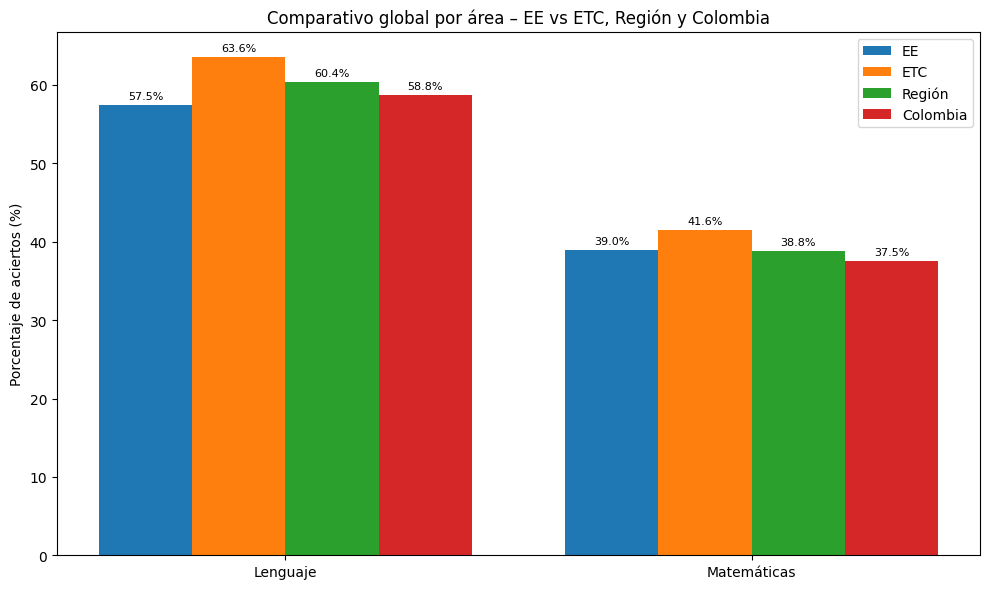

In [66]:
# Gráfico comparativo global por área con etiquetas y líneas de promedio
fig, ax = plt.subplots(figsize=(10,6))

areas = area_summary["AREA"]
x = range(len(areas))
bar_width = 0.2

# Barras
bars_ee = ax.bar([i - 1.5*bar_width for i in x], area_summary["% ACIERTOS EE"], width=bar_width, label="EE")
bars_etc = ax.bar([i - 0.5*bar_width for i in x], area_summary["% ACIERTOS ETC"], width=bar_width, label="ETC")
bars_reg = ax.bar([i + 0.5*bar_width for i in x], area_summary["% ACIERTOS REGÍON"], width=bar_width, label="Región")
bars_col = ax.bar([i + 1.5*bar_width for i in x], area_summary["% ACIERTOS COLOMBIA"], width=bar_width, label="Colombia")

# Etiquetas encima de las barras
for bars in [bars_ee, bars_etc, bars_reg, bars_col]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.1f}%", ha='center', va='bottom', fontsize=8)

# Líneas horizontales de promedio de cada área
#for i, area in enumerate(areas):
#    prom = area_summary.loc[i, "% ACIERTOS EE"]
#    ax.axhline(y=prom, color="blue", linestyle="--", linewidth=1, alpha=0.7)
#    ax.text(len(areas)-0.3, prom+0.3, f"Prom. EE {area}: {prom:.1f}%", color="blue", fontsize=8, ha="right")

ax.set_xticks(x)
ax.set_xticklabels(areas)
ax.set_ylabel("Porcentaje de aciertos (%)")
ax.set_title("Comparativo global por área – EE vs ETC, Región y Colombia")
ax.legend()

plt.tight_layout()
plt.show()

In [67]:
# Promedios globales por área
competencia_summary = df.groupby("COMPETENCIA")[['% ACIERTOS EE','% ACIERTOS ETC','% ACIERTOS REGÍON','% ACIERTOS COLOMBIA']].mean().reset_index()
competencia_summary

,COMPETENCIA,% ACIERTOS EE,% ACIERTOS ETC,% ACIERTOS REGÍON,% ACIERTOS COLOMBIA
0,Competencia comunicativa: comprensión de textos,57.500,63.600,60.440,58.7700
1,"Comunicación, representación y modelación",34.950,33.885,30.675,29.5000
2,Planteamiento y Resolución de problemas,46.925,50.445,47.645,46.1400
3,Razonamiento y Argumentación,37.045,40.940,38.450,37.1625


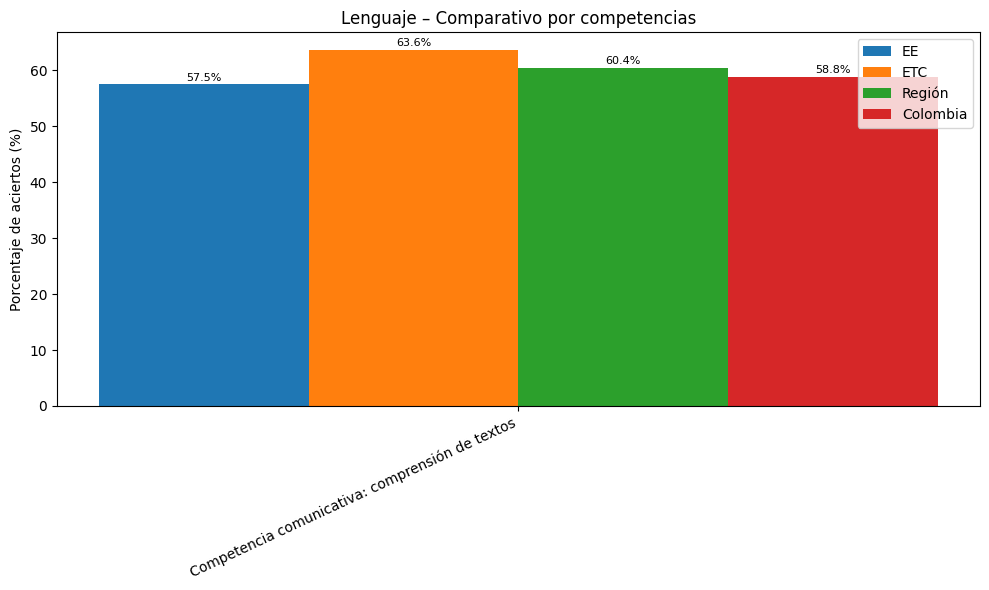

In [68]:
# Filtrar resultados por área
lenguaje = df[df["AREA"] == "Lenguaje"]
matematicas = df[df["AREA"] == "Matemáticas"]

# Gráfico por competencias de Lenguaje
fig, ax = plt.subplots(figsize=(10,6))

competencias = lenguaje["COMPETENCIA"].unique()
x = range(len(competencias))
bar_width = 0.2

# Calcular promedios por competencia en Lenguaje
comp_summary = lenguaje.groupby("COMPETENCIA")[['% ACIERTOS EE','% ACIERTOS ETC','% ACIERTOS REGÍON','% ACIERTOS COLOMBIA']].mean().reset_index()

bars_ee = ax.bar([i - 1.5*bar_width for i in x],  comp_summary["% ACIERTOS EE"], width=bar_width, label="EE")
bars_etc = ax.bar([i - 0.5*bar_width for i in x], comp_summary["% ACIERTOS ETC"], width=bar_width, label="ETC")
bars_reg = ax.bar([i + 0.5*bar_width for i in x], comp_summary["% ACIERTOS REGÍON"], width=bar_width, label="Región")
bars_col = ax.bar([i + 1.5*bar_width for i in x], comp_summary["% ACIERTOS COLOMBIA"], width=bar_width, label="Colombia")

# Etiquetas encima de las barras
for bars in [bars_ee, bars_etc, bars_reg, bars_col]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.3, f"{height:.1f}%", ha='center', va='bottom', fontsize=8)

# Líneas horizontales promedio EE por competencia
#for i, comp in enumerate(comp_summary["COMPETENCIA"]):
#    prom = comp_summary.loc[i, "% ACIERTOS EE"]
#    ax.axhline(y=prom, color="blue", linestyle="--", linewidth=0.8, alpha=0.6)
#    ax.text(len(comp_summary)-0.2, prom+0.3, f"{prom:.1f}%", color="blue", fontsize=7, ha="right")

ax.set_xticks(list(x))
ax.set_xticklabels(comp_summary["COMPETENCIA"], rotation=25, ha="right")
ax.set_ylabel("Porcentaje de aciertos (%)")
ax.set_title("Lenguaje – Comparativo por competencias")
ax.legend()

plt.tight_layout()
plt.show()

In [71]:
comp_summary_m

,COMPETENCIA,% ACIERTOS EE,% ACIERTOS ETC,% ACIERTOS REGÍON,% ACIERTOS COLOMBIA
0,"Comunicación, representación y modelación",34.950,33.885,30.675,29.5000
1,Planteamiento y Resolución de problemas,46.925,50.445,47.645,46.1400
2,Razonamiento y Argumentación,37.045,40.940,38.450,37.1625


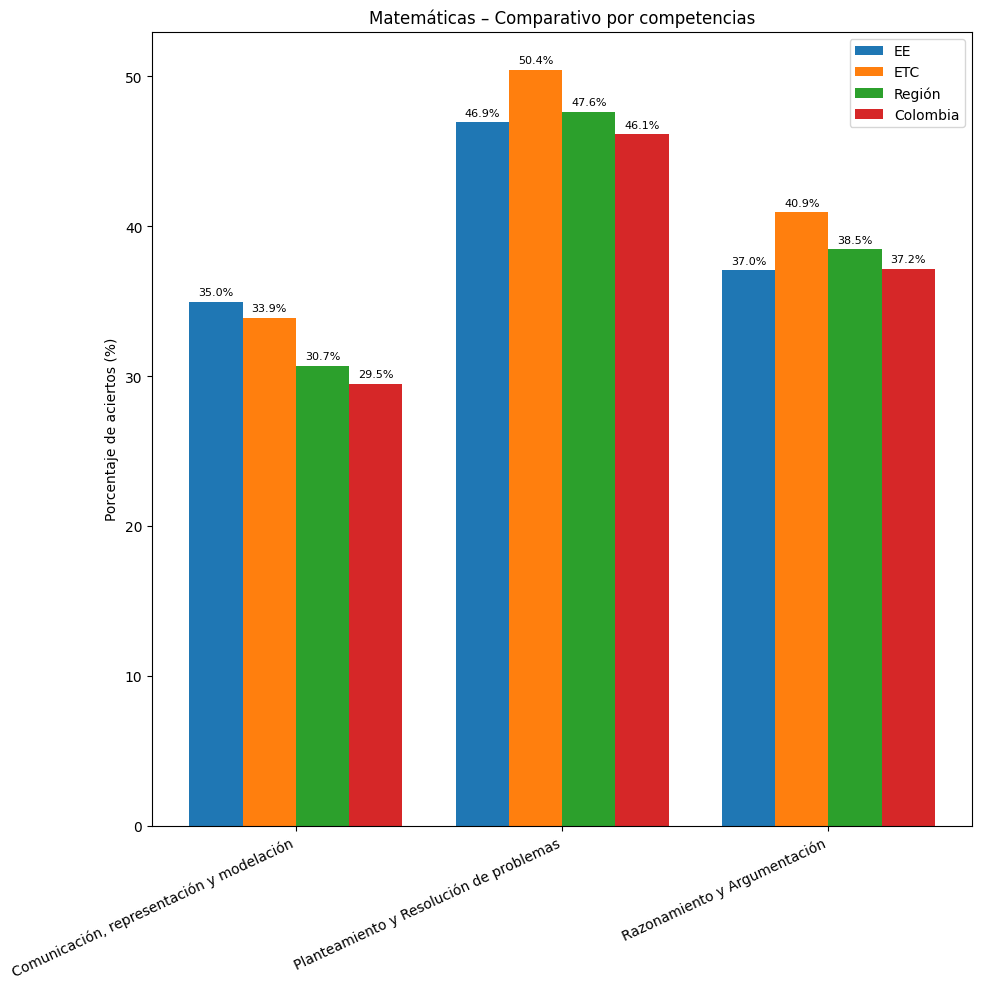

In [70]:
# Gráfico por competencias de Matemáticas
fig, ax = plt.subplots(figsize=(10,10))

competencias = matematicas["COMPETENCIA"].unique()
x = range(len(competencias))
bar_width = 0.2

# Calcular promedios por competencia en Matemáticas
comp_summary_m = matematicas.groupby("COMPETENCIA")[['% ACIERTOS EE','% ACIERTOS ETC','% ACIERTOS REGÍON','% ACIERTOS COLOMBIA']].mean().reset_index()

bars_ee = ax.bar([i - 1.5*bar_width for i in x],  comp_summary_m["% ACIERTOS EE"], width=bar_width, label="EE")
bars_etc = ax.bar([i - 0.5*bar_width for i in x], comp_summary_m["% ACIERTOS ETC"], width=bar_width, label="ETC")
bars_reg = ax.bar([i + 0.5*bar_width for i in x], comp_summary_m["% ACIERTOS REGÍON"], width=bar_width, label="Región")
bars_col = ax.bar([i + 1.5*bar_width for i in x], comp_summary_m["% ACIERTOS COLOMBIA"], width=bar_width, label="Colombia")

# Etiquetas encima de las barras
for bars in [bars_ee, bars_etc, bars_reg, bars_col]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.3, f"{height:.1f}%", ha='center', va='bottom', fontsize=8)

# Líneas horizontales promedio EE por competencia
#for i, comp in enumerate(comp_summary_m["COMPETENCIA"]):
#    prom = comp_summary_m.loc[i, "% ACIERTOS EE"]
#    ax.axhline(y=prom, color="blue", linestyle="--", linewidth=0.8, alpha=0.6)
#    ax.text(len(comp_summary_m)-0.2, prom+0.3, f"{prom:.1f}%", color="blue", fontsize=7, ha="right")

ax.set_xticks(list(x))
ax.set_xticklabels(comp_summary_m["COMPETENCIA"], rotation=25, ha="right")
ax.set_ylabel("Porcentaje de aciertos (%)")
ax.set_title("Matemáticas – Comparativo por competencias")
ax.legend()

plt.tight_layout()
plt.show()

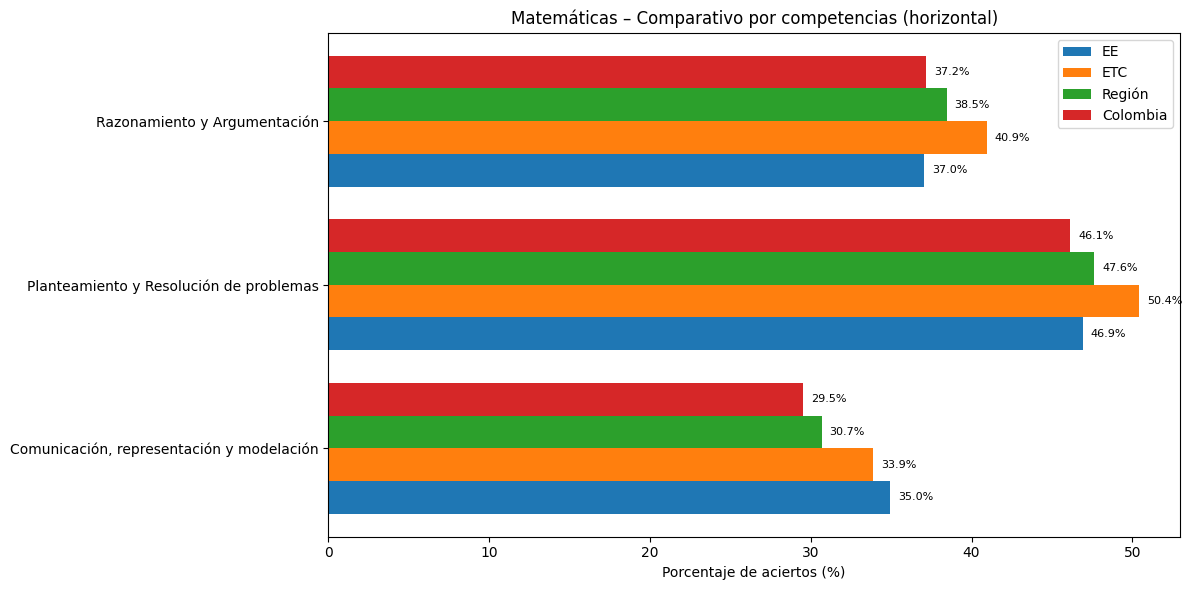

In [72]:
# Gráfico horizontal por competencias de Matemáticas
fig, ax = plt.subplots(figsize=(12,6))

competencias = comp_summary_m["COMPETENCIA"]
y = range(len(competencias))
bar_height = 0.2

# Barras horizontales
bars_ee = ax.barh([i - 1.5*bar_height for i in y], comp_summary_m['% ACIERTOS EE'], height=bar_height, label="EE")
bars_etc = ax.barh([i - 0.5*bar_height for i in y], comp_summary_m['% ACIERTOS ETC'], height=bar_height, label="ETC")
bars_reg = ax.barh([i + 0.5*bar_height for i in y], comp_summary_m['% ACIERTOS REGÍON'], height=bar_height, label="Región")
bars_col = ax.barh([i + 1.5*bar_height for i in y], comp_summary_m['% ACIERTOS COLOMBIA'], height=bar_height, label="Colombia")

# Etiquetas al final de las barras
for bars in [bars_ee, bars_etc, bars_reg, bars_col]:
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", va='center', fontsize=8)

## Líneas verticales de promedio EE por competencia
#for i, comp in enumerate(comp_summary_m["COMPETENCIA"]):
#    prom = comp_summary_m.loc[i, "% ACIERTOS EE"]
#    ax.axvline(x=prom, color="blue", linestyle="--", linewidth=0.8, alpha=0.6)
#    ax.text(prom+0.3, len(comp_summary_m)-0.3, f"{prom:.1f}%", color="blue", fontsize=7, ha="left")

ax.set_yticks(list(y))
ax.set_yticklabels(comp_summary_m["COMPETENCIA"])
ax.set_xlabel("Porcentaje de aciertos (%)")
ax.set_title("Matemáticas – Comparativo por competencias (horizontal)")
ax.legend()

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_13568\3961882367.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


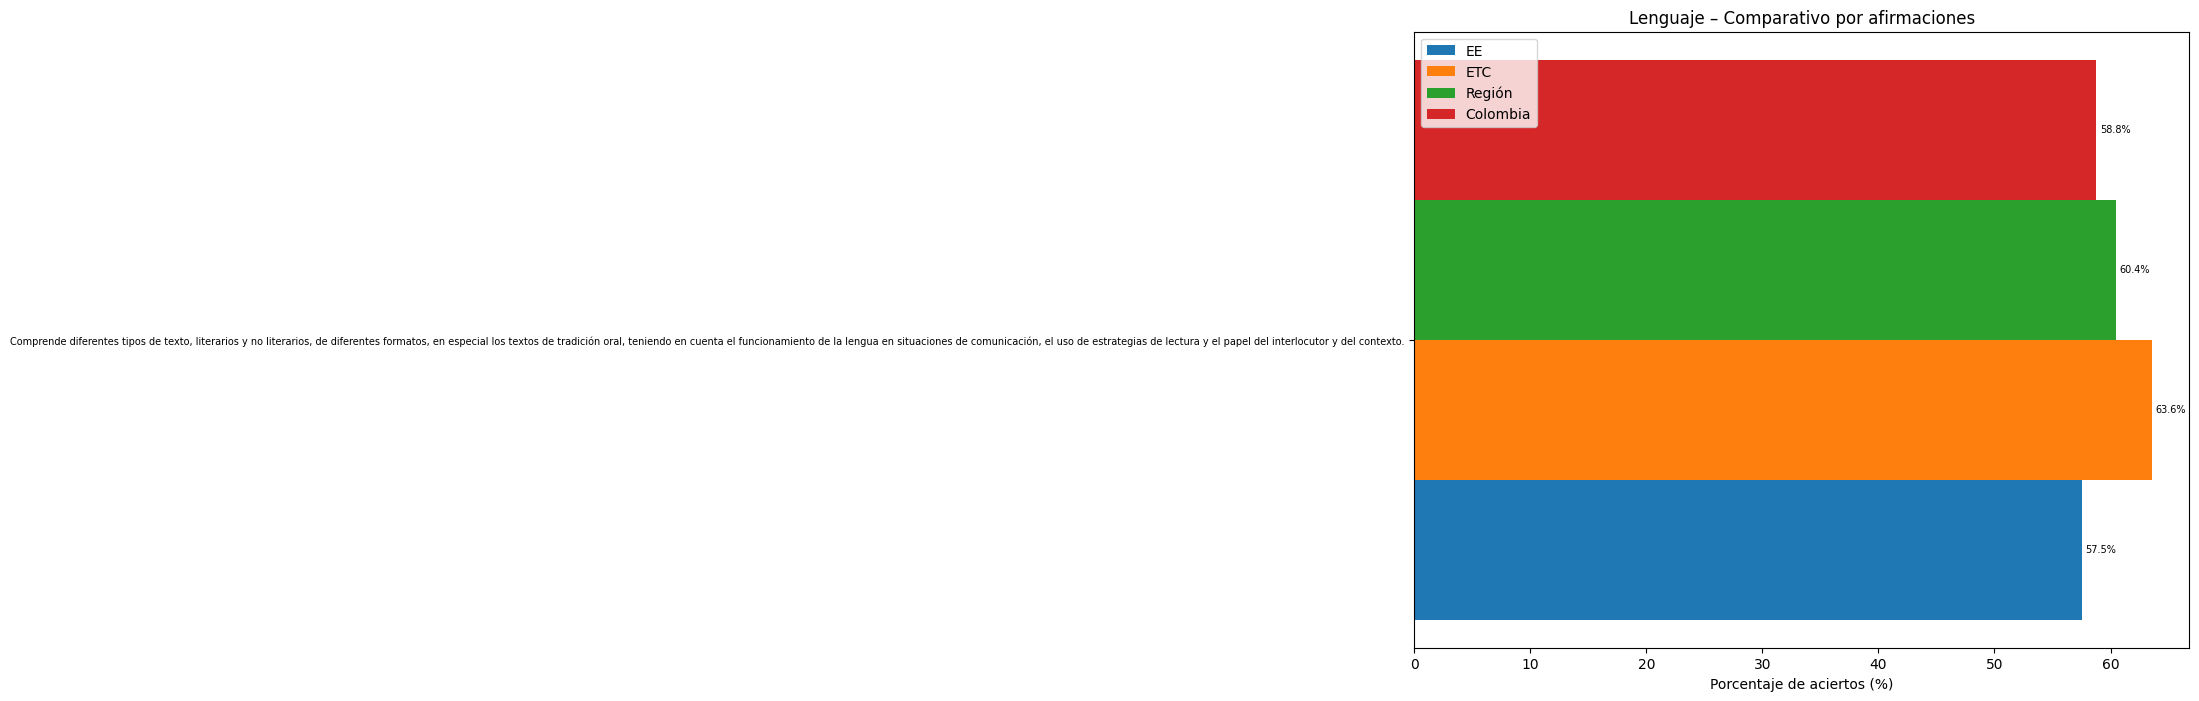

In [73]:
# Tomemos ejemplo: afirmaciones de Lenguaje
afirmaciones_lenguaje = df[df["AREA"]=="Lenguaje"]

# Gráfico comparativo por afirmaciones (Lenguaje)
fig, ax = plt.subplots(figsize=(10,8))

afirmaciones = afirmaciones_lenguaje["AFIRMACIÓN"]
y = range(len(afirmaciones))
bar_height = 0.2

bars_ee = ax.barh([i - 1.5*bar_height for i in y], afirmaciones_lenguaje['% ACIERTOS EE'], height=bar_height, label="EE")
bars_etc = ax.barh([i - 0.5*bar_height for i in y], afirmaciones_lenguaje['% ACIERTOS ETC'], height=bar_height, label="ETC")
bars_reg = ax.barh([i + 0.5*bar_height for i in y], afirmaciones_lenguaje['% ACIERTOS REGÍON'], height=bar_height, label="Región")
bars_col = ax.barh([i + 1.5*bar_height for i in y], afirmaciones_lenguaje['% ACIERTOS COLOMBIA'], height=bar_height, label="Colombia")

# Etiquetas en barras
for bars in [bars_ee, bars_etc, bars_reg, bars_col]:
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", va='center', fontsize=7)

ax.set_yticks(list(y))
ax.set_yticklabels(afirmaciones, fontsize=7)
ax.set_xlabel("Porcentaje de aciertos (%)")
ax.set_title("Lenguaje – Comparativo por afirmaciones")
ax.legend()

plt.tight_layout()
plt.show()

In [74]:
# Crear un diccionario para asignar códigos a las afirmaciones de Lenguaje
afirmaciones_lenguaje = df[df["AREA"]=="Lenguaje"].copy()
afirmaciones_dict_lenguaje = {f"A{i+1}L": afirmacion for i, afirmacion in enumerate(afirmaciones_lenguaje["AFIRMACIÓN"])}

# crear un diccionario para asignar códigos a las afirmaciones de Matemáticas
afirmaciones_matematicas = df[df["AREA"]=="Matemáticas"].copy()
afirmaciones_dict_matematicas = {f"A{i+1}M": afirmacion for i, afirmacion in enumerate(afirmaciones_matematicas["AFIRMACIÓN"])}

# Reemplazar los textos largos por los códigos en el DataFrame
afirmaciones_matematicas["CODIGO"] = [f"A{i+1}M" for i in range(len(afirmaciones_matematicas))]

# Reemplazar los textos largos por los códigos en el DataFrame
afirmaciones_lenguaje["CODIGO"] = [f"A{i+1}L" for i in range(len(afirmaciones_lenguaje))]

# Unir ambos DataFrames de afirmaciones
afirmaciones_combinadas = pd.concat([afirmaciones_lenguaje, afirmaciones_matematicas], ignore_index=True)
afirmaciones_combinadas

,GRADO,AREA,COMPETENCIA,AFIRMACIÓN,% ACIERTOS EE,% ACIERTOS ETC,% ACIERTOS REGÍON,% ACIERTOS COLOMBIA,CODIGO
0,9°,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",57.50,63.60,60.44,58.77,A1L
1,9°,Matemáticas,Planteamiento y Resolución de problemas,Reconoce el significado y las distintas repres...,52.57,56.62,54.13,52.16,A1M
2,9°,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas aditivos, multiplicativos, ...",41.28,44.27,41.16,40.12,A2M
3,9°,Matemáticas,Razonamiento y Argumentación,"Resuelve problemas aditivos, multiplicativos, ...",25.71,33.12,31.89,30.53,A3M
4,9°,Matemáticas,Razonamiento y Argumentación,Resuelve problemas de medición que involucren ...,42.19,45.84,42.93,41.32,A4M
5,9°,Matemáticas,Razonamiento y Argumentación,Comprende las relaciones de congruencia y seme...,34.29,35.45,34.46,34.18,A5M
6,9°,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,45.99,49.35,44.52,42.62,A6M
7,9°,Matemáticas,"Comunicación, representación y modelación",Reconoce el significado y las distintas repres...,34.00,36.16,33.00,31.15,A7M
8,9°,Matemáticas,"Comunicación, representación y modelación",Reconoce distintos tipos de representación en ...,35.90,31.61,28.35,27.85,A8M


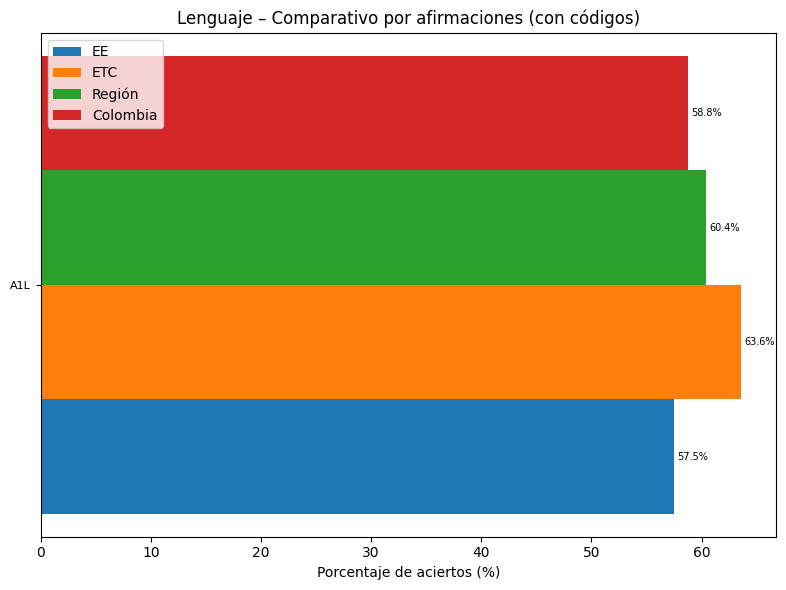

In [75]:
# Gráfico comparativo por afirmaciones (Lenguaje) con códigos
fig, ax = plt.subplots(figsize=(8,6))

y = range(len(afirmaciones_lenguaje))
bar_height = 0.2

bars_ee = ax.barh([i - 1.5*bar_height for i in y], afirmaciones_lenguaje['% ACIERTOS EE'], height=bar_height, label="EE")
bars_etc = ax.barh([i - 0.5*bar_height for i in y], afirmaciones_lenguaje['% ACIERTOS ETC'], height=bar_height, label="ETC")
bars_reg = ax.barh([i + 0.5*bar_height for i in y], afirmaciones_lenguaje['% ACIERTOS REGÍON'], height=bar_height, label="Región")
bars_col = ax.barh([i + 1.5*bar_height for i in y], afirmaciones_lenguaje['% ACIERTOS COLOMBIA'], height=bar_height, label="Colombia")

# Etiquetas en barras
for bars in [bars_ee, bars_etc, bars_reg, bars_col]:
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", va='center', fontsize=7)

ax.set_yticks(list(y))
ax.set_yticklabels(afirmaciones_lenguaje["CODIGO"], fontsize=8)
ax.set_xlabel("Porcentaje de aciertos (%)")
ax.set_title("Lenguaje – Comparativo por afirmaciones (con códigos)")
ax.legend()

plt.tight_layout()
plt.show()

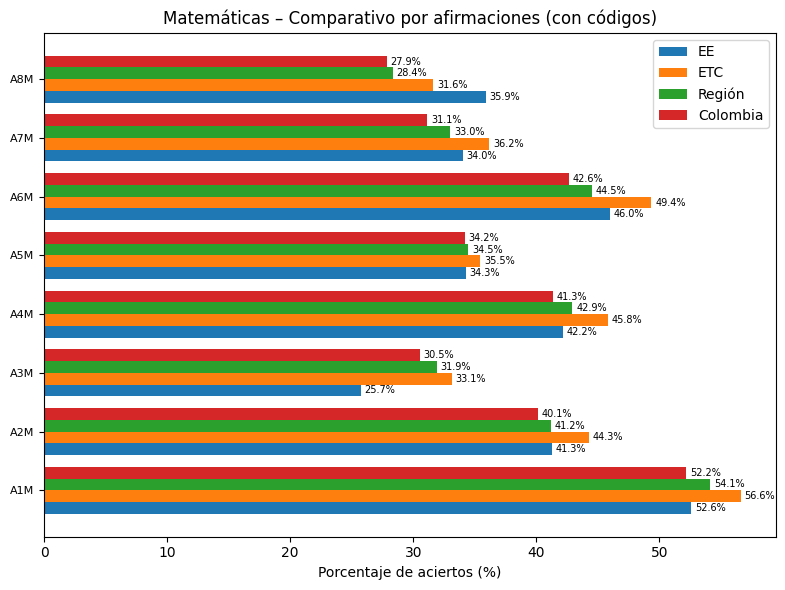

{'A1M': 'Reconoce el significado y las distintas representaciones de los números racionales.',
 'A2M': 'Resuelve problemas aditivos, multiplicativos, de potenciación, radicación o de proporcionalidad utilizando números racionales.',
 'A3M': 'Resuelve problemas aditivos, multiplicativos, de potenciación, radicación o de proporcionalidad utilizando números racionales.',
 'A4M': 'Resuelve problemas de medición que involucren figuras bidimensionales o tridimensionales.',
 'A5M': 'Comprende las relaciones de congruencia y semejanza entre figuras bidimensionales.',
 'A6M': 'Analiza los elementos asociados a la recolección de datos o a la observación de un experimento aleatorio para establecer conclusiones y tomar decisiones.',
 'A7M': 'Reconoce el significado y las distintas representaciones de los números racionales.',
 'A8M': 'Reconoce distintos tipos de representación en situaciones de recolección de datos.'}

In [76]:
# Gráfico comparativo por afirmaciones (Matemáticas) con códigos
fig, ax = plt.subplots(figsize=(8,6))

y = range(len(afirmaciones_matematicas))
bar_height = 0.2

bars_ee = ax.barh([i - 1.5*bar_height for i in y], afirmaciones_matematicas['% ACIERTOS EE'], height=bar_height, label="EE")
bars_etc = ax.barh([i - 0.5*bar_height for i in y], afirmaciones_matematicas['% ACIERTOS ETC'], height=bar_height, label="ETC")
bars_reg = ax.barh([i + 0.5*bar_height for i in y], afirmaciones_matematicas['% ACIERTOS REGÍON'], height=bar_height, label="Región")
bars_col = ax.barh([i + 1.5*bar_height for i in y], afirmaciones_matematicas['% ACIERTOS COLOMBIA'], height=bar_height, label="Colombia")

# Etiquetas en barras
for bars in [bars_ee, bars_etc, bars_reg, bars_col]:
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", va='center', fontsize=7)

ax.set_yticks(list(y))
ax.set_yticklabels(afirmaciones_matematicas["CODIGO"], fontsize=8)
ax.set_xlabel("Porcentaje de aciertos (%)")
ax.set_title("Matemáticas – Comparativo por afirmaciones (con códigos)")
ax.legend()

plt.tight_layout()
plt.show()

# Mostrar el diccionario de códigos y afirmaciones para Matemáticas
afirmaciones_dict_matematicas

In [57]:
!pip install tabulate


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
from tabulate import tabulate

# Función para aplicar semáforo en LaTeX con \cellcolor
def aplicar_semaforo(valor):
    if valor >= 70:
        return f"\\cellcolor{{green!40}} {valor:.2f}"
    elif 40 <= valor <= 60:
        return f"\\cellcolor{{yellow!40}} {valor:.2f}"
    elif 21 <= valor <= 39:
        return f"\\cellcolor{{orange!40}} {valor:.2f}"
    else:
        return f"\\cellcolor{{red!40}} {valor:.2f}"

# Copiar tabla completa y aplicar semáforo en columna % EE
tabla_coloreada = afirmaciones_combinadas.copy()
tabla_coloreada["% ACIERTOS EE"] = tabla_coloreada["% ACIERTOS EE"].apply(aplicar_semaforo)

# Convertir a LaTeX
latex_tabla = "\\begin{table}[H]\n\\centering\n\\begin{tabular}{|c|c|c|c|c|}\n\\hline\n"
latex_tabla += "\\textbf{Código} & \\textbf{\\% EE} & \\textbf{\\% ETC} & \\textbf{\\% Región} & \\textbf{\\% Colombia} \\\\ \\hline\n"

for _, row in tabla_coloreada.iterrows():
    latex_tabla += f"{row['CODIGO']} & {row['% ACIERTOS EE']} & {row['% ACIERTOS ETC']:.2f} & {row['% ACIERTOS REGÍON']:.2f} & {row['% ACIERTOS COLOMBIA']:.2f} \\\\ \\hline\n"

latex_tabla += "\\end{tabular}\n\\caption{Resultados de afirmaciones con semáforo aplicado en la columna \\% EE (grado 5°).}\n\\end{table}"

latex_tabla

'\\begin{table}[H]\n\\centering\n\\begin{tabular}{|c|c|c|c|c|}\n\\hline\n\\textbf{Código} & \\textbf{\\% EE} & \\textbf{\\% ETC} & \\textbf{\\% Región} & \\textbf{\\% Colombia} \\\\ \\hline\nA1L & \\cellcolor{yellow!40} 57.74 & 60.05 & 59.47 & 57.83 \\\\ \\hline\nA1M & \\cellcolor{yellow!40} 46.79 & 49.13 & 48.77 & 36.98 \\\\ \\hline\nA2M & \\cellcolor{orange!40} 32.49 & 34.17 & 34.66 & 28.57 \\\\ \\hline\nA3M & \\cellcolor{orange!40} 37.02 & 39.88 & 37.19 & 36.59 \\\\ \\hline\nA4M & \\cellcolor{green!40} 70.77 & 77.47 & 74.56 & 72.63 \\\\ \\hline\nA5M & \\cellcolor{yellow!40} 48.84 & 51.63 & 51.74 & 51.70 \\\\ \\hline\nA6M & \\cellcolor{orange!40} 35.61 & 39.37 & 39.23 & 37.53 \\\\ \\hline\nA7M & \\cellcolor{red!40} 39.04 & 41.29 & 40.05 & 37.84 \\\\ \\hline\nA8M & \\cellcolor{orange!40} 35.38 & 44.04 & 42.36 & 40.55 \\\\ \\hline\nA9M & \\cellcolor{orange!40} 27.04 & 28.24 & 27.34 & 27.01 \\\\ \\hline\nA10M & \\cellcolor{yellow!40} 54.42 & 60.33 & 60.89 & 60.05 \\\\ \\hline\n\\end{tab

## GRADO 9°

## SCRAPING INFO

In [ ]:
#!pip install lxml
#!pip install beautifulsoup4

In [37]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import Select
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

import pandas as pd
import re
import time
from datetime import datetime

import lxml.html as lh
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings('ignore')

In [39]:
def open_web(url):

    # define 'driver' variable
    driver = webdriver.Chrome()
    driver.maximize_window()

    # open Google Chrome with chromedriver
    driver.get(url)

    return driver

def login_web(user, clave):

    # Casillas para ingreso de credenciales
    input_user = driver.find_element("xpath",'//input[@name="email"]')
    input_pass = driver.find_element("xpath",'//input[@name="pass"]')

    # Escribir la credenciales
    input_user.send_keys(user)
    input_pass.send_keys(clave)

    time.sleep(10)

    input_pa = driver.find_element("xpath",'//*[@id="loginForm"]/a[1]')
    input_pa.click()

# Función para obtener colores en columna 4, que identifica si es correcta o no la respuesta
def color_respuesta(html_tabla):
    # importar librerias
    from bs4 import BeautifulSoup
    # Procesar con BeautifulSoup para obtener colores en columna 4
    soup = BeautifulSoup(html_tabla, 'html.parser')
    # Encontrar todas las filas de la tabla
    rows = soup.find_all("tr")
    # Lista para guardar los datos
    data = []

    for row in rows[1:]:  # Saltar el encabezado
        cols = row.find_all("td")
        if len(cols) < 7:
            continue

        # Extraer color de ícono (basado en clase col_red o col_green)
        color_span = cols[4].find("span")
        color = "Rojo" if "col_red" in color_span.get("class", []) else "Verde" if "col_green" in color_span.get("class", []) else "Sin color"

        # Extraer los otros textos
        fila = {
            "N°": cols[0].text.strip(),
            "Área": cols[1].text.strip(),
            "Competencia": cols[2].text.strip(),
            "Afirmación": cols[3].text.strip(),
            "Resultado": color,
            "Respuesta Participante": cols[5].text.strip(),
            "Respuesta Correcta": cols[6].text.strip(),
        }
        data.append(fila)

    # Convertir a DataFrame
    df_resultado = pd.DataFrame(data)

    # Mostrar DataFrame
    return df_resultado

In [40]:
url = "https://www.quieroserquierosaber.edu.co/rectores/"
driver  = open_web(url)

In [ ]:
login_web("johnjhernandezp@itagui.edu.co", "Ieoreste2025*")

In [42]:
# Menu primera aplicación
element = driver.find_element(By.XPATH, "//*[text()='Primera Aplicación Nacional']")
element.click()

In [43]:
# Seleccionar resultados por estudiante
element = driver.find_element(By.XPATH, "//*[text()='Resultados por estudiante']")
element.click()

In [44]:
# Seleccionar el grado
# 5° Quinto
#' 9° Noveno'
element = driver.find_element(By.XPATH, "//*[text()=' 9° Noveno']")
element.click()

In [ ]:
# Seleccionar grupo
grupos = ['501 - 5A', '502 - 5B', '503 - 5C', '504 - 5D']
grupo = '501 - 5A'
element = driver.find_element(By.XPATH, f"//*[text()='{grupo}']")
element.click()

In [ ]:
# Obtener opciones de dropdown
select_element = driver.find_element(By.NAME, 'alumno_id')
select = Select(select_element)
options = [option.text for option in select.options]
options.remove('Seleccione un alumno')
options 

In [16]:
#grupos = ['501 - 5A', '502 - 5B', '503 - 5C', '504 - 5D']
grupos = ['901 - 9A', '902 - 9B', '903 - 9C', '904 - 9D']
for grupo in grupos:
    print(grupo)
    # Seleccionar grupo
    element = driver.find_element(By.XPATH, f"//*[text()='{grupo}']")
    element.click()
    time.sleep(2)

    # Obtener opciones de dropdown
    select_element = driver.find_element(By.NAME, 'alumno_id')
    select = Select(select_element)
    options = [option.text for option in select.options]
    options.remove('Seleccione un alumno')

    time.sleep(5)

901 - 9A
902 - 9B
903 - 9C
904 - 9D


In [18]:
# Para copiar tabla de respuestas

# Creamos DataFrame vacío para almacenar todas las respuestas
df_CA = pd.DataFrame(columns=["N°", "Área", "Competencia", "Afirmación", "Resultado", "Respuesta Participante", "Respuesta Correcta"])
# lista de grupos
#grupos = ['501 - 5A', '502 - 5B', '503 - 5C', '504 - 5D']
grupos = ['901 - 9A', '902 - 9B', '903 - 9C', '904 - 9D']
# Iterar sobre cada grupo y estudiante
for grupo in grupos:
    print(grupo)
    # Seleccionar grupo
    element = driver.find_element(By.XPATH, f"//*[text()='{grupo}']")
    element.click()
    time.sleep(2)

    # Obtener opciones de dropdown
    select_element = driver.find_element(By.NAME, 'alumno_id')
    select = Select(select_element)
    options = [option.text for option in select.options]
    options.remove('Seleccione un alumno')
    time.sleep(2)
    for i, option in enumerate(options):
        print(option)
        driver.find_element("xpath",f'//*[@id="filtrosAdicionales"]/div[3]/div/select/option[{i}+2]').click()
        time.sleep(2)
        # Seleccionar boton de preguntas contestadas
        element = driver.find_element(By.XPATH, "//*[text()='Preguntas contestadas']")
        element.click()
        time.sleep(2)
        # Obtener la tabla
        tabla = driver.find_element("xpath",'//*[@id="table_id"]')
        # Extraer el HTML de la tabla
        html_tabla = tabla.get_attribute('outerHTML')
        # Convertir el HTML a un DataFrame de pandas
        df_respuestas = color_respuesta(html_tabla)
        # Agregar columna de estudiante
        df_respuestas['Estudiante'] = option
        df_respuestas['Grupo'] = grupo
        # Concatenar al DataFrame principal
        df_CA = pd.concat([df_CA, df_respuestas], ignore_index=True)

df_CA

901 - 9A
ALEJANDRO ATEHORTUA TABORDA
ALEJANDRO MARIN RAMIREZ
ALYNA RAMIREZ MONTOYA
ANA SOFIA VASQUEZ LOAIZA
ASHLEY NATHALIA ARRIETA RONDON
ASHLY SADAY BLANCO BLANCO
CAMILO VALENCIA COLORADO
CRHISTIAN BARRERA PAVAS
EMMANUEL BRICEÑO MORALES
HENRY ALBERTO CIFUENTES ZAPATA
Isabel Sofía Sosa Uribe
ISABELA JIMENEZ JARAMILLO
ISABELLA VALENTINA RINCON MORALES
JUAN ANDRES ARDILA AREIZA
JUAN FELIPE MIRA ROJAS
JUAN JOSE BASTIDAS NARVAEZ
LADY MARIANA ROJAS TORRES
LUCIANA GOMEZ TAMAYO
LUCIANA SUAREZ VELEZ
LUCIANA TABORDA RESTREPO
LUCIANA VARGAS RIOS
MARIA ANGEL VELEZ HERNANDEZ
MARIA CLARA ECHEVERRI CARO
MARIA ISABEL CIRO ATEHORTUA
MARIA ISABELLA MONSALVE LEON
MARIA JOSE MESA GIL
MARIA PAULA TORO RIVERA
MARIANA BEDOYA CARTAGENA
MARIANA OSPINA CANO
MARIANA TORRES VELEZ
MATIAS ROJAS VARGAS
MELANY GUTIERREZ AGUDELO
MIGUEL ANGEL GONZALEZ CARMONA
MIGUEL ANGEL VARGAS RODRIGUEZ
NICOLAS URIBE PEREZ
NICOLL CANO SALDARRIAGA
NICOLLE ANDREA OROZCO ESTRADA
PAULINA URIBE GAVIRIA
SAMUEL CORREA GARCIA
SARA VANESSA 

,N°,Área,Competencia,Afirmación,Resultado,Respuesta Participante,Respuesta Correcta,Estudiante,Grupo
0,86,Matemáticas,"Comunicación, Modelación y Representación",Reconoce distintos tipos de representación en ...,Verde,Evento S y evento Q.,Evento S y evento Q.,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
1,85,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas de medición que involucren ...,Verde,Área superficial total en cm2 y volumen en cm3.,Área superficial total en cm2 y volumen en cm3.,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
2,82,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,Verde,El primer rostro queda clasificado en el grupo...,El primer rostro queda clasificado en el grupo...,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
3,81,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,Rojo,Bolsa 3.,Bolsa 2.,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
4,80,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,Rojo,Negro.,Gris claro.,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
...,...,...,...,...,...,...,...,...,...
7019,24,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",Rojo,El universo,El Ser Bueno,YENNIFER CUESTA SUAREZ,904 - 9D
7020,23,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",Rojo,Desea unir o conectar dos oraciones sobre el m...,Le da continuidad al tema del que viene hablando.,YENNIFER CUESTA SUAREZ,904 - 9D
7021,22,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",Verde,"Mover, correr, quitar, ajustar","Mover, correr, quitar, ajustar",YENNIFER CUESTA SUAREZ,904 - 9D
7022,20,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",Verde,"Mitológico, porque ambos textos tratan de expl...","Mitológico, porque ambos textos tratan de expl...",YENNIFER CUESTA SUAREZ,904 - 9D


In [20]:
# Eliminar duplicados por columnas 'N°', 'Área', 'Competencia', 'Afirmación', 'Grupo', 'Estudiante'
df_CA.drop_duplicates(subset=['N°', 'Estudiante'], inplace=True)
df_CA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7024 entries, 0 to 7023
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   N°                      7024 non-null   object
 1   Área                    7024 non-null   object
 2   Competencia             7024 non-null   object
 3   Afirmación              7024 non-null   object
 4   Resultado               7024 non-null   object
 5   Respuesta Participante  7024 non-null   object
 6   Respuesta Correcta      7024 non-null   object
 7   Estudiante              7024 non-null   object
 8   Grupo                   7024 non-null   object
dtypes: object(9)
memory usage: 494.0+ KB


In [19]:
df_CA.to_excel("C:/Users/User/Downloads/df_CA9to.xlsx", index=False)

In [37]:
# eliminar ultima columna
df.drop(columns=[df.columns[-1]],inplace=True)
# Eliminar columnas completamente vacías
df.dropna(axis=1, how='all', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   #                       42 non-null     int64 
 1   Area                    42 non-null     object
 2   Competencia             42 non-null     object
 3   Afirmacion              42 non-null     object
 4   Respuesta Participante  37 non-null     object
 5   Respuesta Correcta      37 non-null     object
dtypes: int64(1), object(5)
memory usage: 2.1+ KB


In [185]:
# Para descargar respuestas
df = pd.DataFrame(columns=["N°", "Área", "Competencia", "Afirmación", "Resultado", "Respuesta Participante", "Respuesta Correcta"])
grupos = ['501 - 5A', '502 - 5B', '503 - 5C', '504 - 5D']
for grupo in grupos:
    print(grupo)
    # Seleccionar grupo
    element = driver.find_element(By.XPATH, f"//*[text()='{grupo}']")
    element.click()
    time.sleep(2)

    # Obtener opciones de dropdown
    select_element = driver.find_element(By.NAME, 'alumno_id')
    select = Select(select_element)
    options = [option.text for option in select.options]
    options.remove('Seleccione un alumno')
    time.sleep(2)
    for i, option in enumerate(options):
        print(option)
        driver.find_element("xpath",f'//*[@id="filtrosAdicionales"]/div[3]/div/select/option[{i}+2]').click()
        time.sleep(2)
        # descargar respuestas
        driver.find_element(By.XPATH, "/html/body/section/div/div[2]/div[2]/div[2]/div/div[1]/div[2]/div[2]/a").click()

501 - 5A
ALFREDO ALEXANDER MENDOZA ROSARIO
ANA SOFIA CARTAGENA GIL
ANTONIA DUQUE MOLINA
BRAHIAN STIVEN IRAL SERNA
Carolina Castaño Gómez
CELESTE UPEGUI BERRIO
DANIEL ORTIZ AGUDELO
DYLAN JAVIER SARMIENTO RODRIGUEZ
GABRIELA BLANDON GALLEGO
HEISER JHOSNEL CORDOVA MAESTRE
ISAAC CARDONA YARCE
ISAAC DURAN CORREALES
ISAAC OSSA BUSTAMANTE
ISABELLA CASTAÑO PEREZ
ISABELLA OSPINA CASTAÑO
JACOB ISAZA VELEZ
JESUS ADRIAN ALZATE GUEVARA
JOSHUAN VALENCIA JARAMILLO
JUAN SEBASTIAN CEFERINO CORREA
JULIETA URIBE PEREZ
LUCIANA CARMONA MEJIA
MARIA ESTEFANIA GIRALDO HENAO
MARIANA RUIZ BENITEZ
MARIANGEL GRAJALES ARISTIZABAL
MARIANGEL HIGUITA ALVAREZ
MIGUEL ANGEL BENITEZ RAMIREZ
NOEMI PAOLA OJEDA PALOMINO
ORNELLA ALESSANDRA FREITES TRUJILLANO
PAULINA CELESTE CORASPE GIL
RONALDO QUINTERO HENAO
SAJARA VARGAS ROLDAN
SALOME CAMARGO LONDOÑO
SALOME PEREZ BOTERO
SAMANTHA ZAPATA VILLEGAS
SAMUEL ECHEVERRI MADRID
Sofia Castaño Gómez
THOMAS DELGADO LOAIZA
THOMAS TORRES BALDOVINO
YERALDINE GARCIA RAMIREZ
502 - 5B
AARON AL

In [179]:
# Para descargar respuestas
df = pd.DataFrame(columns=["N°", "Área", "Competencia", "Afirmación", "Resultado", "Respuesta Participante", "Respuesta Correcta"])
grupos = ['901 - 9A', '902 - 9B', '903 - 9C', '904 - 9D']
for grupo in grupos:
    print(grupo)
    # Seleccionar grupo
    element = driver.find_element(By.XPATH, f"//*[text()='{grupo}']")
    element.click()
    time.sleep(2)

    # Obtener opciones de dropdown
    select_element = driver.find_element(By.NAME, 'alumno_id')
    select = Select(select_element)
    options = [option.text for option in select.options]
    options.remove('Seleccione un alumno')
    time.sleep(2)
    for i, option in enumerate(options):
        print(option)
        driver.find_element("xpath",f'//*[@id="filtrosAdicionales"]/div[3]/div/select/option[{i}+2]').click()
        time.sleep(2)
        # descargar respuestas
        driver.find_element(By.XPATH, "/html/body/section/div/div[2]/div[2]/div[2]/div/div[1]/div[2]/div[2]/a").click()
        time.sleep(2)

901 - 9A
ALEJANDRO ATEHORTUA TABORDA
ALEJANDRO MARIN RAMIREZ
ALYNA RAMIREZ MONTOYA
ANA SOFIA VASQUEZ LOAIZA
ASHLEY NATHALIA ARRIETA RONDON
ASHLY SADAY BLANCO BLANCO
CAMILO VALENCIA COLORADO
CRHISTIAN BARRERA PAVAS
EMMANUEL BRICEÑO MORALES
HENRY ALBERTO CIFUENTES ZAPATA
Isabel Sofía Sosa Uribe
ISABELA JIMENEZ JARAMILLO
ISABELLA VALENTINA RINCON MORALES
JUAN ANDRES ARDILA AREIZA
JUAN FELIPE MIRA ROJAS
JUAN JOSE BASTIDAS NARVAEZ
LADY MARIANA ROJAS TORRES
LUCIANA GOMEZ TAMAYO
LUCIANA SUAREZ VELEZ
LUCIANA TABORDA RESTREPO
LUCIANA VARGAS RIOS
MARIA ANGEL VELEZ HERNANDEZ
MARIA CLARA ECHEVERRI CARO
MARIA ISABEL CIRO ATEHORTUA
MARIA ISABELLA MONSALVE LEON
MARIA JOSE MESA GIL
MARIA PAULA TORO RIVERA
MARIANA BEDOYA CARTAGENA
MARIANA OSPINA CANO
MARIANA TORRES VELEZ
MATIAS ROJAS VARGAS
MELANY GUTIERREZ AGUDELO
MIGUEL ANGEL GONZALEZ CARMONA
MIGUEL ANGEL VARGAS RODRIGUEZ
NICOLAS URIBE PEREZ
NICOLL CANO SALDARRIAGA
NICOLLE ANDREA OROZCO ESTRADA
PAULINA URIBE GAVIRIA
SAMUEL CORREA GARCIA
SARA VANESSA 

In [15]:
# mostrar todos archivos en la carpeta D:/Repositorios/R_IEOS/Resultados_Simulacro_ICFES.xlsx
import os
#"O:\Mi unidad\Orestes\Procesos_Acd\Quiero ser quiero saber\Respuestas por estudiante"
files_5 = os.listdir('O:/Mi unidad/Orestes/Procesos_Acd/Quiero ser quiero saber/Respuestas por estudiante 5')
files_9 = os.listdir('O:/Mi unidad/Orestes/Procesos_Acd/Quiero ser quiero saber/Respuestas por estudiante 9')
files_9[0] = 'reporte_alumno_1376320_20250929_182646.xlsx'
print('files_9',len(files_9)
        ,'files_5',len(files_5))

files_9 177 files_5 139


In [16]:
files_9[0]

'reporte_alumno_1376320_20250929_182646.xlsx'

In [24]:
#df_5 = pd.read_excel('O:/Mi unidad/Orestes/Procesos_Acd/Quiero ser quiero saber/Respuestas por estudiante 5/reporte_alumno_716593_20250929_184819.xlsx')
df_9 = pd.read_excel('O:/Mi unidad/Orestes/Procesos_Acd/Quiero ser quiero saber/Respuestas por estudiante 9/reporte_alumno_8567_20250929_183331.xlsx')
df_9.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,REPORTE,REPORTE DEL ESTUDIANTE,NaN,NaN,NaN,NaN,NaN,NaN
2,SECRETARIA,ITAGUI,NaN,NaN,NaN,NaN,NaN,NaN
3,DEPARTAMENTO,Antioquia,NaN,NaN,NaN,NaN,NaN,NaN
4,MUNICIPIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,EE,INSTITUCIÓN EDUCATIVA ORESTE SINDICI,NaN,NaN,NaN,NaN,NaN,NaN
6,DANE,105360000491,NaN,NaN,NaN,NaN,NaN,NaN
7,NOMBRE,NICOLAS PORRAS LOAIZA,NaN,NaN,NaN,NaN,NaN,NaN
8,SEXO,MASCULINO,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df_9.iloc[7, 1]

'NICOLAS PORRAS LOAIZA'

In [226]:
dk.columns.to_list()

['Ver Pregunta',
 'Pregunta ID',
 'Área',
 'Competencia',
 'Afirmaciones',
 'Evidencia',
 'Respuesta Participante',
 'Respuesta Correcta',
 'ESTUDIANTE']

In [18]:
os.listdir('O:/Mi unidad/Orestes/Procesos_Acd/Quiero ser quiero saber/Respuestas por estudiante 9')[0]

'~$reporte_alumno_1376320_20250929_175158.xlsx'

In [12]:
'~$reporte_alumno_1376320_20250929_175158.xlsx' in os.listdir('O:/Mi unidad/Orestes/Procesos_Acd/Quiero ser quiero saber/Respuestas por estudiante 9')

True

In [20]:
df = pd.DataFrame(columns=['ESTUDIANTE', 'Ver Pregunta', 'Pregunta ID', 'Área', 'Competencia', 'Afirmaciones', 'Evidencia', 'Respuesta Participante', 'Respuesta Correcta'])
for file in files_9:
    df_est = pd.read_excel(f'O:/Mi unidad/Orestes/Procesos_Acd/Quiero ser quiero saber/Respuestas por estudiante 9/{file}')
    estudiante = df_est.iloc[7, 1]
    dk = df_est.iloc[20:, 0:8]
    dk.columns = dk.iloc[0, 0:8]
    dk = dk.iloc[1:,0:8].reset_index(drop=True)
    dk['ESTUDIANTE'] = estudiante
    dk = dk[['ESTUDIANTE', 'Ver Pregunta', 'Pregunta ID', 'Área', 'Competencia', 'Afirmaciones', 'Evidencia', 'Respuesta Participante', 'Respuesta Correcta']]
    df = pd.concat([df, dk], ignore_index=True)

df

,ESTUDIANTE,Ver Pregunta,Pregunta ID,Área,Competencia,Afirmaciones,Evidencia,Respuesta Participante,Respuesta Correcta
0,Isabel Sofía Sosa Uribe,Ver pregunta,57,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas aditivos, multiplicativos, ...",usa los números racionales para resolver probl...,C,B
1,Isabel Sofía Sosa Uribe,Ver pregunta,59,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,toma decisiones sobre una situación comparando...,C,C
2,Isabel Sofía Sosa Uribe,Ver pregunta,60,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,toma decisiones sobre una situación que involu...,C,D
3,Isabel Sofía Sosa Uribe,Ver pregunta,62,Matemáticas,"Comunicación, Modelación y Representación",Reconoce distintos tipos de representación en ...,representa en una gráfica datos agrupados pres...,C,A
4,Isabel Sofía Sosa Uribe,Ver pregunta,63,Matemáticas,Razonamiento y Argumentación,Comprende las relaciones de congruencia y seme...,establece relaciones de congruencia entre figu...,C,B
...,...,...,...,...,...,...,...,...,...
7059,ALEJANDRO ATEHORTUA TABORDA,Ver pregunta,35,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",integra y relaciona información local y global...,B,B
7060,ALEJANDRO ATEHORTUA TABORDA,Ver pregunta,38,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",integra y relaciona información local y global...,A,C
7061,ALEJANDRO ATEHORTUA TABORDA,Ver pregunta,41,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",recupera información que aparece de manera lit...,B,D
7062,ALEJANDRO ATEHORTUA TABORDA,Ver pregunta,44,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",recupera información que aparece de manera lit...,C,A


In [37]:
df = pd.DataFrame(columns=['ESTUDIANTE', 'Ver Pregunta', 'Pregunta ID', 'Área', 'Competencia', 'Afirmaciones', 'Evidencia', 'Respuesta Participante', 'Respuesta Correcta'])
for file in files_5:
    df_5 = pd.read_excel(f'O:/Mi unidad/Orestes/Procesos_Acd/Quiero ser quiero saber/Respuestas por estudiante 5/{file}')
    estudiante = df_5.iloc[7, 1]
    dk = df_5.iloc[20:, 0:8]
    dk.columns = dk.iloc[0, 0:8]
    dk = dk.iloc[1:,0:8].reset_index(drop=True)
    dk['ESTUDIANTE'] = estudiante
    dk = dk[['ESTUDIANTE', 'Ver Pregunta', 'Pregunta ID', 'Área', 'Competencia', 'Afirmaciones', 'Evidencia', 'Respuesta Participante', 'Respuesta Correcta']]
    df = pd.concat([df, dk], ignore_index=True)

df

,ESTUDIANTE,Ver Pregunta,Pregunta ID,Área,Competencia,Afirmaciones,Evidencia,Respuesta Participante,Respuesta Correcta
0,MIGUEL ANGEL GUACA DORIA,Ver pregunta,36,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,C,B
1,MIGUEL ANGEL GUACA DORIA,Ver pregunta,39,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,A,C
2,MIGUEL ANGEL GUACA DORIA,Ver pregunta,43,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas que requieran el uso de pat...,usa patrones estandarizados y no estandarizado...,C,D
3,MIGUEL ANGEL GUACA DORIA,Ver pregunta,83,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas que involucren la moda, el ...","calcula la moda, el rango o el dato asociado a...",D,C
4,MIGUEL ANGEL GUACA DORIA,Ver pregunta,48,Matemáticas,Razonamiento y Argumentación,Analiza situaciones de variación y generaliza ...,determina patrones y los utiliza para establec...,D,C
...,...,...,...,...,...,...,...,...,...
5500,SIRLE SOFIA CASTRO CHAVARRIA,Ver pregunta,11,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,C,C
5501,SIRLE SOFIA CASTRO CHAVARRIA,Ver pregunta,13,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,A,A
5502,SIRLE SOFIA CASTRO CHAVARRIA,Ver pregunta,16,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,D,B
5503,SIRLE SOFIA CASTRO CHAVARRIA,Ver pregunta,17,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,D,D


In [22]:
df_1 = pd.read_excel('O:/Mi unidad/Orestes/Procesos_Acd/Quiero ser quiero saber/Resultados por estudiante CA.xlsx', sheet_name='G9')
df_1

,N°,Área,Competencia,Afirmación,Resultado,Respuesta Participante,Respuesta Correcta,Estudiante,Grupo
0,86,Matemáticas,"Comunicación, Modelación y Representación",Reconoce distintos tipos de representación en ...,Verde,Evento S y evento Q.,Evento S y evento Q.,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
1,85,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas de medición que involucren ...,Verde,Área superficial total en cm2 y volumen en cm3.,Área superficial total en cm2 y volumen en cm3.,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
2,82,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,Verde,El primer rostro queda clasificado en el grupo...,El primer rostro queda clasificado en el grupo...,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
3,81,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,Rojo,Bolsa 3.,Bolsa 2.,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
4,80,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,Rojo,Negro.,Gris claro.,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
...,...,...,...,...,...,...,...,...,...
7019,24,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",Rojo,El universo,El Ser Bueno,YENNIFER CUESTA SUAREZ,904 - 9D
7020,23,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",Rojo,Desea unir o conectar dos oraciones sobre el m...,Le da continuidad al tema del que viene hablando.,YENNIFER CUESTA SUAREZ,904 - 9D
7021,22,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",Verde,"Mover, correr, quitar, ajustar","Mover, correr, quitar, ajustar",YENNIFER CUESTA SUAREZ,904 - 9D
7022,20,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",Verde,"Mitológico, porque ambos textos tratan de expl...","Mitológico, porque ambos textos tratan de expl...",YENNIFER CUESTA SUAREZ,904 - 9D


In [25]:
# hacer un diccionario con la columna 'Estudiante' como llave y 'Código' como valor
estudiantes_dict = pd.Series(df_1.Grupo.values,index=df_1.Estudiante).to_dict()
estudiantes_dict

{'ALEJANDRO ATEHORTUA TABORDA': '901 - 9A',
 'ALEJANDRO MARIN RAMIREZ': '901 - 9A',
 'ALYNA RAMIREZ MONTOYA': '901 - 9A',
 'ANA SOFIA VASQUEZ LOAIZA': '901 - 9A',
 'ASHLEY NATHALIA ARRIETA RONDON': '901 - 9A',
 'ASHLY SADAY BLANCO BLANCO': '901 - 9A',
 'CAMILO VALENCIA COLORADO': '901 - 9A',
 'CRHISTIAN BARRERA PAVAS': '901 - 9A',
 'EMMANUEL BRICEÑO MORALES': '901 - 9A',
 'HENRY ALBERTO CIFUENTES ZAPATA': '901 - 9A',
 'Isabel Sofía Sosa Uribe': '901 - 9A',
 'ISABELA JIMENEZ JARAMILLO': '901 - 9A',
 'ISABELLA VALENTINA RINCON MORALES': '901 - 9A',
 'JUAN ANDRES ARDILA AREIZA': '901 - 9A',
 'JUAN FELIPE MIRA ROJAS': '901 - 9A',
 'JUAN JOSE BASTIDAS NARVAEZ': '901 - 9A',
 'LADY MARIANA ROJAS TORRES': '901 - 9A',
 'LUCIANA GOMEZ TAMAYO': '901 - 9A',
 'LUCIANA SUAREZ VELEZ': '901 - 9A',
 'LUCIANA TABORDA RESTREPO': '901 - 9A',
 'LUCIANA VARGAS RIOS': '901 - 9A',
 'MARIA ANGEL VELEZ HERNANDEZ': '901 - 9A',
 'MARIA CLARA ECHEVERRI CARO': '901 - 9A',
 'MARIA ISABEL CIRO ATEHORTUA': '901 - 9A',

In [26]:
df_1

,N°,Área,Competencia,Afirmación,Resultado,Respuesta Participante,Respuesta Correcta,Estudiante,Grupo
0,86,Matemáticas,"Comunicación, Modelación y Representación",Reconoce distintos tipos de representación en ...,Verde,Evento S y evento Q.,Evento S y evento Q.,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
1,85,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas de medición que involucren ...,Verde,Área superficial total en cm2 y volumen en cm3.,Área superficial total en cm2 y volumen en cm3.,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
2,82,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,Verde,El primer rostro queda clasificado en el grupo...,El primer rostro queda clasificado en el grupo...,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
3,81,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,Rojo,Bolsa 3.,Bolsa 2.,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
4,80,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,Rojo,Negro.,Gris claro.,ALEJANDRO ATEHORTUA TABORDA,901 - 9A
...,...,...,...,...,...,...,...,...,...
7019,24,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",Rojo,El universo,El Ser Bueno,YENNIFER CUESTA SUAREZ,904 - 9D
7020,23,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",Rojo,Desea unir o conectar dos oraciones sobre el m...,Le da continuidad al tema del que viene hablando.,YENNIFER CUESTA SUAREZ,904 - 9D
7021,22,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",Verde,"Mover, correr, quitar, ajustar","Mover, correr, quitar, ajustar",YENNIFER CUESTA SUAREZ,904 - 9D
7022,20,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",Verde,"Mitológico, porque ambos textos tratan de expl...","Mitológico, porque ambos textos tratan de expl...",YENNIFER CUESTA SUAREZ,904 - 9D


In [27]:
# Mapear en df usando el diccionario
df['GRUPO'] = df['ESTUDIANTE'].map(estudiantes_dict)
df

,ESTUDIANTE,Ver Pregunta,Pregunta ID,Área,Competencia,Afirmaciones,Evidencia,Respuesta Participante,Respuesta Correcta,GRUPO
0,Isabel Sofía Sosa Uribe,Ver pregunta,57,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas aditivos, multiplicativos, ...",usa los números racionales para resolver probl...,C,B,901 - 9A
1,Isabel Sofía Sosa Uribe,Ver pregunta,59,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,toma decisiones sobre una situación comparando...,C,C,901 - 9A
2,Isabel Sofía Sosa Uribe,Ver pregunta,60,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,toma decisiones sobre una situación que involu...,C,D,901 - 9A
3,Isabel Sofía Sosa Uribe,Ver pregunta,62,Matemáticas,"Comunicación, Modelación y Representación",Reconoce distintos tipos de representación en ...,representa en una gráfica datos agrupados pres...,C,A,901 - 9A
4,Isabel Sofía Sosa Uribe,Ver pregunta,63,Matemáticas,Razonamiento y Argumentación,Comprende las relaciones de congruencia y seme...,establece relaciones de congruencia entre figu...,C,B,901 - 9A
...,...,...,...,...,...,...,...,...,...,...
7059,ALEJANDRO ATEHORTUA TABORDA,Ver pregunta,35,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",integra y relaciona información local y global...,B,B,901 - 9A
7060,ALEJANDRO ATEHORTUA TABORDA,Ver pregunta,38,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",integra y relaciona información local y global...,A,C,901 - 9A
7061,ALEJANDRO ATEHORTUA TABORDA,Ver pregunta,41,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",recupera información que aparece de manera lit...,B,D,901 - 9A
7062,ALEJANDRO ATEHORTUA TABORDA,Ver pregunta,44,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",recupera información que aparece de manera lit...,C,A,901 - 9A


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7064 entries, 0 to 7063
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ESTUDIANTE              7064 non-null   object
 1   Ver Pregunta            7064 non-null   object
 2   Pregunta ID             7064 non-null   object
 3   Área                    7064 non-null   object
 4   Competencia             7064 non-null   object
 5   Afirmaciones            7064 non-null   object
 6   Evidencia               7064 non-null   object
 7   Respuesta Participante  7064 non-null   object
 8   Respuesta Correcta      7064 non-null   object
 9   GRUPO                   7064 non-null   object
dtypes: object(10)
memory usage: 552.0+ KB


In [29]:
# Eliminar duplicados
df = df.drop_duplicates(subset=['ESTUDIANTE','Pregunta ID'], keep='first').reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7024 entries, 0 to 7023
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ESTUDIANTE              7024 non-null   object
 1   Ver Pregunta            7024 non-null   object
 2   Pregunta ID             7024 non-null   object
 3   Área                    7024 non-null   object
 4   Competencia             7024 non-null   object
 5   Afirmaciones            7024 non-null   object
 6   Evidencia               7024 non-null   object
 7   Respuesta Participante  7024 non-null   object
 8   Respuesta Correcta      7024 non-null   object
 9   GRUPO                   7024 non-null   object
dtypes: object(10)
memory usage: 548.9+ KB


In [30]:
df.GRUPO.value_counts()

GRUPO
901 - 9A    1864
902 - 9B    1760
903 - 9C    1720
904 - 9D    1680
Name: count, dtype: int64

In [31]:
df.groupby(['GRUPO','ESTUDIANTE']).size()

GRUPO     ESTUDIANTE                    
901 - 9A  ALEJANDRO ATEHORTUA TABORDA       40
          ALEJANDRO MARIN RAMIREZ           40
          ALYNA RAMIREZ MONTOYA             40
          ANA SOFIA VASQUEZ LOAIZA          40
          ASHLEY NATHALIA ARRIETA RONDON    40
                                            ..
904 - 9D  TOMAS GIRALDO DUQUE               40
          VALENTINA TAMAYO CHICA            40
          VALERIA HINESTROZA GONZALEZ       40
          XANDER FELIPE WALKER MIELES       40
          YENNIFER CUESTA SUAREZ            40
Length: 176, dtype: int64

In [32]:
# Función para evaluar si la respuesta del estudiante es una de las correctas
def es_correcta3(row):
    # Normaliza el separador de múltiples respuestas
    correctas = row['Respuesta Correcta']
    correctas = correctas.replace(" Y ", ",").replace(" / ", ",").replace("/", ",").replace(";", ",").replace(" Y", ",").replace("Y ", ",")
    
    # Genera la lista de respuestas posibles
    opciones = [c.strip() for c in correctas.split(',') if c.strip()]
    
    # Verifica si la respuesta del estudiante está dentro de las opciones
    return int(row['Respuesta Participante'] in opciones)

# Limpiar columnas
df['Respuesta Participante'] = df['Respuesta Participante'].astype(str).str.strip().str.upper()
df['Respuesta Correcta'] = df['Respuesta Correcta'].astype(str).str.strip().str.upper()

In [34]:
df['Respuesta Correcta'].value_counts()

Respuesta Correcta
B    2458
A    1581
C    1580
D    1405
Name: count, dtype: int64

In [33]:
df['CORRECTA'] = df.apply(es_correcta3, axis=1)
df

,ESTUDIANTE,Ver Pregunta,Pregunta ID,Área,Competencia,Afirmaciones,Evidencia,Respuesta Participante,Respuesta Correcta,GRUPO,CORRECTA
0,Isabel Sofía Sosa Uribe,Ver pregunta,57,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas aditivos, multiplicativos, ...",usa los números racionales para resolver probl...,C,B,901 - 9A,0
1,Isabel Sofía Sosa Uribe,Ver pregunta,59,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,toma decisiones sobre una situación comparando...,C,C,901 - 9A,1
2,Isabel Sofía Sosa Uribe,Ver pregunta,60,Matemáticas,Razonamiento y Argumentación,Analiza los elementos asociados a la recolecci...,toma decisiones sobre una situación que involu...,C,D,901 - 9A,0
3,Isabel Sofía Sosa Uribe,Ver pregunta,62,Matemáticas,"Comunicación, Modelación y Representación",Reconoce distintos tipos de representación en ...,representa en una gráfica datos agrupados pres...,C,A,901 - 9A,0
4,Isabel Sofía Sosa Uribe,Ver pregunta,63,Matemáticas,Razonamiento y Argumentación,Comprende las relaciones de congruencia y seme...,establece relaciones de congruencia entre figu...,C,B,901 - 9A,0
...,...,...,...,...,...,...,...,...,...,...,...
7019,ALEJANDRO ATEHORTUA TABORDA,Ver pregunta,35,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",integra y relaciona información local y global...,B,B,901 - 9A,1
7020,ALEJANDRO ATEHORTUA TABORDA,Ver pregunta,38,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",integra y relaciona información local y global...,A,C,901 - 9A,0
7021,ALEJANDRO ATEHORTUA TABORDA,Ver pregunta,41,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",recupera información que aparece de manera lit...,B,D,901 - 9A,0
7022,ALEJANDRO ATEHORTUA TABORDA,Ver pregunta,44,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de texto, literario...",recupera información que aparece de manera lit...,C,A,901 - 9A,0


In [35]:
df.to_excel("C:/Users/User/Downloads/df_respuestas_G9.xlsx", index=False)

In [36]:
# Numero de aciertos por estudiante
aciertos = df.groupby(['GRUPO','ESTUDIANTE'])['CORRECTA'].sum().reset_index()
aciertos.rename(columns={'CORRECTA': 'ACIERTOS'}, inplace=True)
aciertos

,GRUPO,ESTUDIANTE,ACIERTOS
0,901 - 9A,ALEJANDRO ATEHORTUA TABORDA,16
1,901 - 9A,ALEJANDRO MARIN RAMIREZ,12
2,901 - 9A,ALYNA RAMIREZ MONTOYA,15
3,901 - 9A,ANA SOFIA VASQUEZ LOAIZA,18
4,901 - 9A,ASHLEY NATHALIA ARRIETA RONDON,21
...,...,...,...
171,904 - 9D,TOMAS GIRALDO DUQUE,13
172,904 - 9D,VALENTINA TAMAYO CHICA,15
173,904 - 9D,VALERIA HINESTROZA GONZALEZ,15
174,904 - 9D,XANDER FELIPE WALKER MIELES,25


## ACIERTOS POR AFIRMACIÓN

In [331]:
# Correctas por Afirmación
correctas_afirmacion = df.groupby(['Área', 'Competencia', 'Afirmaciones'])['CORRECTA'].sum().reset_index()
total_por_afirmacion = df.groupby(['Área', 'Competencia', 'Afirmaciones'])['CORRECTA'].count().reset_index()
correctas_afirmacion = correctas_afirmacion.merge(total_por_afirmacion, on=['Área', 'Competencia', 'Afirmaciones'])
correctas_afirmacion.rename(columns={'CORRECTA_x': 'ACIERTOS', 'CORRECTA_y': 'TOTAL'}, inplace=True)
correctas_afirmacion['% ACIERTOS'] = (correctas_afirmacion['ACIERTOS'] / correctas_afirmacion['TOTAL'] * 100).round(2)
correctas_afirmacion

,Área,Competencia,Afirmaciones,ACIERTOS,TOTAL,% ACIERTOS
0,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",1624,2640,61.52
1,Matemáticas,"Comunicación, Modelación y Representación","Reconoce el significado, las distintas represe...",183,390,46.92
2,Matemáticas,"Comunicación, Modelación y Representación",Reconoce el uso de la información en situacion...,198,522,37.93
3,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas que involucren la moda, el ...",97,262,37.02
4,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas que requieran el uso de pat...,166,522,31.80
5,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas utilizando sumas, restas, m...",245,518,47.30
6,Matemáticas,Razonamiento y Argumentación,Analiza situaciones de variación y generaliza ...,47,132,35.61
7,Matemáticas,Razonamiento y Argumentación,"Comprende transformaciones, movimientos y atri...",101,259,39.00


## CORRECTAS POR EVIDENCIA

In [334]:
# Correctas por evidencia
correctas_evidencia = df.groupby(['GRUPO','Área', 'Competencia', 'Afirmaciones', 'Evidencia'])['CORRECTA'].sum().reset_index()
total_por_evidencia = df.groupby(['GRUPO','Área', 'Competencia', 'Afirmaciones', 'Evidencia'])['CORRECTA'].count().reset_index()
correctas_evidencia = correctas_evidencia.merge(total_por_evidencia, on=['GRUPO','Área', 'Competencia', 'Afirmaciones', 'Evidencia'])
correctas_evidencia.rename(columns={'CORRECTA_x': 'ACIERTOS', 'CORRECTA_y': 'TOTAL'}, inplace=True)
correctas_evidencia['% ACIERTOS'] = (correctas_evidencia['ACIERTOS'] / correctas_evidencia['TOTAL'] * 100).round(2)
correctas_evidencia

,GRUPO,Área,Competencia,Afirmaciones,Evidencia,ACIERTOS,TOTAL,% ACIERTOS
0,501 - 5A,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",evalúa críticamente la forma y el contenido de...,36,78,46.15
1,501 - 5A,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,239,351,68.09
2,501 - 5A,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",recupera información que aparece de manera lit...,212,351,60.40
3,501 - 5A,Matemáticas,"Comunicación, Modelación y Representación","Reconoce el significado, las distintas represe...",establece expresiones equivalentes que involuc...,33,39,84.62
4,501 - 5A,Matemáticas,"Comunicación, Modelación y Representación","Reconoce el significado, las distintas represe...","representa fracciones como razón, relación par...",29,78,37.18
5,501 - 5A,Matemáticas,"Comunicación, Modelación y Representación",Reconoce el uso de la información en situacion...,describe por extensión o por comprensión todos...,34,117,29.06
6,501 - 5A,Matemáticas,"Comunicación, Modelación y Representación",Reconoce el uso de la información en situacion...,representa y describe datos en tablas de doble...,29,39,74.36
7,501 - 5A,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas que involucren la moda, el ...","calcula la moda, el rango o el dato asociado a...",36,78,46.15
8,501 - 5A,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas que requieran el uso de pat...,"calcula áreas, perímetros o volúmenes de objet...",39,117,33.33
9,501 - 5A,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas que requieran el uso de pat...,usa patrones estandarizados y no estandarizado...,16,39,41.03


In [335]:
# Filtrar por GRUPO
grupo_501 = correctas_evidencia[correctas_evidencia['GRUPO'] == '501 - 5A']
grupo_501

,GRUPO,Área,Competencia,Afirmaciones,Evidencia,ACIERTOS,TOTAL,% ACIERTOS
0,501 - 5A,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",evalúa críticamente la forma y el contenido de...,36,78,46.15
1,501 - 5A,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,239,351,68.09
2,501 - 5A,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",recupera información que aparece de manera lit...,212,351,60.40
3,501 - 5A,Matemáticas,"Comunicación, Modelación y Representación","Reconoce el significado, las distintas represe...",establece expresiones equivalentes que involuc...,33,39,84.62
4,501 - 5A,Matemáticas,"Comunicación, Modelación y Representación","Reconoce el significado, las distintas represe...","representa fracciones como razón, relación par...",29,78,37.18
5,501 - 5A,Matemáticas,"Comunicación, Modelación y Representación",Reconoce el uso de la información en situacion...,describe por extensión o por comprensión todos...,34,117,29.06
6,501 - 5A,Matemáticas,"Comunicación, Modelación y Representación",Reconoce el uso de la información en situacion...,representa y describe datos en tablas de doble...,29,39,74.36
7,501 - 5A,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas que involucren la moda, el ...","calcula la moda, el rango o el dato asociado a...",36,78,46.15
8,501 - 5A,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas que requieran el uso de pat...,"calcula áreas, perímetros o volúmenes de objet...",39,117,33.33
9,501 - 5A,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas que requieran el uso de pat...,usa patrones estandarizados y no estandarizado...,16,39,41.03


## ACIERTOS POR PREGUNTA

In [338]:
# correctas por pregunta
correctas_pregunta = df.groupby(['GRUPO','Área','Afirmaciones','Evidencia','Pregunta ID'])['CORRECTA'].agg(['sum', 'count']).reset_index()
# Agregar columna de porcentaje de aciertos redondeado a 2 decimales
correctas_pregunta['% ACIERTOS'] = round((correctas_pregunta['sum'] / correctas_pregunta['count']) * 100,2)
correctas_pregunta

,GRUPO,Área,Afirmaciones,Evidencia,Pregunta ID,sum,count,% ACIERTOS
0,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",evalúa críticamente la forma y el contenido de...,14,20,39,51.28
1,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",evalúa críticamente la forma y el contenido de...,18,16,39,41.03
2,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,5,30,39,76.92
3,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,9,26,39,66.67
4,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,10,36,39,92.31
...,...,...,...,...,...,...,...,...
155,504 - 5D,Matemáticas,Resuelve problemas que requieran el uso de pat...,usa patrones estandarizados y no estandarizado...,43,9,22,40.91
156,504 - 5D,Matemáticas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,36,7,22,31.82
157,504 - 5D,Matemáticas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,39,15,22,68.18
158,504 - 5D,Matemáticas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,53,4,21,19.05


In [339]:
# Filtrar por GRUPO
grupo_501 = correctas_pregunta[correctas_pregunta['GRUPO'] == '501 - 5A']
grupo_501

,GRUPO,Área,Afirmaciones,Evidencia,Pregunta ID,sum,count,% ACIERTOS
0,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",evalúa críticamente la forma y el contenido de...,14,20,39,51.28
1,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",evalúa críticamente la forma y el contenido de...,18,16,39,41.03
2,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,5,30,39,76.92
3,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,9,26,39,66.67
4,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,10,36,39,92.31
5,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,11,33,39,84.62
6,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,13,29,39,74.36
7,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,15,7,39,17.95
8,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,16,22,39,56.41
9,501 - 5A,Lenguaje,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,17,37,39,94.87


In [308]:
dfA = df[df.ESTUDIANTE=='ALFREDO ALEXANDER MENDOZA ROSARIO']#.to_excel("C:/Users/User/Downloads/df_respuestas_ALFREDO.xlsx", index=False)

In [314]:
dfA.reset_index(drop=True, inplace=True)
dfA

,ESTUDIANTE,Ver Pregunta,Pregunta ID,Área,Competencia,Afirmaciones,Evidencia,Respuesta Participante,Respuesta Correcta,GRUPO,CORRECTA,CA
0,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,36,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,B,B,501 - 5A,True,1
1,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,39,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,C,C,501 - 5A,True,1
2,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,43,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas que requieran el uso de pat...,usa patrones estandarizados y no estandarizado...,B,D,501 - 5A,False,0
3,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,83,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas que involucren la moda, el ...","calcula la moda, el rango o el dato asociado a...",C,C,501 - 5A,True,1
4,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,48,Matemáticas,Razonamiento y Argumentación,Analiza situaciones de variación y generaliza ...,determina patrones y los utiliza para establec...,D,C,501 - 5A,False,0
5,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,49,Matemáticas,Razonamiento y Argumentación,"Comprende transformaciones, movimientos y atri...",compara objetos o eventos a partir de sus prop...,D,B,501 - 5A,False,0
6,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,84,Matemáticas,"Comunicación, Modelación y Representación",Reconoce el uso de la información en situacion...,representa y describe datos en tablas de doble...,D,A Y B,501 - 5A,False,0
7,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,84,Matemáticas,"Comunicación, Modelación y Representación",Reconoce el uso de la información en situacion...,representa y describe datos en tablas de doble...,D,A Y B,501 - 5A,False,0
8,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,51,Matemáticas,"Comunicación, Modelación y Representación","Reconoce el significado, las distintas represe...","representa fracciones como razón, relación par...",A,A,501 - 5A,True,1
9,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,55,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas que requieran el uso de pat...,"calcula áreas, perímetros o volúmenes de objet...",A,A,501 - 5A,True,1


In [315]:
# Eliminar duplicados
dfA = dfA.drop_duplicates(subset=['ESTUDIANTE','Pregunta ID'], keep='first').reset_index(drop=True)
dfA

,ESTUDIANTE,Ver Pregunta,Pregunta ID,Área,Competencia,Afirmaciones,Evidencia,Respuesta Participante,Respuesta Correcta,GRUPO,CORRECTA,CA
0,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,36,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,B,B,501 - 5A,True,1
1,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,39,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,C,C,501 - 5A,True,1
2,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,43,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas que requieran el uso de pat...,usa patrones estandarizados y no estandarizado...,B,D,501 - 5A,False,0
3,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,83,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas que involucren la moda, el ...","calcula la moda, el rango o el dato asociado a...",C,C,501 - 5A,True,1
4,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,48,Matemáticas,Razonamiento y Argumentación,Analiza situaciones de variación y generaliza ...,determina patrones y los utiliza para establec...,D,C,501 - 5A,False,0
5,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,49,Matemáticas,Razonamiento y Argumentación,"Comprende transformaciones, movimientos y atri...",compara objetos o eventos a partir de sus prop...,D,B,501 - 5A,False,0
6,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,84,Matemáticas,"Comunicación, Modelación y Representación",Reconoce el uso de la información en situacion...,representa y describe datos en tablas de doble...,D,A Y B,501 - 5A,False,0
7,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,51,Matemáticas,"Comunicación, Modelación y Representación","Reconoce el significado, las distintas represe...","representa fracciones como razón, relación par...",A,A,501 - 5A,True,1
8,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,55,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas que requieran el uso de pat...,"calcula áreas, perímetros o volúmenes de objet...",A,A,501 - 5A,True,1
9,ALFREDO ALEXANDER MENDOZA ROSARIO,Ver pregunta,1,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",recupera información que aparece de manera lit...,B,D,501 - 5A,False,0


## OTRA

In [2]:
# Cargar el archivo Excel subido por el usuario
excel_path = "O:/Mi unidad/Orestes/Procesos_Acd/Quiero ser quiero saber/Resultados_Institución_CAE.xlsx"
xls = pd.ExcelFile(excel_path)

# Obtener nombres de las hojas
sheet_names = xls.sheet_names
sheet_names

['EST_G5',
 'EST_G9',
 'ID_COMPETENCIAS',
 'ID_AFIRMACION',
 'ID_EVIDENCIA',
 'G5_C',
 'G5_A',
 'G5_E',
 'PREGUNTAS_5']

In [9]:
df = pd.read_excel(excel_path, sheet_name="PREGUNTAS_5")
df.head(10)

,Ver Pregunta,Pregunta ID,Área,Competencia,Afirmaciones,Evidencia,Respuesta Participante,Respuesta Correcta
0,Ver pregunta,1,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",recupera información que aparece de manera lit...,B,D
1,Ver pregunta,2,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",recupera información que aparece de manera lit...,D,C
2,Ver pregunta,3,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",recupera información que aparece de manera lit...,A,A
3,Ver pregunta,4,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",recupera información que aparece de manera lit...,C,B
4,Ver pregunta,5,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,D,A
5,Ver pregunta,6,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",recupera información que aparece de manera lit...,D,D
6,Ver pregunta,7,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",recupera información que aparece de manera lit...,B,B
7,Ver pregunta,8,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",recupera información que aparece de manera lit...,D,C
8,Ver pregunta,9,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,A,B
9,Ver pregunta,10,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,D,D


In [50]:
from openpyxl import load_workbook
import pandas as pd

In [53]:
hipervinculos

['https://www.quieroserquierosaber.edu.co/detalle-pregunta/2/19/c7b0e582a133c31734f8a64b8be41073',
 'https://www.quieroserquierosaber.edu.co/detalle-pregunta/2/20/0b50bb706243c1d8ae30f07c39f13c23',
 'https://www.quieroserquierosaber.edu.co/detalle-pregunta/2/22/dfcb13319c8235d1dec42d388eb80dd0',
 'https://www.quieroserquierosaber.edu.co/detalle-pregunta/2/23/889013a070031a4e485636a96ac9c227',
 'https://www.quieroserquierosaber.edu.co/detalle-pregunta/2/24/51de7a0c4138d0a866c1d077f38155fa',
 'https://www.quieroserquierosaber.edu.co/detalle-pregunta/2/25/62339d87ddc25cfb2991dc1d6d294c0f',
 'https://www.quieroserquierosaber.edu.co/detalle-pregunta/2/26/4a45c6cd93f272025d28c150cd15bb6a',
 'https://www.quieroserquierosaber.edu.co/detalle-pregunta/2/28/f1fb8f0d1638592be01f6dbe853d5e29',
 'https://www.quieroserquierosaber.edu.co/detalle-pregunta/2/29/0e0b5192b9cc0cbe1f1d7be02980db97',
 'https://www.quieroserquierosaber.edu.co/detalle-pregunta/2/30/c6e2e22d93c9eb39b6febd0d38107d89',
 'https://

In [54]:
len(hipervinculos)

40

In [56]:
# Ruta del archivo
archivo = "O:/Mi unidad/Orestes/Procesos_Acd/Quiero ser quiero saber/Resultados_Institución_CAE.xlsx"

# Cargar libro y hoja
wb = load_workbook(archivo, data_only=True)
ws = wb["PREGUNTAS_9"] #si conoces el nombre exacto

# Extraer los enlaces de la columna que contiene los hipervínculos (por ejemplo, columna B)
# Asumamos que el encabezado está en la primera fila
hipervinculos = []
for row in ws.iter_rows(min_row=1, min_col=1, max_col=1):  # columna B
    cell = row[0]
    if cell.hyperlink:
        hipervinculos.append(cell.hyperlink.target)
    else:
        hipervinculos.append(None)

# eliminar el primer elemento que es el encabezado
hipervinculos = hipervinculos[1:]

# Cargar el DataFrame normalmente
df = pd.read_excel(archivo, sheet_name="PREGUNTAS_9")

# Agregar los enlaces como nueva columna
df["ENLACE"] = hipervinculos

In [57]:
df.to_excel("C:/Users/User/Downloads/df_enlaces_9.xlsx", index=False)

In [46]:
DF = pd.read_excel("D:/Repositorios/R_IEOS/Resultados_QSQS.xlsx")
DF.head()

,ESTUDIANTE,Ver Pregunta,Pregunta ID,Área,Competencia,Afirmaciones,Evidencia,Respuesta Participante,Respuesta Correcta,GRUPO,CORRECTA
0,MIGUEL ANGEL GUACA DORIA,Ver pregunta,36,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,C,B,504 - 5D,0
1,MIGUEL ANGEL GUACA DORIA,Ver pregunta,39,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,A,C,504 - 5D,0
2,MIGUEL ANGEL GUACA DORIA,Ver pregunta,43,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas que requieran el uso de pat...,usa patrones estandarizados y no estandarizado...,C,D,504 - 5D,0
3,MIGUEL ANGEL GUACA DORIA,Ver pregunta,83,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas que involucren la moda, el ...","calcula la moda, el rango o el dato asociado a...",D,C,504 - 5D,0
4,MIGUEL ANGEL GUACA DORIA,Ver pregunta,48,Matemáticas,Razonamiento y Argumentación,Analiza situaciones de variación y generaliza ...,determina patrones y los utiliza para establec...,D,C,504 - 5D,0


In [48]:
# Filtrar DF por valores en GRUPO que inicien con 5 y 9
DF[DF["GRUPO"].str.startswith(('5'))]

,ESTUDIANTE,Ver Pregunta,Pregunta ID,Área,Competencia,Afirmaciones,Evidencia,Respuesta Participante,Respuesta Correcta,GRUPO,CORRECTA
0,MIGUEL ANGEL GUACA DORIA,Ver pregunta,36,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,C,B,504 - 5D,0
1,MIGUEL ANGEL GUACA DORIA,Ver pregunta,39,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas utilizando sumas, restas, m...",usa los números naturales y las fracciones com...,A,C,504 - 5D,0
2,MIGUEL ANGEL GUACA DORIA,Ver pregunta,43,Matemáticas,Planteamiento y Resolución de problemas,Resuelve problemas que requieran el uso de pat...,usa patrones estandarizados y no estandarizado...,C,D,504 - 5D,0
3,MIGUEL ANGEL GUACA DORIA,Ver pregunta,83,Matemáticas,Planteamiento y Resolución de problemas,"Resuelve problemas que involucren la moda, el ...","calcula la moda, el rango o el dato asociado a...",D,C,504 - 5D,0
4,MIGUEL ANGEL GUACA DORIA,Ver pregunta,48,Matemáticas,Razonamiento y Argumentación,Analiza situaciones de variación y generaliza ...,determina patrones y los utiliza para establec...,D,C,504 - 5D,0
...,...,...,...,...,...,...,...,...,...,...,...
5240,SIRLE SOFIA CASTRO CHAVARRIA,Ver pregunta,11,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,C,C,504 - 5D,1
5241,SIRLE SOFIA CASTRO CHAVARRIA,Ver pregunta,13,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,A,A,504 - 5D,1
5242,SIRLE SOFIA CASTRO CHAVARRIA,Ver pregunta,16,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,D,B,504 - 5D,0
5243,SIRLE SOFIA CASTRO CHAVARRIA,Ver pregunta,17,Lenguaje,Competencia comunicativa: comprensión de textos,"Comprende diferentes tipos de textos, literari...",integra y relaciona información local y global...,D,D,504 - 5D,1


# EDUCATE

In [29]:
#path_dir = 'data/educate/P1_2025'
path_dir = 'O:/Mi unidad/Notebooks/data/educate/P1_2026'
import os

# Listar contenido de la carpeta indicada por la variable `path`
for entry in os.scandir(path_dir):
    tipo = "DIR " if entry.is_dir() else "FILE"
    print(f"{tipo}: {entry.name}")

FILE: INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI10-4-JU -2-02 SIGMA 10 SABER.xlsx
FILE: INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI11-1-JU -2-02 SIGMA 11 SABER.xlsx
FILE: INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI11-2-JU -2-02 SIGMA 11 SABER.xlsx
FILE: INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI11-3-JU -2-02 SIGMA 11 SABER.xlsx
FILE: INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI11-4-JU -2-02 SIGMA 11 SABER.xlsx
FILE: INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI10-1-JU -2-02 SIGMA 10 SABER.xlsx
FILE: INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI10-2-JU -2-02 SIGMA 10 SABER.xlsx
FILE: INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI10-3-JU -2-02 SIGMA 10 SABER.xlsx
FILE: ~$INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI11-1-JU -2-02 SIGMA 11 SABER.xlsx


In [31]:
#path = f'{path_dir}/INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI11-1-JU -2-02 SIGMA 11 SABER.xlsx'
path = f'{path_dir}/INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI11-1-JU -2-02 SIGMA 11 SABER.xlsx'
#df_1101 = pd.read_excel('data/educate.xlsx', sheet_name='1101')
df = pd.read_excel(path)
df.head()

,PUESTO,DOCUMENTO,ESTUDIANTE,PUNTAJE,DESEMPEÑO,LECTURA CRÍTICA,CIENCIAS NATURALES,BIOLOGÍA,QUÍMICA,FÍSICA,CIENCIA TECNOLOGÍA Y SOCIEDAD.,MATEMÁTICAS,ESTADÍSTICA,ALGEBRA Y CÁLCULO,GEOMETRÍA,SOCIALES Y CIUDADANAS,CIENCIAS SOCIALES,COMPETENCIAS CIUDADANAS,INGLÉS
0,1,1188213623,PLAZAS RINCON SAMUEL FELIPE,372.1,A / 4,75.6 (2),63.8 (2),73.3,63.6,52.9,75.0,80.0 (3),84.6,81.5,70.0,74.0 (2),71.7,100.0,87.3 (2)
1,2,1042153085,VASQUEZ LOPERA MARIA JOSE,353.9,A / 4,73.2,62.1 (3),73.3,54.5,52.9,100.0,86.0 (2),92.3,88.9,70.0,60.0,56.5,100.0,76.4
2,3,1035978804,GUISAO GRACIANO SAMUEL STIVEN,349.0,S / 3,65.8,65.5 (1),86.7,72.7,35.3,75.0,68.0,69.2,66.7,70.0,74.0 (3),71.7,100.0,87.3 (3)
3,4,1020306081,LOPEZ PEREZ GERALDINE,343.9,S / 3,78.0 (1),48.3,66.7,36.4,35.3,100.0,66.0,92.3,66.7,30.0,76.0 (1),73.9,100.0,89.1 (1)
4,5,1026141018,VALENCIA VARGAS ISABELLA,338.9,S / 3,75.6 (3),51.7,60.0,40.9,47.1,100.0,72.0,61.5,81.5,60.0,72.0,69.6,100.0,67.3


In [60]:
def clean(periodo,grupo=None):

    ano = "26"
    #path = f'data/educate/P{periodo}_2025/INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI 10-{grupo}-JU.xlsx'
    #path = f'O:/Mi unidad/Notebooks/data/educate/P{periodo}_2026/INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI11-{grupo}-JU -2-02 SIGMA 11 SABER.xlsx'
    path = f'O:/Mi unidad/Notebooks/data/educate/P{periodo}_2026/INFORME GENERAL EXCEL INSTITUCION EDUCATIVA ORESTE SINDICI10-{grupo}-JU -2-02 SIGMA 10 SABER.xlsx'
    #df_1101 = pd.read_excel('data/educate.xlsx', sheet_name='1101')
    df = pd.read_excel(path)
    df.columns = df.columns.str.strip()  # Eliminar espacios en blanco de los nombres de las columnas

    # Aplicar limpieza a todas las columnas tipo object
    for col in df.select_dtypes(include='object').columns:
        # Eliminar paréntesis y su contenido
        df[col] = df[col].str.replace(r'\s*\(.*?\)', '', regex=True)
        # Intentar convertir a float si es posible
        try:
            df[col] = df[col].astype(float)
        except ValueError:
            pass  # Si no se puede convertir, lo deja como texto

    # agregar la columna 'GRUPO' al inicio
    if 'GRUPO' not in df.columns:
        df.insert(0, 'GRUPO', f'100{grupo}')
    # Concatenar el DataFrame temporal al DataFrame principal
    #try:
    #    if 'df_0' in locals():
    #        df_0 = pd.concat([df_0, df], ignore_index=True)
    #except:
    #    df_0 = df.copy()
    # eliminar espacios en los nombres de la columna ESTUDIANTE
    df['ESTUDIANTE'] = df['ESTUDIANTE'].str.strip()
    # Remplazar los dobles espacios en blanco por un solo espacio
    df['ESTUDIANTE'] = df['ESTUDIANTE'].str.replace(r'\s+', ' ', regex=True)

    # Insertar la columna 'DOCUMENTO'
    #DOCUMENTO = df.ESTUDIANTE.map(dict1['DOCUMENTO'])
    #df.insert(2, 'DOCUMENTO', DOCUMENTO)
    # Insertar la columna 'PERIODO'
    PERIODO = f'ED{periodo}'
    df.insert(3, 'PERIODO', PERIODO)

    # Insertar columna de año
    AÑO = f'20{ano}'
    df.insert(4, 'AÑO', AÑO)

    # Pasar documento a string
    df.DOCUMENTO = df.DOCUMENTO.astype(str)

    return df

## DECIMO

In [61]:
periodo = '1'
df_1001 = clean(periodo,grupo='1')
df_1002 = clean(periodo,grupo='2')
df_1003 = clean(periodo,grupo='3')
df_1004 = clean(periodo,grupo='4')

df_p1 = pd.concat([df_1001, df_1002, df_1003, df_1004], ignore_index=True)
df_p1

,GRUPO,PUESTO,DOCUMENTO,PERIODO,AÑO,ESTUDIANTE,PUNTAJE,DESEMPEÑO,LECTURA CRÍTICA,CIENCIAS NATURALES,...,FÍSICA,CIENCIA TECNOLOGÍA Y SOCIEDAD.,MATEMÁTICAS,ESTADÍSTICA,ALGEBRA Y CÁLCULO,GEOMETRÍA,SOCIALES Y CIUDADANAS,CIENCIAS SOCIALES,COMPETENCIAS CIUDADANAS,INGLÉS
0,1001,1,1015191331,ED1,2026,AGUDELO QUICENO EMANUELLE,365.1,A / 4,70.7,74.1,...,83.3,100.0,54.0,58.3,42.9,64.7,86.0,85.3,87.5,94.5
1,1001,2,1025767676,ED1,2026,MORA MORA SIMON,364.7,A / 4,73.2,70.7,...,77.8,100.0,64.0,58.3,61.9,70.6,84.0,88.2,75.0,72.7
2,1001,3,1013463521,ED1,2026,ALZATE GAVIRIA LUIS FELIPE,307.8,S / 3,58.5,62.1,...,55.6,100.0,42.0,41.7,38.1,47.1,72.0,73.5,68.8,96.4
3,1001,4,1045141998,ED1,2026,RUIZ GIRALDO MARIA JOSE,301.7,S / 3,65.8,37.9,...,33.3,50.0,64.0,58.3,76.2,52.9,64.0,61.8,68.8,89.1
4,1001,5,1138674302,ED1,2026,BARRAZA MARRUGO ALISON,288.6,S / 3,58.5,55.2,...,50.0,66.7,36.0,25.0,38.1,41.2,78.0,79.4,75.0,67.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,1004,31,1033261644,ED1,2026,CARO PELAEZ JUAN FELIPE,147.4,I / 1,34.1,25.9,...,27.8,16.7,34.0,41.7,33.3,29.4,18.0,20.6,12.5,47.3
155,1004,32,1013462452,ED1,2026,PORRAS LOAIZA NICOLAS,147.2,I / 1,34.1,19.0,...,33.3,16.7,22.0,25.0,19.1,23.5,30.0,32.4,25.0,67.3
156,1004,33,1038264943,ED1,2026,VARGAS RESTREPO MARIA PAULINA,141.4,I / 1,17.1,31.0,...,33.3,50.0,20.0,16.7,19.1,23.5,46.0,44.1,50.0,25.4
157,1004,34,1034995931,ED1,2026,MONSALVE JARAMILLO MATIAS,137.0,I / 1,21.9,20.7,...,11.1,50.0,26.0,25.0,33.3,17.6,44.0,47.1,37.5,18.2


In [62]:
df_10p1 = df_p1[['GRUPO', 'DOCUMENTO', 'ESTUDIANTE', 'PUNTAJE',
                 'MATEMÁTICAS', 'LECTURA CRÍTICA', 'CIENCIAS NATURALES', 'SOCIALES Y CIUDADANAS', 'INGLÉS', 'AÑO', 'PERIODO']]

df_10p1.head()

,GRUPO,DOCUMENTO,ESTUDIANTE,PUNTAJE,MATEMÁTICAS,LECTURA CRÍTICA,CIENCIAS NATURALES,SOCIALES Y CIUDADANAS,INGLÉS,AÑO,PERIODO
0,1001,1015191331,AGUDELO QUICENO EMANUELLE,365.1,54.0,70.7,74.1,86.0,94.5,2026,ED1
1,1001,1025767676,MORA MORA SIMON,364.7,64.0,73.2,70.7,84.0,72.7,2026,ED1
2,1001,1013463521,ALZATE GAVIRIA LUIS FELIPE,307.8,42.0,58.5,62.1,72.0,96.4,2026,ED1
3,1001,1045141998,RUIZ GIRALDO MARIA JOSE,301.7,64.0,65.8,37.9,64.0,89.1,2026,ED1
4,1001,1138674302,BARRAZA MARRUGO ALISON,288.6,36.0,58.5,55.2,78.0,67.3,2026,ED1


In [64]:
# Eliminar filas con '-' en la columnas de interés
df_10p1 = df_10p1[df_10p1['LECTURA CRÍTICA'] != '-']
df_10p1 = df_10p1[df_10p1['INGLÉS'] != '-']
# pasar columnas de texto a numéricas
df_10p1['PUNTAJE'] = df_10p1['PUNTAJE'].astype(float)
df_10p1['LECTURA CRÍTICA'] = df_10p1['LECTURA CRÍTICA'].astype(float)
df_10p1['CIENCIAS NATURALES'] = df_10p1['CIENCIAS NATURALES'].astype(float)
df_10p1['SOCIALES Y CIUDADANAS'] = df_10p1['SOCIALES Y CIUDADANAS'].astype(float)
df_10p1['INGLÉS'] = df_10p1['INGLÉS'].astype(float)
df_10p1['MATEMÁTICAS'] = df_10p1['MATEMÁTICAS'].astype(float)

# Agregar nivel de desempeño
df_10p1['ND_LC'] = df_10p1['LECTURA CRÍTICA'].apply(asignar_nivel_lc)
df_10p1['ND_MAT'] = df_10p1['MATEMÁTICAS'].apply(asignar_nivel_M)
df_10p1['ND_CN'] = df_10p1['CIENCIAS NATURALES'].apply(asignar_nivel_CN)
df_10p1

,GRUPO,DOCUMENTO,ESTUDIANTE,PUNTAJE,MATEMÁTICAS,LECTURA CRÍTICA,CIENCIAS NATURALES,SOCIALES Y CIUDADANAS,INGLÉS,AÑO,PERIODO,ND_LC,ND_MAT,ND_CN
0,1001,1015191331,AGUDELO QUICENO EMANUELLE,365.1,54.0,70.7,74.1,86.0,94.5,2026,ED1,4,3,4
1,1001,1025767676,MORA MORA SIMON,364.7,64.0,73.2,70.7,84.0,72.7,2026,ED1,4,3,3
2,1001,1013463521,ALZATE GAVIRIA LUIS FELIPE,307.8,42.0,58.5,62.1,72.0,96.4,2026,ED1,3,2,3
3,1001,1045141998,RUIZ GIRALDO MARIA JOSE,301.7,64.0,65.8,37.9,64.0,89.1,2026,ED1,3,3,1
4,1001,1138674302,BARRAZA MARRUGO ALISON,288.6,36.0,58.5,55.2,78.0,67.3,2026,ED1,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,1004,1033261644,CARO PELAEZ JUAN FELIPE,147.4,34.0,34.1,25.9,18.0,47.3,2026,ED1,1,1,1
155,1004,1013462452,PORRAS LOAIZA NICOLAS,147.2,22.0,34.1,19.0,30.0,67.3,2026,ED1,1,1,1
156,1004,1038264943,VARGAS RESTREPO MARIA PAULINA,141.4,20.0,17.1,31.0,46.0,25.4,2026,ED1,1,1,1
157,1004,1034995931,MONSALVE JARAMILLO MATIAS,137.0,26.0,21.9,20.7,44.0,18.2,2026,ED1,1,1,1


In [65]:
df_10p1.to_excel("C:/Users/User/Downloads/df_10p1.xlsx", index=False)

In [ ]:
# pasamos a escala de 0 a 5

df_p1['LECTURA CRÍTICA'] = (df_p1['LECTURA CRÍTICA']/20).round(1)
df_p1['CIENCIAS SOCIALES'] = (df_p1['CIENCIAS SOCIALES']/20).round(1)

In [111]:
df_p1['CIENCIAS SOCIALES'] = (df_p1['CIENCIAS SOCIALES']/20).round(1)

In [110]:
df_p1

,GRUPO,PUESTO,DOCUMENTO,PERIODO,ESTUDIANTE,PUNTAJE,DESEMPEÑO,LECTURA CRÍTICA,CIENCIAS NATURALES,BIOLOGÍA,...,FÍSICA,CIENCIA TECNOLOGÍA Y SOCIEDAD.,MATEMÁTICAS,ESTADÍSTICA,ALGEBRA Y CÁLCULO,GEOMETRÍA,SOCIALES Y CIUDADANAS,CIENCIAS SOCIALES,COMPETENCIAS CIUDADANAS,INGLÉS
0,1001,1,1018245281,P1,RESTREPO CUARTAS JUAN DANIEL,361.7,A / 4,2.9,70.7,63.2,...,72.2,75.0,82.0,88.2,79.0,78.6,78.0,75.0,80.0,72.7
1,1001,2,1042153085,P1,VASQUEZ LOPERA MARIA JOSE,349.1,S / 3,3.2,69.0,73.7,...,66.7,75.0,78.0,88.2,68.4,78.6,74.0,70.0,76.7,54.5
2,1001,3,1020306081,P1,LOPEZ PEREZ GERALDINE,347.0,S / 3,3.9,69.0,63.2,...,66.7,100.0,46.0,64.7,36.8,35.7,78.0,65.0,86.7,89.1
3,1001,4,1188213623,P1,PLAZAS RINCON SAMUEL FELIPE,329.3,S / 3,3.2,62.1,52.6,...,61.1,100.0,54.0,70.6,52.6,35.7,78.0,75.0,80.0,83.6
4,1001,5,1192463785,P1,CASTILLO SATIZABAL JUAN ESTEBAN,329.0,S / 3,3.5,60.3,57.9,...,61.1,50.0,72.0,70.6,84.2,57.1,56.0,60.0,53.3,78.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,1004,30,1137526530,P1,JARAMILLO MEJIA HERNAN ALONSO,162.1,I / 1,1.6,31.0,47.4,...,33.3,0.0,28.0,23.5,31.6,28.6,34.0,40.0,30.0,47.3
145,1004,31,6474493,P1,GONZALEZ HERNANDEZ MAIKEL ALEXANDER,158.0,I / 1,1.3,32.8,26.3,...,50.0,50.0,22.0,29.4,26.3,7.1,42.0,30.0,50.0,40.0
146,1004,32,1104422618,P1,ROMERO OVIEDO LUIS ANGEL,154.3,I / 1,1.6,37.9,42.1,...,44.4,25.0,30.0,29.4,36.8,21.4,28.0,20.0,33.3,18.2
147,1004,33,1017193102,P1,QUINTERO ORREGO SANTIAGO,128.1,I / 1,1.2,24.1,36.8,...,16.7,0.0,22.0,17.6,31.6,14.3,32.0,25.0,36.7,25.4


In [108]:
df_p1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   GRUPO                           149 non-null    object 
 1   PUESTO                          149 non-null    int64  
 2   DOCUMENTO                       149 non-null    object 
 3   PERIODO                         149 non-null    object 
 4   ESTUDIANTE                      149 non-null    object 
 5   PUNTAJE                         149 non-null    float64
 6   DESEMPEÑO                       149 non-null    object 
 7   LECTURA CRÍTICA                 149 non-null    float64
 8   CIENCIAS NATURALES              149 non-null    float64
 9   BIOLOGÍA                        149 non-null    float64
 10  QUÍMICA                         149 non-null    float64
 11  FÍSICA                          149 non-null    float64
 12  CIENCIA TECNOLOGÍA Y SOCIEDAD.  149 

In [51]:
periodo = '2'
df_1001 = clean(periodo,grupo='1')
df_1002 = clean(periodo,grupo='2')
df_1003 = clean(periodo,grupo='3')
df_1004 = clean(periodo,grupo='4')

df_p2 = pd.concat([df_1001, df_1002, df_1003, df_1004], ignore_index=True)
df_p2

,GRUPO,PUESTO,DOCUMENTO,PERIODO,ESTUDIANTE,PUNTAJE,DESEMPEÑO,LECTURA CRÍTICA,CIENCIAS NATURALES,BIOLOGÍA,...,FÍSICA,CIENCIA TECNOLOGÍA Y SOCIEDAD.,MATEMÁTICAS,ESTADÍSTICA,ALGEBRA Y CÁLCULO,GEOMETRÍA,SOCIALES Y CIUDADANAS,CIENCIAS SOCIALES,COMPETENCIAS CIUDADANAS,INGLÉS
0,1001,1,1188213623,P2,PLAZAS RINCON SAMUEL FELIPE,351.7,A / 4,65.8,53.5,70.6,...,27.8,85.7,56.0,72.2,55.6,35.7,98.0,97.3,100.0,94.5
1,1001,2,1020306081,P2,LOPEZ PEREZ GERALDINE,332.6,S / 3,68.3,39.7,52.9,...,27.8,71.4,52.0,38.9,66.7,50.0,98.0,97.3,100.0,90.9
2,1001,3,1025766372,P2,TORRES CASTRILLON EMMANUEL,310.1,S / 3,58.5,41.4,47.1,...,38.9,71.4,64.0,66.7,66.7,57.1,86.0,83.8,92.3,56.4
3,1001,4,1042153085,P2,VASQUEZ LOPERA MARIA JOSE,301.0,S / 3,58.5,37.9,41.2,...,38.9,85.7,54.0,61.1,66.7,28.6,94.0,91.9,100.0,49.1
4,1001,5,1192463785,P2,CASTILLO SATIZABAL JUAN ESTEBAN,290.4,S / 3,61.0,34.5,52.9,...,22.2,28.6,54.0,61.1,66.7,28.6,78.0,75.7,84.6,72.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,1004,30,1145124161,P2,RESTREPO PELAEZ VALERIA,182.8,M / 2,34.1,34.5,23.5,...,16.7,57.1,32.0,22.2,38.9,35.7,42.0,40.5,46.1,47.3
144,1004,31,1040576577,P2,LONDOÑO MARTINEZ MATEO,180.4,I / 1,43.9,24.1,35.3,...,22.2,28.6,38.0,61.1,27.8,21.4,40.0,37.8,46.1,30.9
145,1004,32,1033261191,P2,HERNANDEZ LOAIZA SANTIAGO,150.1,I / 1,34.1,27.6,41.2,...,11.1,28.6,22.0,16.7,27.8,21.4,36.0,40.5,23.1,30.9
146,1004,33,1145124177,P2,CASAS GOMEZ VALERIA,149.9,I / 1,19.5,29.3,29.4,...,16.7,57.1,38.0,33.3,44.4,35.7,34.0,29.7,46.1,27.3


In [114]:
df_p2 = df_p2.drop(df_p2[df_p2['INGLÉS'] == '-'].index)
df_p2 = df_p2.drop(df_p2[df_p2['LECTURA CRÍTICA'] == '-'].index)

df_p2['LECTURA CRÍTICA' ]= df_p2['LECTURA CRÍTICA' ].astype(float)

In [115]:
df_p2['LECTURA CRÍTICA'] = (df_p2['LECTURA CRÍTICA']/20).round(1)
df_p2['CIENCIAS SOCIALES'] = (df_p2['CIENCIAS SOCIALES']/20).round(1)

In [68]:
df_p2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   GRUPO                           148 non-null    object 
 1   PUESTO                          148 non-null    int64  
 2   DOCUMENTO                       148 non-null    object 
 3   PERIODO                         148 non-null    object 
 4   ESTUDIANTE                      148 non-null    object 
 5   PUNTAJE                         148 non-null    float64
 6   DESEMPEÑO                       148 non-null    object 
 7   LECTURA CRÍTICA                 148 non-null    object 
 8   CIENCIAS NATURALES              148 non-null    float64
 9   BIOLOGÍA                        148 non-null    float64
 10  QUÍMICA                         148 non-null    float64
 11  FÍSICA                          148 non-null    float64
 12  CIENCIA TECNOLOGÍA Y SOCIEDAD.  148 

In [125]:
periodo = '3'
df_1001 = clean(periodo,grupo='1')
df_1002 = clean(periodo,grupo='2')
df_1003 = clean(periodo,grupo='3')
df_1004 = clean(periodo,grupo='4')

df_p3 = pd.concat([df_1001, df_1002, df_1003, df_1004], ignore_index=True)

df_p3.rename(columns={'LENGUAJE':'LECTURA CRÍTICA', 'ARITMÉTICA':'ALGEBRA Y CÁLCULO'}, inplace=True)
df_p3

,GRUPO,PUESTO,DOCUMENTO,PERIODO,ESTUDIANTE,PUNTAJE,DESEMPEÑO,LECTURA CRÍTICA,CIENCIAS NATURALES,BIOLOGÍA,...,FÍSICA,CIENCIA TECNOLOGÍA Y SOCIEDAD.,MATEMÁTICAS,ESTADÍSTICA,GEOMETRÍA,ALGEBRA Y CÁLCULO,SOCIALES Y CIUDADANAS,CIENCIAS SOCIALES,COMPETENCIAS CIUDADANAS,INGLÉS
0,1001,1,1188213623,P3,PLAZAS RINCON SAMUEL FELIPE,4.3,S / 4,4.6,3.9,4.3,...,4.2,5.0,3.3,4.1,2.5,3.1,4.6,4.7,4.4,5.0
1,1001,2,1020306081,P3,LOPEZ PEREZ GERALDINE,4.2,S / 4,4.5,3.7,5.0,...,3.8,3.0,3.3,4.6,2.5,2.9,4.7,4.7,5.0,4.6
2,1001,3,1042153085,P3,VASQUEZ LOPERA MARIA JOSE,4.0,S / 4,4.5,3.5,5.0,...,2.2,5.0,3.1,4.6,3.0,2.2,4.9,4.8,5.0,4.1
3,1001,3,1034995594,P3,BETANCUR OCAMPO JERONIMO,4.0,S / 4,4.1,3.7,5.0,...,3.4,4.0,3.0,4.1,3.0,2.2,4.9,4.8,5.0,4.2
4,1001,5,1035978207,P3,GARCIA OSORIO MELANY,3.9,S / 4,4.6,3.5,4.3,...,3.0,5.0,3.0,4.1,3.0,2.2,4.6,4.7,4.4,3.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,1004,27,1145124161,P3,RESTREPO PELAEZ VALERIA,2.6,B / 2,3.4,2.7,3.7,...,2.6,2.0,1.9,1.9,2.5,1.6,2.9,3.3,1.6,2.1
128,1004,28,3934250,P3,COA BELLO JESUS ANTONIO,2.5,BJ / 1,3.3,3.3,3.7,...,3.0,3.0,2.1,3.2,2.0,1.3,2.5,2.4,2.7,1.7
129,1004,28,1023528240,P3,LOTERO ALZATE JUAN JOSE,2.5,BJ / 1,2.6,1.9,2.3,...,2.2,1.0,2.7,3.2,2.5,2.5,2.7,2.9,2.1,2.6
130,1004,30,1018248408,P3,PATIÑO ROJAS JERONIMO,2.2,BJ / 1,2.1,1.7,1.7,...,2.2,1.0,1.9,2.3,2.5,1.3,2.6,2.7,2.1,2.7


In [67]:
df_p3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   GRUPO                           132 non-null    object 
 1   PUESTO                          132 non-null    int64  
 2   DOCUMENTO                       132 non-null    object 
 3   PERIODO                         132 non-null    object 
 4   ESTUDIANTE                      132 non-null    object 
 5   PUNTAJE                         132 non-null    float64
 6   DESEMPEÑO                       132 non-null    object 
 7   LECTURA CRÍTICA                 132 non-null    float64
 8   CIENCIAS NATURALES              132 non-null    float64
 9   BIOLOGÍA                        132 non-null    float64
 10  QUÍMICA                         132 non-null    float64
 11  FÍSICA                          132 non-null    float64
 12  CIENCIA TECNOLOGÍA Y SOCIEDAD.  132 

In [70]:
df_p3.columns

Index(['GRUPO', 'PUESTO', 'DOCUMENTO', 'PERIODO', 'ESTUDIANTE', 'PUNTAJE',
       'DESEMPEÑO', 'LECTURA CRÍTICA', 'CIENCIAS NATURALES', 'BIOLOGÍA',
       'QUÍMICA', 'FÍSICA', 'CIENCIA TECNOLOGÍA Y SOCIEDAD.', 'MATEMÁTICAS',
       'ESTADÍSTICA', 'GEOMETRÍA', 'ALGEBRA Y CÁLCULO',
       'SOCIALES Y CIUDADANAS', 'CIENCIAS SOCIALES', 'COMPETENCIAS CIUDADANAS',
       'INGLÉS'],
      dtype='object')

In [73]:
df_p3.columns = ['GRUPO', 'PUESTO', 'DOCUMENTO', 'PERIODO', 'ESTUDIANTE', 'PUNTAJE',
       'DESEMPEÑO', 'LECTURA CRÍTICA', 'CIENCIAS NATURALES', 'BIOLOGÍA',
       'QUÍMICA', 'FÍSICA', 'CIENCIA TECNOLOGÍA Y SOCIEDAD.', 'MATEMÁTICAS',
       'ESTADÍSTICA', 'ALGEBRA Y CÁLCULO', 'GEOMETRÍA',
       'SOCIALES Y CIUDADANAS', 'CIENCIAS SOCIALES', 'COMPETENCIAS CIUDADANAS',
       'INGLÉS']

In [126]:
# Pasar documento a string
df_p3['LECTURA CRÍTICA' ]= df_p3['LECTURA CRÍTICA' ].astype(float)
df_p3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   GRUPO                           132 non-null    object 
 1   PUESTO                          132 non-null    int64  
 2   DOCUMENTO                       132 non-null    object 
 3   PERIODO                         132 non-null    object 
 4   ESTUDIANTE                      132 non-null    object 
 5   PUNTAJE                         132 non-null    float64
 6   DESEMPEÑO                       132 non-null    object 
 7   LECTURA CRÍTICA                 132 non-null    float64
 8   CIENCIAS NATURALES              132 non-null    float64
 9   BIOLOGÍA                        132 non-null    float64
 10  QUÍMICA                         132 non-null    float64
 11  FÍSICA                          132 non-null    float64
 12  CIENCIA TECNOLOGÍA Y SOCIEDAD.  132 

In [127]:
df_10 = pd.concat([df_p1, df_p2, df_p3], ignore_index=True)
df_10

,GRUPO,PUESTO,DOCUMENTO,PERIODO,ESTUDIANTE,PUNTAJE,DESEMPEÑO,LECTURA CRÍTICA,CIENCIAS NATURALES,BIOLOGÍA,...,FÍSICA,CIENCIA TECNOLOGÍA Y SOCIEDAD.,MATEMÁTICAS,ESTADÍSTICA,ALGEBRA Y CÁLCULO,GEOMETRÍA,SOCIALES Y CIUDADANAS,CIENCIAS SOCIALES,COMPETENCIAS CIUDADANAS,INGLÉS
0,1001,1,1018245281,P1,RESTREPO CUARTAS JUAN DANIEL,361.7,A / 4,2.9,70.7,63.2,...,72.2,75.0,82.0,88.2,79.0,78.6,78.0,3.8,80.0,72.7
1,1001,2,1042153085,P1,VASQUEZ LOPERA MARIA JOSE,349.1,S / 3,3.2,69.0,73.7,...,66.7,75.0,78.0,88.2,68.4,78.6,74.0,3.5,76.7,54.5
2,1001,3,1020306081,P1,LOPEZ PEREZ GERALDINE,347.0,S / 3,3.9,69.0,63.2,...,66.7,100.0,46.0,64.7,36.8,35.7,78.0,3.2,86.7,89.1
3,1001,4,1188213623,P1,PLAZAS RINCON SAMUEL FELIPE,329.3,S / 3,3.2,62.1,52.6,...,61.1,100.0,54.0,70.6,52.6,35.7,78.0,3.8,80.0,83.6
4,1001,5,1192463785,P1,CASTILLO SATIZABAL JUAN ESTEBAN,329.0,S / 3,3.5,60.3,57.9,...,61.1,50.0,72.0,70.6,84.2,57.1,56.0,3.0,53.3,78.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,1004,27,1145124161,P3,RESTREPO PELAEZ VALERIA,2.6,B / 2,3.4,2.7,3.7,...,2.6,2.0,1.9,1.9,1.6,2.5,2.9,3.3,1.6,2.1
421,1004,28,3934250,P3,COA BELLO JESUS ANTONIO,2.5,BJ / 1,3.3,3.3,3.7,...,3.0,3.0,2.1,3.2,1.3,2.0,2.5,2.4,2.7,1.7
422,1004,28,1023528240,P3,LOTERO ALZATE JUAN JOSE,2.5,BJ / 1,2.6,1.9,2.3,...,2.2,1.0,2.7,3.2,2.5,2.5,2.7,2.9,2.1,2.6
423,1004,30,1018248408,P3,PATIÑO ROJAS JERONIMO,2.2,BJ / 1,2.1,1.7,1.7,...,2.2,1.0,1.9,2.3,1.3,2.5,2.6,2.7,2.1,2.7


In [128]:
df_10['LECTURA CRÍTICA' ]= df_10['LECTURA CRÍTICA' ].astype(float)
df_10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   GRUPO                           425 non-null    object 
 1   PUESTO                          425 non-null    int64  
 2   DOCUMENTO                       425 non-null    object 
 3   PERIODO                         425 non-null    object 
 4   ESTUDIANTE                      425 non-null    object 
 5   PUNTAJE                         425 non-null    float64
 6   DESEMPEÑO                       425 non-null    object 
 7   LECTURA CRÍTICA                 425 non-null    float64
 8   CIENCIAS NATURALES              425 non-null    float64
 9   BIOLOGÍA                        425 non-null    float64
 10  QUÍMICA                         425 non-null    float64
 11  FÍSICA                          425 non-null    float64
 12  CIENCIA TECNOLOGÍA Y SOCIEDAD.  425 

In [129]:
df_10[df_10['LECTURA CRÍTICA'] == '-']

,GRUPO,PUESTO,DOCUMENTO,PERIODO,ESTUDIANTE,PUNTAJE,DESEMPEÑO,LECTURA CRÍTICA,CIENCIAS NATURALES,BIOLOGÍA,...,FÍSICA,CIENCIA TECNOLOGÍA Y SOCIEDAD.,MATEMÁTICAS,ESTADÍSTICA,ALGEBRA Y CÁLCULO,GEOMETRÍA,SOCIALES Y CIUDADANAS,CIENCIAS SOCIALES,COMPETENCIAS CIUDADANAS,INGLÉS


In [130]:
df_10 = df_10.drop(df_10[df_10['INGLÉS'] == '-'].index)
df_10 = df_10.drop(df_10[df_10['LECTURA CRÍTICA'] == '-'].index)

## ONCE

In [50]:
periodo = '1'
df_1101 = clean(periodo,grupo='1')
df_1102 = clean(periodo,grupo='2')
df_1103 = clean(periodo,grupo='3')
df_1104 = clean(periodo,grupo='4')

df_p1 = pd.concat([df_1101, df_1102, df_1103, df_1104], ignore_index=True)
df_p1

,GRUPO,PUESTO,DOCUMENTO,PERIODO,AÑO,ESTUDIANTE,PUNTAJE,DESEMPEÑO,LECTURA CRÍTICA,CIENCIAS NATURALES,...,FÍSICA,CIENCIA TECNOLOGÍA Y SOCIEDAD.,MATEMÁTICAS,ESTADÍSTICA,ALGEBRA Y CÁLCULO,GEOMETRÍA,SOCIALES Y CIUDADANAS,CIENCIAS SOCIALES,COMPETENCIAS CIUDADANAS,INGLÉS
0,1101,1,1188213623,ED1,2026,PLAZAS RINCON SAMUEL FELIPE,372.1,A / 4,75.6,63.8,...,52.9,75.0,80.0,84.6,81.5,70.0,74.0,71.7,100.0,87.3
1,1101,2,1042153085,ED1,2026,VASQUEZ LOPERA MARIA JOSE,353.9,A / 4,73.2,62.1,...,52.9,100.0,86.0,92.3,88.9,70.0,60.0,56.5,100.0,76.4
2,1101,3,1035978804,ED1,2026,GUISAO GRACIANO SAMUEL STIVEN,349.0,S / 3,65.8,65.5,...,35.3,75.0,68.0,69.2,66.7,70.0,74.0,71.7,100.0,87.3
3,1101,4,1020306081,ED1,2026,LOPEZ PEREZ GERALDINE,343.9,S / 3,78.0,48.3,...,35.3,100.0,66.0,92.3,66.7,30.0,76.0,73.9,100.0,89.1
4,1101,5,1026141018,ED1,2026,VALENCIA VARGAS ISABELLA,338.9,S / 3,75.6,51.7,...,47.1,100.0,72.0,61.5,81.5,60.0,72.0,69.6,100.0,67.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,1104,26,1145124177,ED1,2026,CASAS GOMEZ VALERIA,187.9,M / 2,51.2,32.8,...,23.5,50.0,42.0,38.5,48.1,30.0,26.0,26.1,25.0,32.7
125,1104,27,1035701428,ED1,2026,DURANGO GARCES ROBIN CALELH,186.8,M / 2,24.4,27.6,...,47.1,0.0,46.0,38.5,55.6,30.0,50.0,50.0,50.0,41.8
126,1104,28,1018248408,ED1,2026,PATIÑO ROJAS JERONIMO,178.9,I / 1,51.2,15.5,...,11.8,50.0,48.0,46.1,44.4,60.0,30.0,26.1,75.0,30.9
127,1104,29,1033261191,ED1,2026,HERNANDEZ LOAIZA SANTIAGO,104.6,I / 1,46.3,10.3,...,0.0,0.0,16.0,40.0,20.0,60.0,18.0,39.1,0.0,-


In [51]:
df_p1.columns

Index(['GRUPO', 'PUESTO', 'DOCUMENTO', 'PERIODO', 'AÑO', 'ESTUDIANTE',
       'PUNTAJE', 'DESEMPEÑO', 'LECTURA CRÍTICA', 'CIENCIAS NATURALES',
       'BIOLOGÍA', 'QUÍMICA', 'FÍSICA', 'CIENCIA TECNOLOGÍA Y SOCIEDAD.',
       'MATEMÁTICAS', 'ESTADÍSTICA', 'ALGEBRA Y CÁLCULO', 'GEOMETRÍA',
       'SOCIALES Y CIUDADANAS', 'CIENCIAS SOCIALES', 'COMPETENCIAS CIUDADANAS',
       'INGLÉS'],
      dtype='object')

In [52]:
df_11p1 = df_p1[['GRUPO', 'DOCUMENTO', 'ESTUDIANTE', 'PUNTAJE',
                 'MATEMÁTICAS', 'LECTURA CRÍTICA', 'CIENCIAS NATURALES', 'SOCIALES Y CIUDADANAS', 'INGLÉS', 'AÑO', 'PERIODO']]

df_11p1.head()

,GRUPO,DOCUMENTO,ESTUDIANTE,PUNTAJE,MATEMÁTICAS,LECTURA CRÍTICA,CIENCIAS NATURALES,SOCIALES Y CIUDADANAS,INGLÉS,AÑO,PERIODO
0,1101,1188213623,PLAZAS RINCON SAMUEL FELIPE,372.1,80.0,75.6,63.8,74.0,87.3,2026,ED1
1,1101,1042153085,VASQUEZ LOPERA MARIA JOSE,353.9,86.0,73.2,62.1,60.0,76.4,2026,ED1
2,1101,1035978804,GUISAO GRACIANO SAMUEL STIVEN,349.0,68.0,65.8,65.5,74.0,87.3,2026,ED1
3,1101,1020306081,LOPEZ PEREZ GERALDINE,343.9,66.0,78.0,48.3,76.0,89.1,2026,ED1
4,1101,1026141018,VALENCIA VARGAS ISABELLA,338.9,72.0,75.6,51.7,72.0,67.3,2026,ED1


In [54]:
# Eliminar filas con '-' en la columnas de interés
df_11p1 = df_11p1[df_11p1['LECTURA CRÍTICA'] != '-']
df_11p1 = df_11p1[df_11p1['INGLÉS'] != '-']

In [ ]:
# pasar columnas de texto a numéricas
df_11p1['PUNTAJE'] = df_11p1['PUNTAJE'].astype(float)
df_11p1['LECTURA CRÍTICA'] = df_11p1['LECTURA CRÍTICA'].astype(float)
df_11p1['CIENCIAS NATURALES'] = df_11p1['CIENCIAS NATURALES'].astype(float)
df_11p1['SOCIALES Y CIUDADANAS'] = df_11p1['SOCIALES Y CIUDADANAS'].astype(float)
df_11p1['INGLÉS'] = df_11p1['INGLÉS'].astype(float)
df_11p1['MATEMÁTICAS'] = df_11p1['MATEMÁTICAS'].astype(float)
df_11p1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 123 entries, 0 to 126
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GRUPO                  123 non-null    object 
 1   DOCUMENTO              123 non-null    object 
 2   ESTUDIANTE             123 non-null    object 
 3   PUNTAJE                123 non-null    float64
 4   MATEMÁTICAS            123 non-null    float64
 5   LECTURA CRÍTICA        123 non-null    float64
 6   CIENCIAS NATURALES     123 non-null    float64
 7   SOCIALES Y CIUDADANAS  123 non-null    float64
 8   INGLÉS                 123 non-null    float64
 9   AÑO                    123 non-null    object 
 10  PERIODO                123 non-null    object 
dtypes: float64(6), object(5)
memory usage: 11.5+ KB


In [56]:
df_11p1.head()

,GRUPO,DOCUMENTO,ESTUDIANTE,PUNTAJE,MATEMÁTICAS,LECTURA CRÍTICA,CIENCIAS NATURALES,SOCIALES Y CIUDADANAS,INGLÉS,AÑO,PERIODO
0,1101,1188213623,PLAZAS RINCON SAMUEL FELIPE,372.1,80.0,75.6,63.8,74.0,87.3,2026,ED1
1,1101,1042153085,VASQUEZ LOPERA MARIA JOSE,353.9,86.0,73.2,62.1,60.0,76.4,2026,ED1
2,1101,1035978804,GUISAO GRACIANO SAMUEL STIVEN,349.0,68.0,65.8,65.5,74.0,87.3,2026,ED1
3,1101,1020306081,LOPEZ PEREZ GERALDINE,343.9,66.0,78.0,48.3,76.0,89.1,2026,ED1
4,1101,1026141018,VALENCIA VARGAS ISABELLA,338.9,72.0,75.6,51.7,72.0,67.3,2026,ED1


In [ ]:
# Agregar nivel de desempeño
df_11p1['ND_LC'] = df_11p1['LECTURA CRÍTICA'].apply(asignar_nivel_lc)
df_11p1['ND_MAT'] = df_11p1['MATEMÁTICAS'].apply(asignar_nivel_M)
df_11p1['ND_CN'] = df_11p1['CIENCIAS NATURALES'].apply(asignar_nivel_CN)
df_11p1


,GRUPO,DOCUMENTO,ESTUDIANTE,PUNTAJE,MATEMÁTICAS,LECTURA CRÍTICA,CIENCIAS NATURALES,SOCIALES Y CIUDADANAS,INGLÉS,AÑO,PERIODO,ND_LC,ND_MAT,ND_CN
0,1101,1188213623,PLAZAS RINCON SAMUEL FELIPE,372.1,80.0,75.6,63.8,74.0,87.3,2026,ED1,4,4,3
1,1101,1042153085,VASQUEZ LOPERA MARIA JOSE,353.9,86.0,73.2,62.1,60.0,76.4,2026,ED1,4,4,3
2,1101,1035978804,GUISAO GRACIANO SAMUEL STIVEN,349.0,68.0,65.8,65.5,74.0,87.3,2026,ED1,3,3,3
3,1101,1020306081,LOPEZ PEREZ GERALDINE,343.9,66.0,78.0,48.3,76.0,89.1,2026,ED1,4,3,2
4,1101,1026141018,VALENCIA VARGAS ISABELLA,338.9,72.0,75.6,51.7,72.0,67.3,2026,ED1,4,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,1104,1040576577,LONDOÑO MARTINEZ MATEO,195.7,44.0,39.0,27.6,42.0,50.9,2026,ED1,2,2,1
123,1104,1026144813,RODRIGUEZ ZAPATA JUAN JOSE,188.1,42.0,48.8,27.6,24.0,61.8,2026,ED1,2,2,1
124,1104,1145124177,CASAS GOMEZ VALERIA,187.9,42.0,51.2,32.8,26.0,32.7,2026,ED1,3,2,1
125,1104,1035701428,DURANGO GARCES ROBIN CALELH,186.8,46.0,24.4,27.6,50.0,41.8,2026,ED1,1,2,1


In [59]:
df_11p1.to_excel("C:/Users/User/Downloads/df_11p1.xlsx", index=False)

## GRAFICOS

In [77]:
df_10.columns

Index(['GRUPO', 'PUESTO', 'DOCUMENTO', 'PERIODO', 'ESTUDIANTE', 'PUNTAJE',
       'DESEMPEÑO', 'LECTURA CRÍTICA', 'CIENCIAS NATURALES', 'BIOLOGÍA',
       'QUÍMICA', 'FÍSICA', 'CIENCIA TECNOLOGÍA Y SOCIEDAD.', 'MATEMÁTICAS',
       'ESTADÍSTICA', 'ALGEBRA Y CÁLCULO', 'GEOMETRÍA',
       'SOCIALES Y CIUDADANAS', 'CIENCIAS SOCIALES', 'COMPETENCIAS CIUDADANAS',
       'INGLÉS'],
      dtype='object')

In [121]:
df_10 = df_10[['GRUPO', 'PUESTO', 'DOCUMENTO', 'PERIODO', 'ESTUDIANTE', 'PUNTAJE',
       'DESEMPEÑO', 'LECTURA CRÍTICA', 'CIENCIAS NATURALES', 'BIOLOGÍA',
       'QUÍMICA', 'FÍSICA', 'CIENCIA TECNOLOGÍA Y SOCIEDAD.', 'MATEMÁTICAS',
       'ESTADÍSTICA', 'ALGEBRA Y CÁLCULO', 'GEOMETRÍA',
       'SOCIALES Y CIUDADANAS', 'CIENCIAS SOCIALES', 'COMPETENCIAS CIUDADANAS',
       'INGLÉS']]

In [131]:
df_10[[#'GRUPO',
        #'PUESTO','DOCUMENTO',
        'PERIODO', 
        #'ESTUDIANTE', 'PUNTAJE',
       #'DESEMPEÑO', 
       'LECTURA CRÍTICA', #'CIENCIAS NATURALES', 'BIOLOGÍA',
       #'QUÍMICA', 'FÍSICA', 'CIENCIA TECNOLOGÍA Y SOCIEDAD.', 'MATEMÁTICAS',
       #'ESTADÍSTICA', 'ALGEBRA Y CÁLCULO', 'GEOMETRÍA',
       #'SOCIALES Y CIUDADANAS', 
       'CIENCIAS SOCIALES'#, 'COMPETENCIAS CIUDADANAS',
       #'INGLÉS'
       ]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 421 entries, 0 to 424
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PERIODO            421 non-null    object 
 1   LECTURA CRÍTICA    421 non-null    float64
 2   CIENCIAS SOCIALES  421 non-null    float64
dtypes: float64(2), object(1)
memory usage: 13.2+ KB


In [123]:
df_10[df_10['PERIODO'] == 'P3']

,GRUPO,PUESTO,DOCUMENTO,PERIODO,ESTUDIANTE,PUNTAJE,DESEMPEÑO,LECTURA CRÍTICA,CIENCIAS NATURALES,BIOLOGÍA,...,FÍSICA,CIENCIA TECNOLOGÍA Y SOCIEDAD.,MATEMÁTICAS,ESTADÍSTICA,ALGEBRA Y CÁLCULO,GEOMETRÍA,SOCIALES Y CIUDADANAS,CIENCIAS SOCIALES,COMPETENCIAS CIUDADANAS,INGLÉS
293,1001,1,1188213623,P3,PLAZAS RINCON SAMUEL FELIPE,4.3,S / 4,0.2,3.9,4.3,...,4.2,5.0,3.3,4.1,2.5,3.1,4.6,0.2,4.4,5.0
294,1001,2,1020306081,P3,LOPEZ PEREZ GERALDINE,4.2,S / 4,0.2,3.7,5.0,...,3.8,3.0,3.3,4.6,2.5,2.9,4.7,0.2,5.0,4.6
295,1001,3,1042153085,P3,VASQUEZ LOPERA MARIA JOSE,4.0,S / 4,0.2,3.5,5.0,...,2.2,5.0,3.1,4.6,3.0,2.2,4.9,0.2,5.0,4.1
296,1001,3,1034995594,P3,BETANCUR OCAMPO JERONIMO,4.0,S / 4,0.2,3.7,5.0,...,3.4,4.0,3.0,4.1,3.0,2.2,4.9,0.2,5.0,4.2
297,1001,5,1035978207,P3,GARCIA OSORIO MELANY,3.9,S / 4,0.2,3.5,4.3,...,3.0,5.0,3.0,4.1,3.0,2.2,4.6,0.2,4.4,3.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,1004,27,1145124161,P3,RESTREPO PELAEZ VALERIA,2.6,B / 2,0.2,2.7,3.7,...,2.6,2.0,1.9,1.9,2.5,1.6,2.9,0.2,1.6,2.1
421,1004,28,3934250,P3,COA BELLO JESUS ANTONIO,2.5,BJ / 1,0.2,3.3,3.7,...,3.0,3.0,2.1,3.2,2.0,1.3,2.5,0.1,2.7,1.7
422,1004,28,1023528240,P3,LOTERO ALZATE JUAN JOSE,2.5,BJ / 1,0.1,1.9,2.3,...,2.2,1.0,2.7,3.2,2.5,2.5,2.7,0.1,2.1,2.6
423,1004,30,1018248408,P3,PATIÑO ROJAS JERONIMO,2.2,BJ / 1,0.1,1.7,1.7,...,2.2,1.0,1.9,2.3,2.5,1.3,2.6,0.1,2.1,2.7


In [133]:
df_g = df_10[[#'GRUPO',
        #'PUESTO','DOCUMENTO',
        'PERIODO', 
        #'ESTUDIANTE', 'PUNTAJE',
       #'DESEMPEÑO', 
       'LECTURA CRÍTICA', #'CIENCIAS NATURALES', 'BIOLOGÍA',
       #'QUÍMICA', 'FÍSICA', 'CIENCIA TECNOLOGÍA Y SOCIEDAD.', 'MATEMÁTICAS',
       #'ESTADÍSTICA', 'ALGEBRA Y CÁLCULO', 'GEOMETRÍA',
       #'SOCIALES Y CIUDADANAS', 
       'CIENCIAS SOCIALES'#, 'COMPETENCIAS CIUDADANAS',
       #'INGLÉS'
       ]].groupby(['PERIODO'])[['LECTURA CRÍTICA','CIENCIAS SOCIALES']].mean().round(2).reset_index()

df_g

,PERIODO,LECTURA CRÍTICA,CIENCIAS SOCIALES
0,P1,2.28,1.99
1,P2,2.61,2.85
2,P3,3.61,3.74


In [151]:
area = 'Lectura Crítica'
fig = px.bar(df_g,
            x="PERIODO",
            y="LECTURA CRÍTICA",
            color = 'PERIODO',
            #barmode='group',
            text_auto=True,
            category_orders={'PERIODO': ['P1', 'P2', 'P3']}  # <- Orden definido
)

#Actualizar el diseño para etiquetas y título
fig.update_layout(
                width=1000,   # Ancho en píxeles
                height=600,   # Alto en píxeles
              xaxis_title="Periodo",
              yaxis_title=f"Nota promedio en {area}",
              title=f"Nota promedio en {area} por periodo para el año 2025 en el grado 10°",
          )

# Mostrar el gráfico
fig.show()

In [146]:
python.exe -m pip install --upgrade pip

SyntaxError: invalid syntax (842801469.py, line 1)

In [147]:
!pip install -U kaleido

In [148]:
fig = px.bar(df_g,
            x="PERIODO",
            y="LECTURA CRÍTICA",
            color = 'PERIODO',
            #barmode='group',
            text_auto=True,
            category_orders={'PERIODO': ['P1', 'P2', 'P3']}  # <- Orden definido
)

#Actualizar el diseño para etiquetas y título
fig.update_layout(
              xaxis_title="Periodo",
              yaxis_title="Nota promedio en lectura crítica",
              title=f"Nota promedio en lectura crítica por periodo para el año 2025 en el grado 10°",
          )

# Mostrar el gráfico
# Guardar el gráfico como imagen (PNG)
image_path = "data/promedio_lectura_critica.png"
fig.write_image(image_path, format='png', width=800, height=600)

image_path

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
